# **Data Analysis Cycle**

[![Open in Colab](http://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thekimk/All-About-Time-Series-Analysis/blob/main/Practice2-7_DataAnalysis_TimeSeries_KK.ipynb)

<center><img src='Image/Advanced/DataAnalysis_CycleTS0.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_Cycle1.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_CycleTS1.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_CycleTS2.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_CycleTS5.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_Cycle4.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_Cycle5.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_Cycle6.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_Cycle7.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_Cycle8.png' width='800'></center>
<center><img src='Image/Advanced/DataAnalysis_Cycle9.png' width='800'></center>

# **Import Library:** 분석에 사용할 모듈 설치

In [1]:
!pip install --upgrade pip
!python -m pip install --user --upgrade pip

In [2]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Data manipulation and visualization
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 20
pd.options.display.max_columns = 20
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

# Modeling algorithms
# General
import statsmodels.api as sm
from scipy import stats

# Model selection
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn import metrics
# for regression
from sklearn.metrics import mean_squared_error,  mean_absolute_error, mean_absolute_percentage_error

# **Data Loading:** 분석에 사용할 데이터 불러오기

<center><img src='Image/Advanced/Data_BikeSharingDemand.png' width='800'></center>

| **변수** | **설명** |
|:---:|:---:|
| **datetime** | 날짜시간정보 |
| **season** | 계절 |
| **holiday** | 휴일여부 |
| **workingday** | 주중/주말 |
| **weather** | 날씨 |
| **temp** | 온도 |
| **atemp** | 체감 온도 |
| **humidity** | 습도 |
| **windspeed** | 풍속도 |
| **casual** | 비회원 대여수량 |
| **registered** | 회원 대여수량 |
| **count** | 총 대여수량 |

In [3]:
# # Colab에서 실행
# # 아래 코드 실행 후 파일 선택을 눌러서 
# # 'Bike_Sharing_Demand_Full.csv' 파일을 선택해주면 로딩 완료
# from google.colab import files
# files.upload()

# # 아래 코드 실행 시 'Bike_Sharing_Demand_Full.csv' 데이터 출력 가능
# import pandas as pd
# df = pd.read_csv('Bike_Sharing_Demand_Full.csv')
# df

In [4]:
# PC에 저장된 데이터의 위치 확인
# 파이썬이 데이터 위치를 확인할 수 있게 코드로 변환
# pandas 사용하여 데이터 불러오기
# 불러온 데이터 이름은 통상 dataframe의 약자인 df로 사용하는 편
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 0:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16
1,2011-01-01 1:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40
2,2011-01-01 2:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32
3,2011-01-01 3:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13
4,2011-01-01 4:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31 19:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119
17375,2012-12-31 20:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89
17376,2012-12-31 21:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90
17377,2012-12-31 22:00,1,0,1,1,10.66,13.63,56,9.00,13,48,61


# **Preprocessing:** 데이터 정리 및 패턴 추출하기

- **목표:** 
> - 대량으로 수집된 데이터는 `그대로 활용 어려움`
> - `잘못 수집/처리 된 데이터`는 엉뚱한 결과를 발생
> - 알고리즘이 `학습이 가능한 형태`로 데이터를 정리
<center><img src='Image/Advanced/DataAnalysis_Time.jpg' width='500'></center> 
---

> **일반적인 전처리 필요항목:**  
> - 데이터 결합
> - 결측값 처리
> - 이상치 처리
> - 자료형 변환
> - `데이터 분리`
> - `데이터 변환`
> - 스케일 조정

<span style="color:red">$\Rightarrow$ **"알고리즘의 범위와 종류가 다양하여, `각 알고리즘의 입력에 맞게 변환`하는 것이 최선"**</span>


## 시계열 변수추출

**1) 시계열 데이터는 `여러 구성 성분`:** 

> - **시계열 = `체계적 성분` + 불규칙 성분**

<center><img src='Image/Advanced/TimeSeries_Decomposition.png' width='600'></center>

| **시계열 방향** | **시계열 구성요소** | **의미** |
|:---:|---|---|
| **장기적 움직임** | **추세(Trend)** | 장기적으로 시간흐름에 따른 데이터의 상승/하강 경향 |
| **단기적 움직임** | **계절성(Seasonality)** | 특정기간 간격으로 반복적으로 나타나는 패턴 |
|  | **주기(Cycle)** | 계절변동으로 설명되지 않는 패턴(기후변화, 정책변화, 사회관습 등) |
| **불규칙 움직임** | **에러(Error)** | 사전(Prior)적으로 예측할 수 없는 특수 패턴(지진, 전쟁, 파업 등) |

---

**2) 여러 구성성분들이 `단기적 및 장기적`으로 복합적으로 융합되어 작동**

<center><img src='Image/Advanced/TS_Example3.png' width='600'>(http://www.sbr.ai/news/articleView.html?idxno=1608)</center>

---

In [5]:
# 데이터의 각 column의 타입을 확인하기
# df.shape
# df.ndim
# df.head()
# df.tail()
# df.describe(include='all').T
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    17379 non-null  object 
 1   season      17379 non-null  int64  
 2   holiday     17379 non-null  int64  
 3   workingday  17379 non-null  int64  
 4   weather     17379 non-null  int64  
 5   temp        17379 non-null  float64
 6   atemp       17379 non-null  float64
 7   humidity    17379 non-null  int64  
 8   windspeed   17379 non-null  float64
 9   casual      17379 non-null  int64  
 10  registered  17379 non-null  int64  
 11  count       17379 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1.6+ MB


In [6]:
# 데이터 수치 확인
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 0:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16
1,2011-01-01 1:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40
2,2011-01-01 2:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32
3,2011-01-01 3:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13
4,2011-01-01 4:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31 19:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119
17375,2012-12-31 20:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89
17376,2012-12-31 21:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90
17377,2012-12-31 22:00,1,0,1,1,10.66,13.63,56,9.00,13,48,61


In [7]:
# 시간정보가 문자로 인식되는 경우 datetime 형식으로 변환하기
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['DateTime'] = pd.to_datetime(df['datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    17379 non-null  datetime64[ns]
 1   season      17379 non-null  int64         
 2   holiday     17379 non-null  int64         
 3   workingday  17379 non-null  int64         
 4   weather     17379 non-null  int64         
 5   temp        17379 non-null  float64       
 6   atemp       17379 non-null  float64       
 7   humidity    17379 non-null  int64         
 8   windspeed   17379 non-null  float64       
 9   casual      17379 non-null  int64         
 10  registered  17379 non-null  int64         
 11  count       17379 non-null  int64         
 12  DateTime    17379 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(3), int64(8)
memory usage: 1.7 MB


In [8]:
# 현재 df의 index확인
df.index

RangeIndex(start=0, stop=17379, step=1)

In [9]:
# 현재 df의 index 형태확인
df.index.dtype

dtype('int64')

In [10]:
# df의 index를 시간정보로 변경하기
# inplace=True 파라미터가 없어서 실제 값이 변경되진 않음
df.set_index('DateTime')

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
DateTime,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90


In [11]:
# df의 index를 시간정보로 변경하기
if df.index.dtype == 'int64':
    df.set_index('DateTime', inplace=True)
df
# df의 index를 원래대로 복원하기
# if df.index.dtype != 'int64':
#     df.reset_index(drop=False, inplace=True)
# df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
DateTime,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90


In [12]:
# 데이터 변경사항 확인
df.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
datetime,17379,2012-01-02 15:41:22.858622464,2011-01-01 00:00:00,2011-07-04 22:30:00,2012-01-02 21:00:00,2012-07-02 06:30:00,2012-12-31 23:00:00,NaN
season,"17,379.00",2.50,1.00,2.00,3.00,3.00,4.00,1.11
holiday,"17,379.00",0.03,0.00,0.00,0.00,0.00,1.00,0.17
workingday,"17,379.00",0.68,0.00,0.00,1.00,1.00,1.00,0.47
weather,"17,379.00",1.43,1.00,1.00,1.00,2.00,4.00,0.64
temp,"17,379.00",20.38,0.82,13.94,20.50,27.06,41.00,7.89
atemp,"17,379.00",23.79,0.00,16.66,24.24,31.06,50.00,8.59
humidity,"17,379.00",62.72,0.00,48.00,63.00,78.00,100.00,19.29
windspeed,"17,379.00",12.74,0.00,7.00,13.00,17.00,57.00,8.20
casual,"17,379.00",35.68,0.00,4.00,17.00,48.00,367.00,49.31


In [13]:
# 데이터 결측치 확인
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

**3) 빈도(Frequency)**: `계절성 패턴(Seasonality)`이 나타나기 전까지의 `데이터 갯수`로 분석가가 반영 

- **예시1**:  
    
| **Data** | Case | Frequency |
|:---:|:---:|:---:|
| **Annual** | **Annual** | 1 |
| **Quarterly** | **Annual** | 4 |
| **Monthly** | **Annual** | 12 |
| **Weekly** | **Annual** | 52 |

- **예시2**:  

| **Data** | Seasonality | Frequency |
|:---:|:---:|:---:|
| **Daily(데이터가 Day 단위로 수집)** | **Weekly** | 7 |
|  | **Annual** | 365 |

- **예시3**: 

| **Data** | Seasonality | Frequency |
|:---:|:---:|:---:|
| **Minutely(데이터가 Minute 단위로 수집)** | **Hourly** | 60 |
|  | **Daily** | 24 x 60 |
|  | **Weekly** | 24 x 60 x 7 |
|  | **Annual** | 24 x 60 x 365 |
    
---

- **`빈도 설정`을 위한 `Python 함수 옵션`:**

| Alias | Description |
|:-------:|:-----------------------:|
| **B** | Business day |
| **D** | Calendar day |
| **W** | Weekly |
| **M** | Month end |
| **Q** | Quarter end |
| **A** | Year end |
| **BA** | Business year end |
| **AS** | Year start |
| **H** | Hourly frequency |
| **T, min** | Minutely frequency |
| **S** | Secondly frequency |
| **L, ms** | Millisecond frequency |
| **U, us** | Microsecond frequency |
| **N, ns** | Nanosecond frequency |

- **빈도 설정 후 `비어있는 시간간격`을 채우기 위한 `Python 함수 옵션`:**

> - 시계열에는 `노이즈 데이터 또는 관찰되지 못한 기간`이 종종 존재
> - 측정하고 데이터를 기록하는 과정에서의 `오류나 예측치 못한 상황으로 인해 발생`
> - 예를들어 `상품의 품절`로 인하여 장기간 `판매량이 없는 경우` 데이터는 없을 수 있고 이를 `적절하게 전처리 하는 것`이 실제 문제해결 성능에 매우 중요

| Method | Description |
|:---------:|:-----------------------------------------------------------:|
| **bfill** | Backward fill |
| **count** | Count of values |
| **ffill** | Forward fill |
| **first** | First valid data value |
| **last** | Last valid data value |
| **max** | Maximum data value |
| **mean** | Mean of values in time range |
| **median** | Median of values in time range |
| **min** | Minimum data value |
| **nunique** | Number of unique values |
| **ohlc** | Opening value, highest value, lowest value, closing value |
| **pad** | Same as forward fill |
| **std** | Standard deviation of values |
| **sum** | Sum of values |
| **var** | Variance of values |

In [14]:
# df의 index가 시간정보로 반영되어 있는지 확인
# 하지만 컴퓨터는 빈도는 모르겠다고 함
df.index

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2012-12-31 14:00:00', '2012-12-31 15:00:00',
               '2012-12-31 16:00:00', '2012-12-31 17:00:00',
               '2012-12-31 18:00:00', '2012-12-31 19:00:00',
               '2012-12-31 20:00:00', '2012-12-31 21:00:00',
               '2012-12-31 22:00:00', '2012-12-31 23:00:00'],
              dtype='datetime64[ns]', name='DateTime', length=17379, freq=None)

In [15]:
# 우리가 설정한 시간정보가 어떤 시간 단위인지 빈도를 설정후 index 재확인
df.asfreq('H').index

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2012-12-31 14:00:00', '2012-12-31 15:00:00',
               '2012-12-31 16:00:00', '2012-12-31 17:00:00',
               '2012-12-31 18:00:00', '2012-12-31 19:00:00',
               '2012-12-31 20:00:00', '2012-12-31 21:00:00',
               '2012-12-31 22:00:00', '2012-12-31 23:00:00'],
              dtype='datetime64[ns]', name='DateTime', length=17544, freq='h')

In [16]:
# 데이터 결측치 확인
# 실제 현실 시간 공간에서 존재했어야 하는 시간값이 없을 경우 NaN으로 일단 채움
df.asfreq('H').isnull().sum()

datetime      165
season        165
holiday       165
workingday    165
weather       165
temp          165
atemp         165
humidity      165
windspeed     165
casual        165
registered    165
count         165
dtype: int64

In [17]:
# 결측치가 존재하는 시간값과 데이터 확인
df.asfreq('H')[df.asfreq('H').isnull().sum(axis=1) > 0]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
DateTime,,,,,,,,,,,,
2011-01-02 05:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03 02:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03 03:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04 03:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-05 03:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-10-30 12:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-11-08 03:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-11-29 03:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# 시간정보의 빈도를 설정하면 자유롭게 다양한 시간축의 DataBase 변경이 용이
df.asfreq('D')
df.asfreq('W')
df.asfreq('H')
df.asfreq('H').isnull().sum()
df.asfreq('H')[df.asfreq('H').isnull().sum(axis=1) > 0]
df.asfreq('H').head(100)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
DateTime,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1.00,0.00,0.00,1.00,9.84,14.39,81.00,0.00,3.00,13.00,16.00
2011-01-01 01:00:00,2011-01-01 01:00:00,1.00,0.00,0.00,1.00,9.02,13.63,80.00,0.00,8.00,32.00,40.00
2011-01-01 02:00:00,2011-01-01 02:00:00,1.00,0.00,0.00,1.00,9.02,13.63,80.00,0.00,5.00,27.00,32.00
2011-01-01 03:00:00,2011-01-01 03:00:00,1.00,0.00,0.00,1.00,9.84,14.39,75.00,0.00,3.00,10.00,13.00
2011-01-01 04:00:00,2011-01-01 04:00:00,1.00,0.00,0.00,1.00,9.84,14.39,75.00,0.00,0.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2011-01-04 23:00:00,2011-01-04 23:00:00,1.00,0.00,1.00,1.00,8.20,11.37,69.00,6.00,2.00,9.00,11.00
2011-01-05 00:00:00,2011-01-05 00:00:00,1.00,0.00,1.00,1.00,8.20,12.88,64.00,0.00,0.00,6.00,6.00
2011-01-05 01:00:00,2011-01-05 01:00:00,1.00,0.00,1.00,1.00,6.56,9.85,74.00,6.00,0.00,6.00,6.00


In [19]:
# 최종적으로 데이터의 시간정보 빈도를 결정하고 NaN 값을 채운 후 결측치 확인
df = df.asfreq('H', method='ffill')
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

**1) 추세(Trend, $T_t$)**: 시계열이 `시간에 따라 증가, 감소 또는 일정 수준을 유지`하는 경우

> **(시각적 이해)**
> <img src='Image/Advanced/Trend_Increasing.png' width='400'>
> <img src='Image/Advanced/Trend_Decreasing.png' width='400'>
> <img src='Image/Advanced/Trend_None.png' width='400'>
>
> **(수학적 이해)** 
> - 확률과정의 `기댓값 함수`를 알아내는 것
> - 확률과정($Y_t$)이 추정이 가능한 `추세함수`($f(t)$)와 `정상확률과정`($Y^s_t$)의 합
> 
> <center>$Y_t = f(t) + Y^s_t$</center>

---

**2) 계절성(Seasonality, $S_t$)**: `일정한 빈도`로 `주기적으로 반복`되는 패턴($m$), 특정한 시간값(달/요일)에 따라 `기대값이 달라지는 것`

- **예시:** 주기적 패턴이 12개월마다 반복($m$ = 12)  
<center><img src='Image/Advanced/Seasonal.png' width='400'></center>

- **대표적 계절성 변수 생성 2가지:** 

> - 수치값 그대로 반영 $\rightarrow$ `LabelEncoding`
>
> <center><img src='Image/Advanced/Label_Encoding.png' width='250'></center>
>
> - 계절성 주기 내 시점마다 별도 변수 생성 $\rightarrow$ `OneHotEncoding`
>
> <center><img src='Image/Advanced/Dummy_Engineering.png' width='500'></center>

---

**3) 주기(Cycle, $C_t$)**: `일정하지 않은 빈도`로 발생하는 패턴(계절성과 다름) 

- **예시:** 빈도가 1인 경우에도 발생 가능($m$ = 1)  
<center><img src='Image/Advanced/Cycle.png' width='400'></center>

---

**4) 시계열 분해(추세/계절성/잔차(Residual, $e_t$))**:
<center><img src='Image/Advanced/Decomposed-into-its-trend-seasonal-and-irregular.png' width='600'></center>

**(1) 가법모형(Additive Model):** `추세 + 계절성 + 주기 + 오차`

> - 구성요소간 `독립성`을 가정하고 시계열이 `구성요소의 합` 가정
> - 주로 계절성분의 진폭/분산이 시간이 흘러도 `일정한 경우` 사용

**(2) 승법모형(Multiplicative Model):** `추세 * 계절성 * 주기 * 오차`

> - 구성요소간 `비독립성`을 가정하고 시계열이 `구성요소의 곱` 가정
> - 주로 계절성분의 진폭/분산이 시간에 따라 `일정하지 않은 경우` 사용

In [20]:
# 종속변수의 과거 시간패턴을 확인하기 위해 종속변수 후보값 확인
df[['count','registered','casual']]

,count,registered,casual
DateTime,,,
2011-01-01 00:00:00,16,13,3
2011-01-01 01:00:00,40,32,8
2011-01-01 02:00:00,32,27,5
2011-01-01 03:00:00,13,10,3
2011-01-01 04:00:00,1,1,0
...,...,...,...
2012-12-31 19:00:00,119,108,11
2012-12-31 20:00:00,89,81,8
2012-12-31 21:00:00,90,83,7


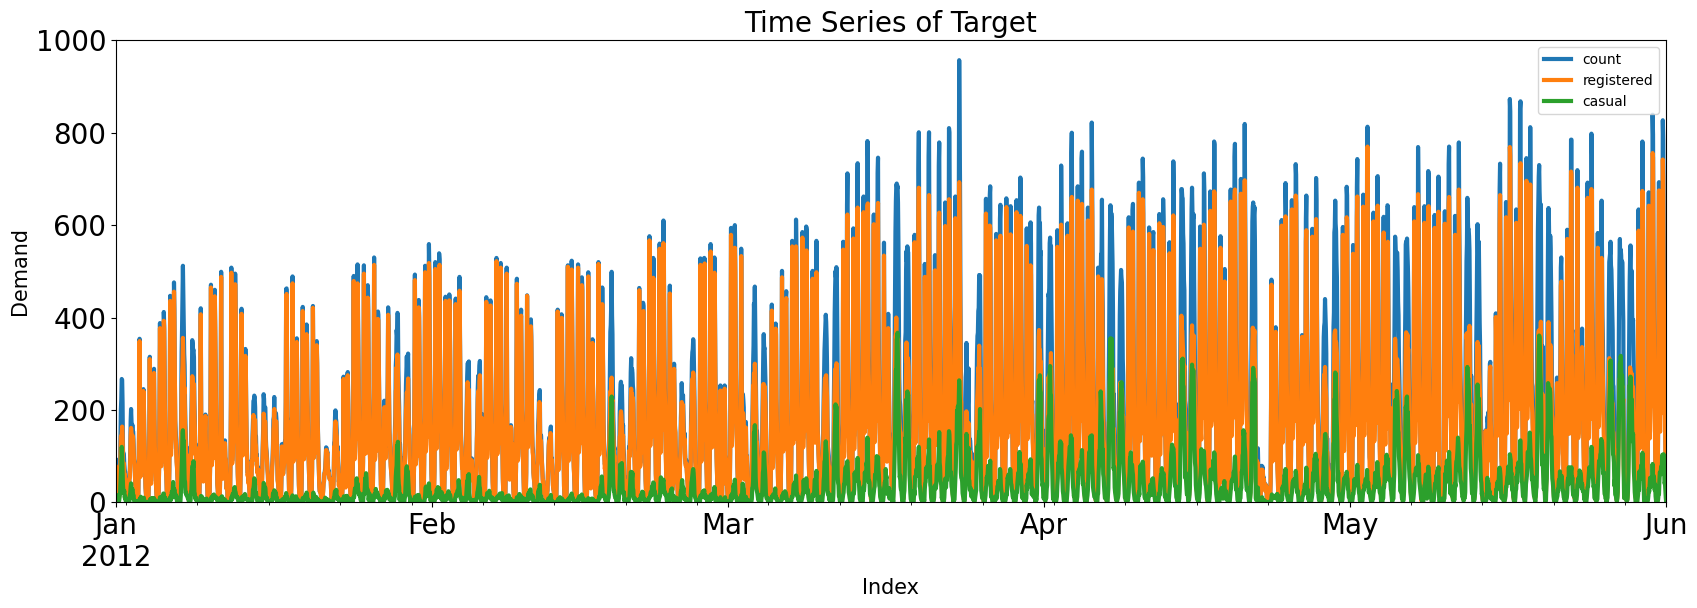

In [21]:
# 종속변수 후보값 시각화
df[['count','registered','casual']].plot(kind='line', figsize=(20,6), linewidth=3, fontsize=20,
                                         xlim=('2012-01-01', '2012-06-01'), ylim=(0,1000))
plt.title('Time Series of Target', fontsize=20)
plt.xlabel('Index', fontsize=15)
plt.ylabel('Demand', fontsize=15)
plt.show()

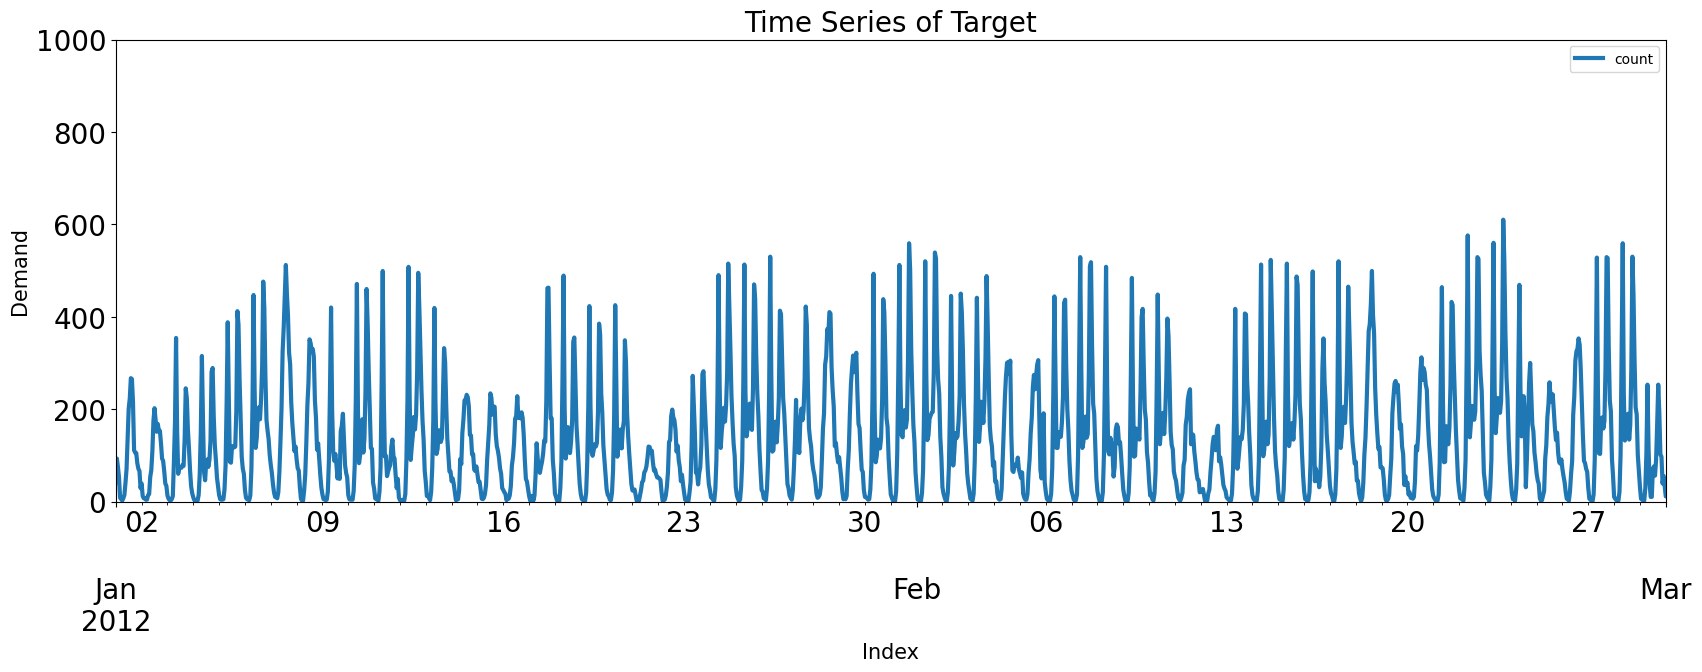

In [22]:
# 최종 종속변수 시각화
df[['count']].plot(kind='line', figsize=(20,6), linewidth=3, fontsize=20,
                   xlim=('2012-01-01', '2012-03-01'), ylim=(0,1000))
plt.title('Time Series of Target', fontsize=20)
plt.xlabel('Index', fontsize=15)
plt.ylabel('Demand', fontsize=15)
plt.show()

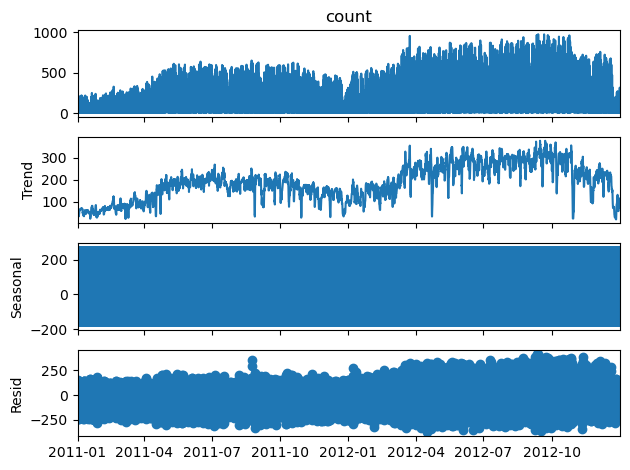

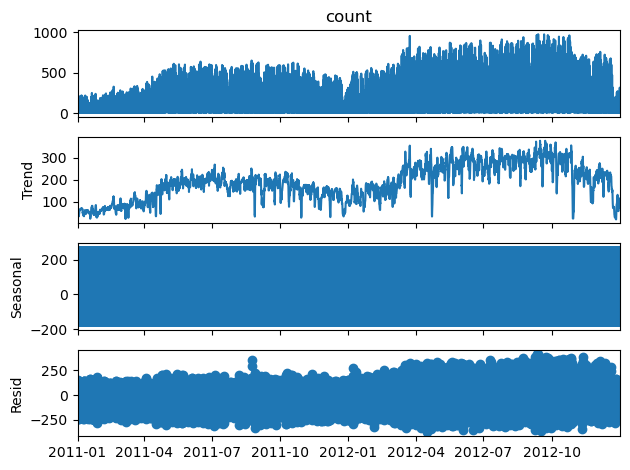

In [23]:
# 종속변수의 시계열 분해 및 시각화
sm.tsa.seasonal_decompose(df['count']).plot()

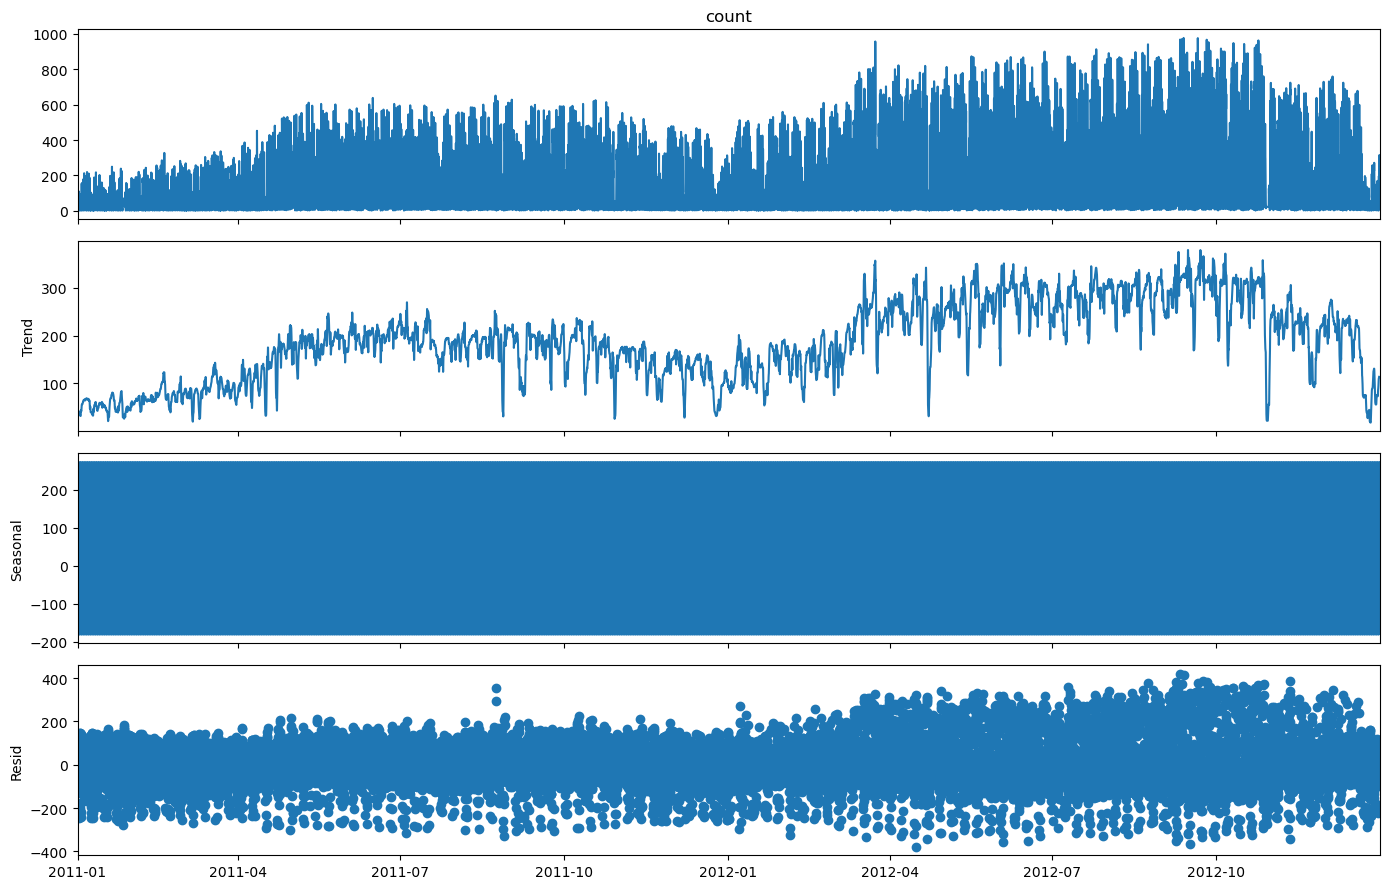

In [24]:
# 종속변수의 구성요소들이 더하기 결합을 가정한 시계열 분해 및 시각화
plt.rcParams['figure.figsize'] = (14, 9)
sm.tsa.seasonal_decompose(df['count'], model='additive').plot()
plt.show()

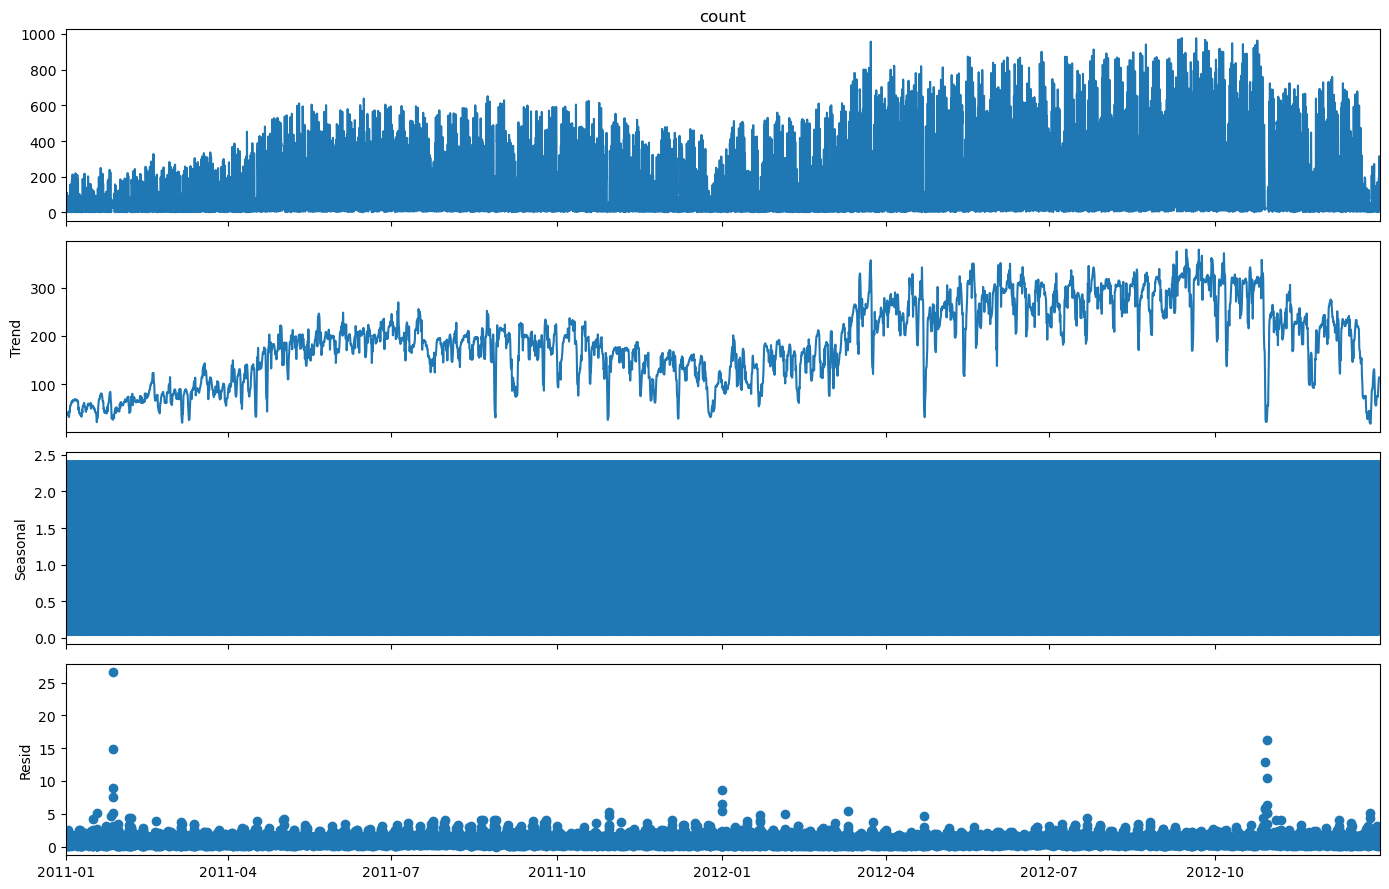

In [25]:
# 종속변수의 구성요소들이 곱하기 결합을 가정한 시계열 분해 및 시각화
sm.tsa.seasonal_decompose(df['count'], model='multiplicative').plot()
plt.show()

In [26]:
# 종속변수 시계열 분해 결과 저장 후 추세와 계절성 확인
result = sm.tsa.seasonal_decompose(df['count'], model='additive')
result.trend, result.seasonal

(DateTime
 2011-01-01 00:00:00   NaN
 2011-01-01 01:00:00   NaN
 2011-01-01 02:00:00   NaN
 2011-01-01 03:00:00   NaN
 2011-01-01 04:00:00   NaN
                        ..
 2012-12-31 19:00:00   NaN
 2012-12-31 20:00:00   NaN
 2012-12-31 21:00:00   NaN
 2012-12-31 22:00:00   NaN
 2012-12-31 23:00:00   NaN
 Freq: h, Name: trend, Length: 17544, dtype: float64,
 DateTime
 2011-01-01 00:00:00   -134.25
 2011-01-01 01:00:00   -154.75
 2011-01-01 02:00:00   -165.27
 2011-01-01 03:00:00   -176.48
 2011-01-01 04:00:00   -181.67
                         ...  
 2012-12-31 19:00:00    122.70
 2012-12-31 20:00:00     37.48
 2012-12-31 21:00:00    -16.10
 2012-12-31 22:00:00    -56.94
 2012-12-31 23:00:00   -100.31
 Freq: h, Name: seasonal, Length: 17544, dtype: float64)

In [27]:
# 종속변수 추세추출 및 저장
Y_trend = pd.DataFrame(result.trend)
Y_trend.fillna(method='ffill', inplace=True)
Y_trend.fillna(method='bfill', inplace=True)
Y_trend.columns = ['count_trend']
Y_trend

,count_trend
DateTime,
2011-01-01 00:00:00,41.06
2011-01-01 01:00:00,41.06
2011-01-01 02:00:00,41.06
2011-01-01 03:00:00,41.06
2011-01-01 04:00:00,41.06
...,...
2012-12-31 19:00:00,113.71
2012-12-31 20:00:00,113.71
2012-12-31 21:00:00,113.71


In [28]:
# 종속변수 계절성추출 및 저장
Y_seasonal = pd.DataFrame(result.seasonal)
Y_seasonal.fillna(method='ffill', inplace=True)
Y_seasonal.fillna(method='bfill', inplace=True)
Y_seasonal.columns = ['count_seasonal']
Y_seasonal

,count_seasonal
DateTime,
2011-01-01 00:00:00,-134.25
2011-01-01 01:00:00,-154.75
2011-01-01 02:00:00,-165.27
2011-01-01 03:00:00,-176.48
2011-01-01 04:00:00,-181.67
...,...
2012-12-31 19:00:00,122.70
2012-12-31 20:00:00,37.48
2012-12-31 21:00:00,-16.10


In [29]:
# 추출한 추세와 계절성을 df와 결합
if 'count_trend' not in df.columns:
    if 'count_seasonal' not in df.columns:
        df = pd.concat([df, Y_trend, Y_seasonal], axis=1)
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,count_trend,count_seasonal
DateTime,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16,41.06,-134.25
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40,41.06,-154.75
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32,41.06,-165.27
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13,41.06,-176.48
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1,41.06,-181.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119,113.71,122.70
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89,113.71,37.48
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90,113.71,-16.10


- `이동평균(Moving Average) 및 차분(Difference)` 데이터 추출

<Axes: xlabel='DateTime'>

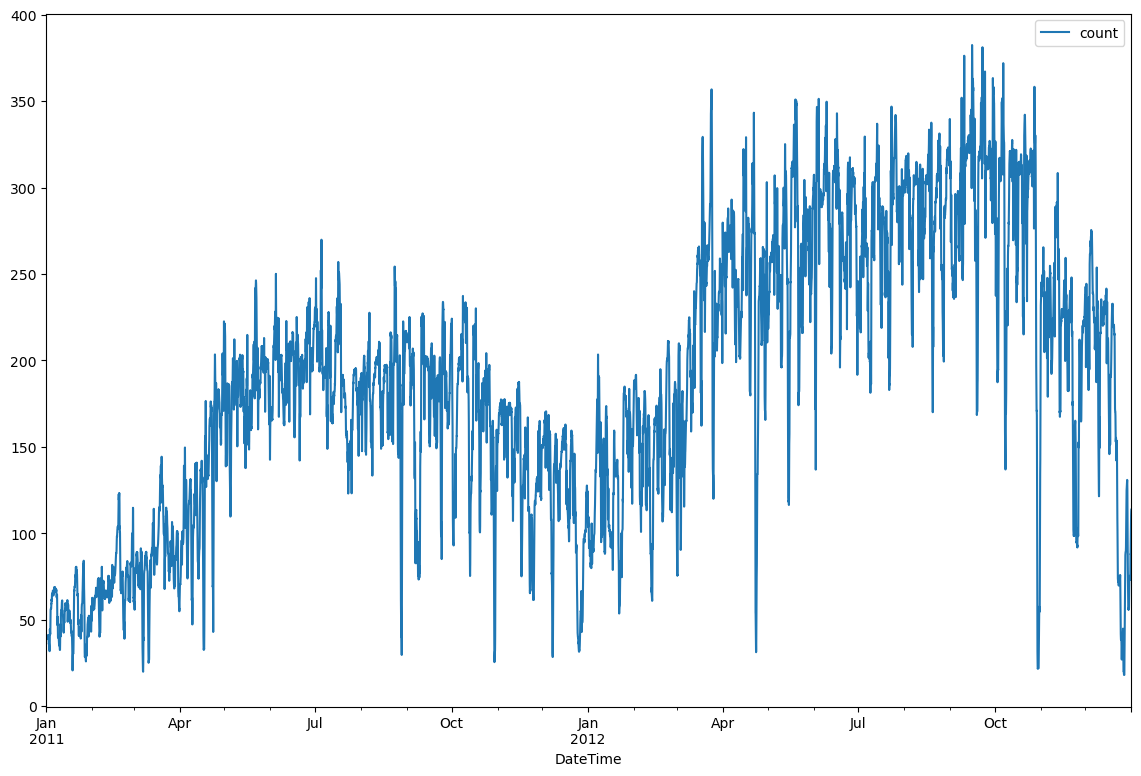

In [30]:
# 시계열의 이동평균 데이터 추출
df[['count']].rolling(24).mean().plot()

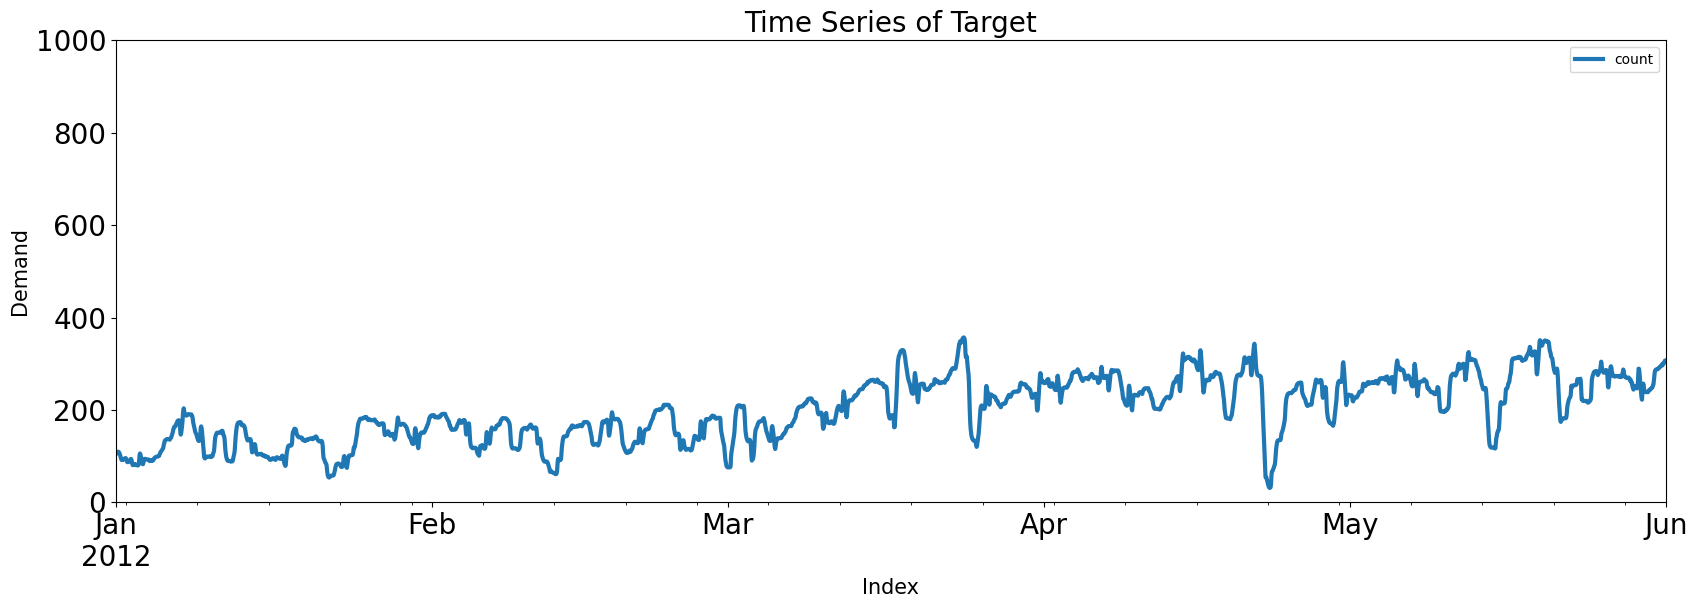

In [31]:
# 시계열의 이동평균 데이터 의미 시각화
df[['count']].rolling(24).mean().plot(kind='line', figsize=(20,6), linewidth=3, fontsize=20,
                                      xlim=('2012-01-01', '2012-06-01'), ylim=(0,1000))
plt.title('Time Series of Target', fontsize=20)
plt.xlabel('Index', fontsize=15)
plt.ylabel('Demand', fontsize=15)
plt.show()

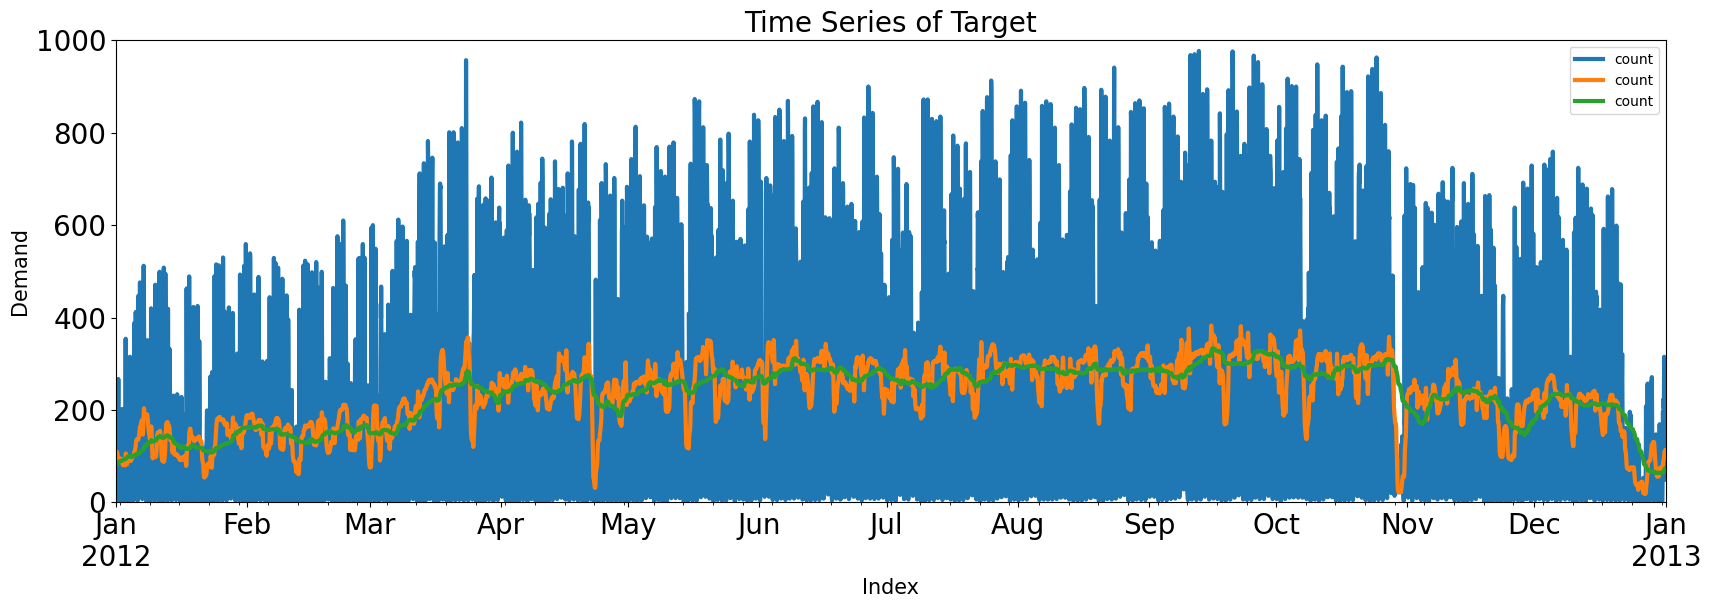

In [32]:
# 시계열의 이동평균을 활용하여 일별 주별 평균 데이터 시각화
pd.concat([df[['count']],
           df[['count']].rolling(24).mean(),
           df[['count']].rolling(24*7).mean()], axis=1).plot(kind='line', figsize=(20,6), linewidth=3, fontsize=20,
                                                             xlim=('2012-01-01', '2013-01-01'), ylim=(0,1000))
plt.title('Time Series of Target', fontsize=20)
plt.xlabel('Index', fontsize=15)
plt.ylabel('Demand', fontsize=15)
plt.show()


In [33]:
# 추출한 일별 주별 데이터의 nan을 채우고 df와 결합
Y_count_Day = df[['count']].rolling(24).mean()
Y_count_Day.fillna(method='ffill', inplace=True)
Y_count_Day.fillna(method='bfill', inplace=True)
Y_count_Day.columns = ['count_Day']
Y_count_Week = df[['count']].rolling(24*7).mean()
Y_count_Week.fillna(method='ffill', inplace=True)
Y_count_Week.fillna(method='bfill', inplace=True)
Y_count_Week.columns = ['count_Week']
if 'count_Day' not in df.columns:
    df = pd.concat([df, Y_count_Day], axis=1)
if 'count_Week' not in df.columns:
    df = pd.concat([df, Y_count_Week], axis=1)
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,count_trend,count_seasonal,count_Day,count_Week
DateTime,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16,41.06,-134.25,41.04,56.11
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40,41.06,-154.75,41.04,56.11
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32,41.06,-165.27,41.04,56.11
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13,41.06,-176.48,41.04,56.11
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1,41.06,-181.67,41.04,56.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119,113.71,122.70,110.17,73.30
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89,113.71,37.48,110.88,73.70
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90,113.71,-16.10,112.67,74.10


In [34]:
# 종속변수 데이터 확인
df[['count']]

,count
DateTime,
2011-01-01 00:00:00,16
2011-01-01 01:00:00,40
2011-01-01 02:00:00,32
2011-01-01 03:00:00,13
2011-01-01 04:00:00,1
...,...
2012-12-31 19:00:00,119
2012-12-31 20:00:00,89
2012-12-31 21:00:00,90


In [35]:
# 종속변수 차분데이터 확인
df[['count']].diff()

,count
DateTime,
2011-01-01 00:00:00,NaN
2011-01-01 01:00:00,24.00
2011-01-01 02:00:00,-8.00
2011-01-01 03:00:00,-19.00
2011-01-01 04:00:00,-12.00
...,...
2012-12-31 19:00:00,-3.00
2012-12-31 20:00:00,-30.00
2012-12-31 21:00:00,1.00


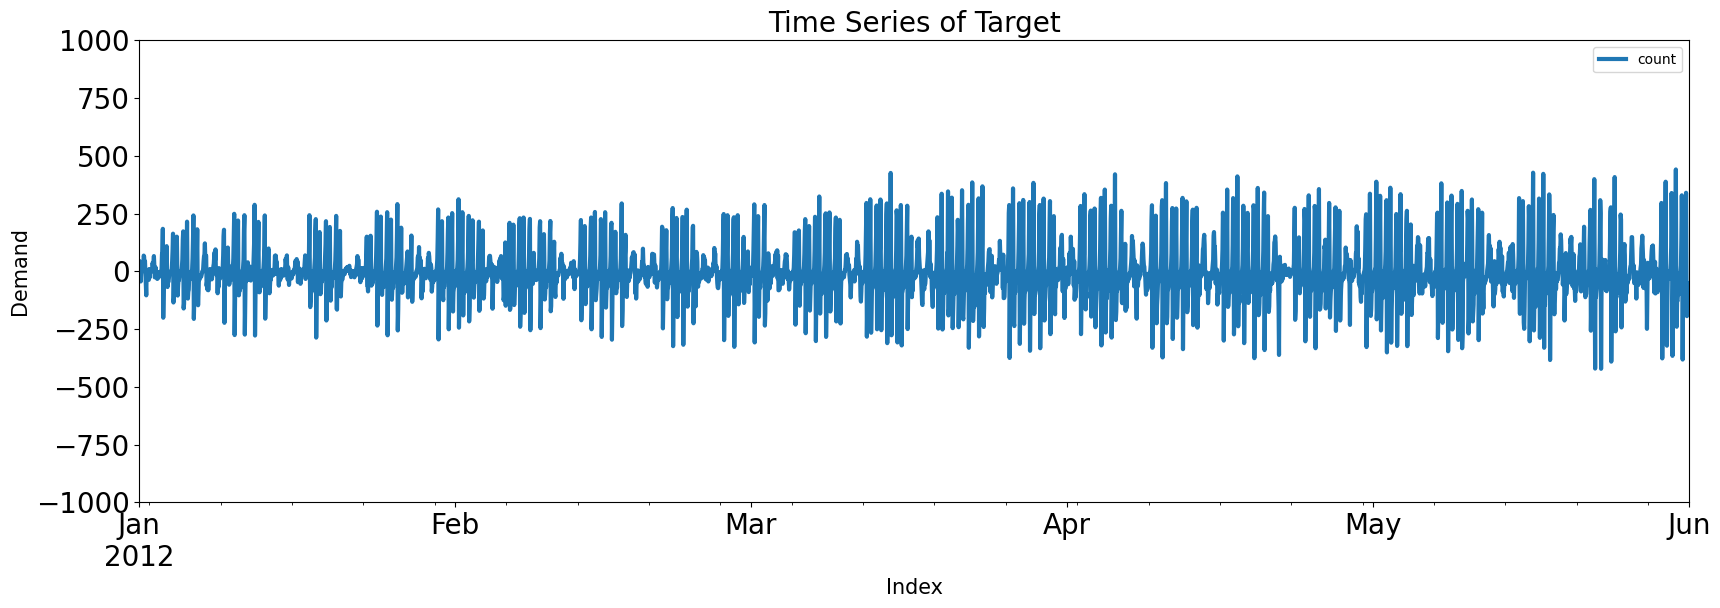

In [36]:
# 종속변수 차분데이터 시각화
df[['count']].diff().plot(kind='line', figsize=(20,6), linewidth=3, fontsize=20,
                          xlim=('2012-01-01', '2012-06-01'), ylim=(-1000,1000))
plt.title('Time Series of Target', fontsize=20)
plt.xlabel('Index', fontsize=15)
plt.ylabel('Demand', fontsize=15)
plt.show()

In [37]:
# 차분데이터 nan 채우고 df와 결합
Y_diff = df[['count']].diff()
Y_diff.fillna(method='ffill', inplace=True)
Y_diff.fillna(method='bfill', inplace=True)
Y_diff.columns = ['count_diff']
if 'count_diff' not in df.columns:
    df = pd.concat([df, Y_diff], axis=1)
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,count_trend,count_seasonal,count_Day,count_Week,count_diff
DateTime,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16,41.06,-134.25,41.04,56.11,24.00
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40,41.06,-154.75,41.04,56.11,24.00
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32,41.06,-165.27,41.04,56.11,-8.00
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13,41.06,-176.48,41.04,56.11,-19.00
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1,41.06,-181.67,41.04,56.11,-12.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119,113.71,122.70,110.17,73.30,-3.00
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89,113.71,37.48,110.88,73.70,-30.00
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90,113.71,-16.10,112.67,74.10,1.00


In [38]:
# 추출된 변수들의 특성 확인
df.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
datetime,17544,2012-01-01 11:25:55.608755200,2011-01-01 00:00:00,2011-07-02 17:45:00,2012-01-01 11:30:00,2012-07-02 05:15:00,2012-12-31 23:00:00,NaN
season,"17,544.00",2.50,1.00,2.00,3.00,3.00,4.00,1.11
holiday,"17,544.00",0.03,0.00,0.00,0.00,0.00,1.00,0.17
workingday,"17,544.00",0.68,0.00,0.00,1.00,1.00,1.00,0.47
weather,"17,544.00",1.43,1.00,1.00,1.00,2.00,4.00,0.65
temp,"17,544.00",20.30,0.82,13.94,20.50,27.06,41.00,7.92
atemp,"17,544.00",23.71,0.00,16.66,24.24,31.06,50.00,8.62
humidity,"17,544.00",62.87,0.00,48.00,63.00,79.00,100.00,19.34
windspeed,"17,544.00",12.81,0.00,7.00,13.00,17.00,57.00,8.29
casual,"17,544.00",35.35,0.00,4.00,16.00,48.00,367.00,49.19


In [39]:
# 결측값 확인
df.isnull().sum().sum()

0

**5) 지연값(Lagged values, $Lag_t(X_1)$)**: 변수의 `지연된 값들`로 별도 독립변수를 생성하는 것으로, `ARIMA/VAR/NNAR(Neural Network Autoregression) 등`의 알고리즘도 내부적으로 활용  

<center><img src='Image/Advanced/Lag-explanation.PNG' width='400'></center>

---

**6) 시간변수**: `시간정보`가 담고 있는 년/월/일/요일 등 자체를 `별도 독립적인 변수로 생성`  

- **요약**:

> - 시계열 구성요소는 각 변수의 `시간패턴을 파악`하는데 중요
> - FE를 통해 생성된 `변수의 입력(Input) 형태`로 `알고리즘 선택`시 고려해야
> - 생성된 변수의 패턴이 기존 모델에서 반영하지 않던 패턴이라면 `예측 성능을 높임`
> - 예측성능 향상 뿐 아니라 `결과를 해석`하고 해당 속성을 분석하며 가능한 `원인 식별에 도움`

In [40]:
# 시간정보 핸들링 위한 함수 확인
df.datetime.dt

In [41]:
# 연도 정보 추출
df.datetime.dt.year

DateTime
2011-01-01 00:00:00    2011
2011-01-01 01:00:00    2011
2011-01-01 02:00:00    2011
2011-01-01 03:00:00    2011
2011-01-01 04:00:00    2011
                       ... 
2012-12-31 19:00:00    2012
2012-12-31 20:00:00    2012
2012-12-31 21:00:00    2012
2012-12-31 22:00:00    2012
2012-12-31 23:00:00    2012
Freq: h, Name: datetime, Length: 17544, dtype: int32

In [42]:
# 요일 정보 추출
df.datetime.dt.dayofweek

DateTime
2011-01-01 00:00:00    5
2011-01-01 01:00:00    5
2011-01-01 02:00:00    5
2011-01-01 03:00:00    5
2011-01-01 04:00:00    5
                      ..
2012-12-31 19:00:00    0
2012-12-31 20:00:00    0
2012-12-31 21:00:00    0
2012-12-31 22:00:00    0
2012-12-31 23:00:00    0
Freq: h, Name: datetime, Length: 17544, dtype: int32

In [43]:
# 연도 및 분기 데이터 추출 생성
df['Year'] = df.datetime.dt.year
df['Quater'] = df.datetime.dt.quarter
df.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
datetime,17544,2012-01-01 11:25:55.608755200,2011-01-01 00:00:00,2011-07-02 17:45:00,2012-01-01 11:30:00,2012-07-02 05:15:00,2012-12-31 23:00:00,NaN
season,"17,544.00",2.50,1.00,2.00,3.00,3.00,4.00,1.11
holiday,"17,544.00",0.03,0.00,0.00,0.00,0.00,1.00,0.17
workingday,"17,544.00",0.68,0.00,0.00,1.00,1.00,1.00,0.47
weather,"17,544.00",1.43,1.00,1.00,1.00,2.00,4.00,0.65
temp,"17,544.00",20.30,0.82,13.94,20.50,27.06,41.00,7.92
atemp,"17,544.00",23.71,0.00,16.66,24.24,31.06,50.00,8.62
humidity,"17,544.00",62.87,0.00,48.00,63.00,79.00,100.00,19.34
windspeed,"17,544.00",12.81,0.00,7.00,13.00,17.00,57.00,8.29
casual,"17,544.00",35.35,0.00,4.00,16.00,48.00,367.00,49.19


In [44]:
# 분기 데이터 재생성
# 시간 흐름에 따라 증가하는 변수 생성 목적
df['Quater_ver2'] = df['Quater'] + (df.Year - df.Year.min()) * 4
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,count_trend,count_seasonal,count_Day,count_Week,count_diff,Year,Quater,Quater_ver2
DateTime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16,41.06,-134.25,41.04,56.11,24.00,2011,1,1
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40,41.06,-154.75,41.04,56.11,24.00,2011,1,1
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32,41.06,-165.27,41.04,56.11,-8.00,2011,1,1
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13,41.06,-176.48,41.04,56.11,-19.00,2011,1,1
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1,41.06,-181.67,41.04,56.11,-12.00,2011,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119,113.71,122.70,110.17,73.30,-3.00,2012,4,8
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89,113.71,37.48,110.88,73.70,-30.00,2012,4,8
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90,113.71,-16.10,112.67,74.10,1.00,2012,4,8


In [45]:
# 월 일 시간 요일 추출 생성
df['Month'] = df.datetime.dt.month
df['Day'] = df.datetime.dt.day
df['Hour'] = df.datetime.dt.hour
df['DayofWeek'] = df.datetime.dt.dayofweek
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,count_Day,count_Week,count_diff,Year,Quater,Quater_ver2,Month,Day,Hour,DayofWeek
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,...,41.04,56.11,24.00,2011,1,1,1,1,0,5
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,...,41.04,56.11,24.00,2011,1,1,1,1,1,5
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,...,41.04,56.11,-8.00,2011,1,1,1,1,2,5
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,...,41.04,56.11,-19.00,2011,1,1,1,1,3,5
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,...,41.04,56.11,-12.00,2011,1,1,1,1,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,...,110.17,73.30,-3.00,2012,4,8,12,31,19,0
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,...,110.88,73.70,-30.00,2012,4,8,12,31,20,0
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,...,112.67,74.10,1.00,2012,4,8,12,31,21,0


In [46]:
# 추출변수들의 특성 확인
df.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
datetime,17544,2012-01-01 11:25:55.608755200,2011-01-01 00:00:00,2011-07-02 17:45:00,2012-01-01 11:30:00,2012-07-02 05:15:00,2012-12-31 23:00:00,NaN
season,"17,544.00",2.50,1.00,2.00,3.00,3.00,4.00,1.11
holiday,"17,544.00",0.03,0.00,0.00,0.00,0.00,1.00,0.17
workingday,"17,544.00",0.68,0.00,0.00,1.00,1.00,1.00,0.47
weather,"17,544.00",1.43,1.00,1.00,1.00,2.00,4.00,0.65
...,...,...,...,...,...,...,...,...
Quater_ver2,"17,544.00",4.51,1.00,3.00,5.00,7.00,8.00,2.29
Month,"17,544.00",6.52,1.00,4.00,7.00,10.00,12.00,3.45
Day,"17,544.00",15.74,1.00,8.00,16.00,23.00,31.00,8.80
Hour,"17,544.00",11.51,0.00,5.00,12.00,17.25,23.00,6.94


In [47]:
# 지연값 생성
# 지연시킬 방향에 주의해야
df['count'].shift(1)

DateTime
2011-01-01 00:00:00      NaN
2011-01-01 01:00:00    16.00
2011-01-01 02:00:00    40.00
2011-01-01 03:00:00    32.00
2011-01-01 04:00:00    13.00
                       ...  
2012-12-31 19:00:00   122.00
2012-12-31 20:00:00   119.00
2012-12-31 21:00:00    89.00
2012-12-31 22:00:00    90.00
2012-12-31 23:00:00    61.00
Freq: h, Name: count, Length: 17544, dtype: float64

In [48]:
# 지연값 생성
df['count'].shift(1)
# df['count'].shift(-1)

DateTime
2011-01-01 00:00:00      NaN
2011-01-01 01:00:00    16.00
2011-01-01 02:00:00    40.00
2011-01-01 03:00:00    32.00
2011-01-01 04:00:00    13.00
                       ...  
2012-12-31 19:00:00   122.00
2012-12-31 20:00:00   119.00
2012-12-31 21:00:00    89.00
2012-12-31 22:00:00    90.00
2012-12-31 23:00:00    61.00
Freq: h, Name: count, Length: 17544, dtype: float64

In [49]:
# 지연값 변수 추출생성
df['count_lag1'] = df['count'].shift(1)
df['count_lag2'] = df['count'].shift(2)
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,count_diff,Year,Quater,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,...,24.00,2011,1,1,1,1,0,5,NaN,NaN
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,...,24.00,2011,1,1,1,1,1,5,16.00,NaN
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,...,-8.00,2011,1,1,1,1,2,5,40.00,16.00
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,...,-19.00,2011,1,1,1,1,3,5,32.00,40.00
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,...,-12.00,2011,1,1,1,1,4,5,13.00,32.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,...,-3.00,2012,4,8,12,31,19,0,122.00,164.00
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,...,-30.00,2012,4,8,12,31,20,0,119.00,122.00
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,...,1.00,2012,4,8,12,31,21,0,89.00,119.00


In [50]:
# 추출 변수의 특성 확인
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,17544,2012-01-01 11:25:55.608755200,2011-01-01 00:00:00,2011-07-02 17:45:00,2012-01-01 11:30:00,2012-07-02 05:15:00,2012-12-31 23:00:00,NaN
season,"17,544.00",2.50,1.00,2.00,3.00,3.00,4.00,1.11
holiday,"17,544.00",0.03,0.00,0.00,0.00,0.00,1.00,0.17
workingday,"17,544.00",0.68,0.00,0.00,1.00,1.00,1.00,0.47
weather,"17,544.00",1.43,1.00,1.00,1.00,2.00,4.00,0.65
...,...,...,...,...,...,...,...,...
Day,"17,544.00",15.74,1.00,8.00,16.00,23.00,31.00,8.80
Hour,"17,544.00",11.51,0.00,5.00,12.00,17.25,23.00,6.94
DayofWeek,"17,544.00",3.00,0.00,1.00,3.00,5.00,6.00,2.01
count_lag1,"17,543.00",187.80,1.00,38.00,140.00,279.00,977.00,181.35


In [51]:
# 지연값에서의 nan 제거
# df['count_lag2'].fillna(method='bfill')
# df['count_lag2'].fillna(method='ffill')
df['count_lag2'].fillna(0)

DateTime
2011-01-01 00:00:00     0.00
2011-01-01 01:00:00     0.00
2011-01-01 02:00:00    16.00
2011-01-01 03:00:00    40.00
2011-01-01 04:00:00    32.00
                       ...  
2012-12-31 19:00:00   164.00
2012-12-31 20:00:00   122.00
2012-12-31 21:00:00   119.00
2012-12-31 22:00:00    89.00
2012-12-31 23:00:00    90.00
Freq: h, Name: count_lag2, Length: 17544, dtype: float64

In [52]:
# 지연값에서의 nan 제거 후 저장
df['count_lag1'].fillna(method='bfill', inplace=True)
df['count_lag2'].fillna(method='bfill', inplace=True)
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,count_diff,Year,Quater,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,...,24.00,2011,1,1,1,1,0,5,16.00,16.00
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,...,24.00,2011,1,1,1,1,1,5,16.00,16.00
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,...,-8.00,2011,1,1,1,1,2,5,40.00,16.00
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,...,-19.00,2011,1,1,1,1,3,5,32.00,40.00
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,...,-12.00,2011,1,1,1,1,4,5,13.00,32.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,...,-3.00,2012,4,8,12,31,19,0,122.00,164.00
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,...,-30.00,2012,4,8,12,31,20,0,119.00,122.00
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,...,1.00,2012,4,8,12,31,21,0,89.00,119.00


In [53]:
# 분기 변수의 더미변수 생성 및 df와 결합
pd.get_dummies(df['Quater'])
pd.get_dummies(df['Quater'], prefix='Quater_Dummy')
pd.get_dummies(df['Quater'], prefix='Quater_Dummy', drop_first=True)
pd.concat([df, pd.get_dummies(df['Quater'], prefix='Quater_Dummy', drop_first=True)], axis=1)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,...,1,1,1,0,5,16.00,16.00,False,False,False
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,...,1,1,1,1,5,16.00,16.00,False,False,False
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,...,1,1,1,2,5,40.00,16.00,False,False,False
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,...,1,1,1,3,5,32.00,40.00,False,False,False
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,...,1,1,1,4,5,13.00,32.00,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,...,8,12,31,19,0,122.00,164.00,False,False,True
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,...,8,12,31,20,0,119.00,122.00,False,False,True
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,...,8,12,31,21,0,89.00,119.00,False,False,True


In [54]:
# 분기 변수의 더미변수 생성 및 df와 결합
if 'Quater' in df.columns:
    df = pd.concat([df, pd.get_dummies(df['Quater'], prefix='Quater_Dummy', drop_first=True)], axis=1)
    del df['Quater']
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,...,1,1,1,0,5,16.00,16.00,False,False,False
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,...,1,1,1,1,5,16.00,16.00,False,False,False
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,...,1,1,1,2,5,40.00,16.00,False,False,False
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,...,1,1,1,3,5,32.00,40.00,False,False,False
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,...,1,1,1,4,5,13.00,32.00,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,...,8,12,31,19,0,122.00,164.00,False,False,True
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,...,8,12,31,20,0,119.00,122.00,False,False,True
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,...,8,12,31,21,0,89.00,119.00,False,False,True


### Code Summary

In [55]:
# 시계열 변수추출
## 날짜인식 및 빈도 설정만
def non_feature_engineering(df):
    df_nfe = df.copy()
    if 'datetime' in df_nfe.columns:
        df_nfe['datetime'] = pd.to_datetime(df_nfe['datetime'])
        df_nfe['DateTime'] = pd.to_datetime(df_nfe['datetime'])
    if df_nfe.index.dtype == 'int64':
        df_nfe.set_index('DateTime', inplace=True)
    df_nfe = df_nfe.asfreq('H', method='ffill')

    return df_nfe


## 날짜인식 및 빈도 설정을 포함한 모든 전처리
def feature_engineering(df):
    df_fe = df.copy()
    if 'datetime' in df_fe.columns:
        df_fe['datetime'] = pd.to_datetime(df_fe['datetime'])
        df_fe['DateTime'] = pd.to_datetime(df_fe['datetime'])

    if df_fe.index.dtype == 'int64':
        df_fe.set_index('DateTime', inplace=True)

    df_fe = df_fe.asfreq('H', method='ffill')

    result = sm.tsa.seasonal_decompose(df_fe['count'], model='additive')
    Y_trend = pd.DataFrame(result.trend)
    Y_trend.fillna(method='ffill', inplace=True)
    Y_trend.fillna(method='bfill', inplace=True)
    Y_trend.columns = ['count_trend']
    Y_seasonal = pd.DataFrame(result.seasonal)
    Y_seasonal.fillna(method='ffill', inplace=True)
    Y_seasonal.fillna(method='bfill', inplace=True)
    Y_seasonal.columns = ['count_seasonal']
    pd.concat([df_fe, Y_trend, Y_seasonal], axis=1).isnull().sum()
    if 'count_trend' not in df_fe.columns:
        if 'count_seasonal' not in df_fe.columns:
            df_fe = pd.concat([df_fe, Y_trend, Y_seasonal], axis=1)

    Y_count_Day = df_fe[['count']].rolling(24).mean()
    Y_count_Day.fillna(method='ffill', inplace=True)
    Y_count_Day.fillna(method='bfill', inplace=True)
    Y_count_Day.columns = ['count_Day']
    Y_count_Week = df_fe[['count']].rolling(24*7).mean()
    Y_count_Week.fillna(method='ffill', inplace=True)
    Y_count_Week.fillna(method='bfill', inplace=True)
    Y_count_Week.columns = ['count_Week']
    if 'count_Day' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_count_Day], axis=1)
    if 'count_Week' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_count_Week], axis=1)

    Y_diff = df_fe[['count']].diff()
    Y_diff.fillna(method='ffill', inplace=True)
    Y_diff.fillna(method='bfill', inplace=True)
    Y_diff.columns = ['count_diff']
    if 'count_diff' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_diff], axis=1)

#     df_fe['temp_group'] = pd.cut(df_fe['temp'], 10)
    df_fe['Year'] = df_fe.datetime.dt.year
    df_fe['Quater'] = df_fe.datetime.dt.quarter
    df_fe['Quater_ver2'] = df_fe['Quater'] + (df_fe.Year - df_fe.Year.min()) * 4
    df_fe['Month'] = df_fe.datetime.dt.month
    df_fe['Day'] = df_fe.datetime.dt.day
    df_fe['Hour'] = df_fe.datetime.dt.hour
    df_fe['DayofWeek'] = df_fe.datetime.dt.dayofweek

    df_fe['count_lag1'] = df_fe['count'].shift(1)
    df_fe['count_lag2'] = df_fe['count'].shift(2)
    df_fe['count_lag1'].fillna(method='bfill', inplace=True)
    df_fe['count_lag2'].fillna(method='bfill', inplace=True)

    if 'Quater' in df_fe.columns:
        if 'Quater_Dummy' not in ['_'.join(col.split('_')[:2]) for col in df_fe.columns]:
            df_fe = pd.concat([df_fe, pd.get_dummies(df_fe['Quater'], 
                                                     prefix='Quater_Dummy', drop_first=True).astype(int)], axis=1)
            del df_fe['Quater']
    
    return df_fe

In [56]:
# 데이터 로딩
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# 데이터 전처리
df_nfe = non_feature_engineering(df)
df_fe = feature_engineering(df)

In [57]:
# 결과 비교
display(df_nfe, df_fe)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
DateTime,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,108,119
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,81,89
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,83,90


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,...,1,1,1,0,5,16.00,16.00,0,0,0
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,...,1,1,1,1,5,16.00,16.00,0,0,0
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,...,1,1,1,2,5,40.00,16.00,0,0,0
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,...,1,1,1,3,5,32.00,40.00,0,0,0
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,...,1,1,1,4,5,13.00,32.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,11,...,8,12,31,19,0,122.00,164.00,0,0,1
2012-12-31 20:00:00,2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,8,...,8,12,31,20,0,119.00,122.00,0,0,1
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,...,8,12,31,21,0,89.00,119.00,0,0,1


## 시각화로 추출변수가 Y예측에 도움될지 확인

In [58]:
# 전처리 이후 데이터 특징 확인
df_fe.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
datetime,17544,2012-01-01 11:25:55.608755200,2011-01-01 00:00:00,2011-07-02 17:45:00,2012-01-01 11:30:00,2012-07-02 05:15:00,2012-12-31 23:00:00,NaN
season,"17,544.00",2.50,1.00,2.00,3.00,3.00,4.00,1.11
holiday,"17,544.00",0.03,0.00,0.00,0.00,0.00,1.00,0.17
workingday,"17,544.00",0.68,0.00,0.00,1.00,1.00,1.00,0.47
weather,"17,544.00",1.43,1.00,1.00,1.00,2.00,4.00,0.65
...,...,...,...,...,...,...,...,...
count_lag1,"17,544.00",187.79,1.00,38.00,140.00,279.00,977.00,181.35
count_lag2,"17,544.00",187.79,1.00,38.00,140.00,279.00,977.00,181.35
Quater_Dummy_2,"17,544.00",0.25,0.00,0.00,0.00,0.00,1.00,0.43
Quater_Dummy_3,"17,544.00",0.25,0.00,0.00,0.00,1.00,1.00,0.43


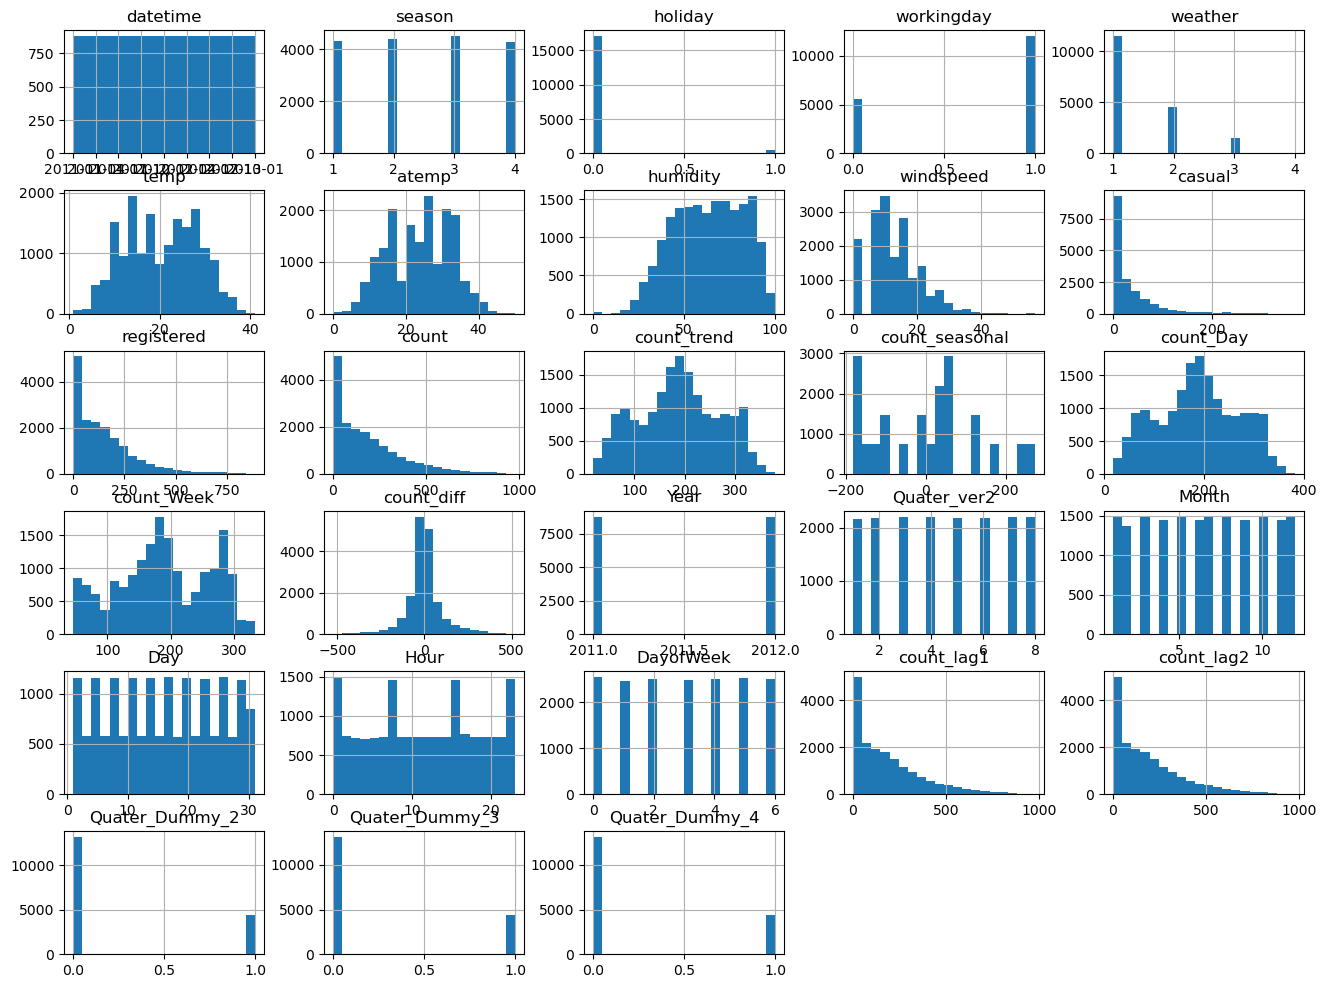

In [59]:
# 변수들의 히스토그램 확인
df_fe.hist(bins=20, grid=True, figsize=(16,12))
plt.show()

(0.0, 1000.0)

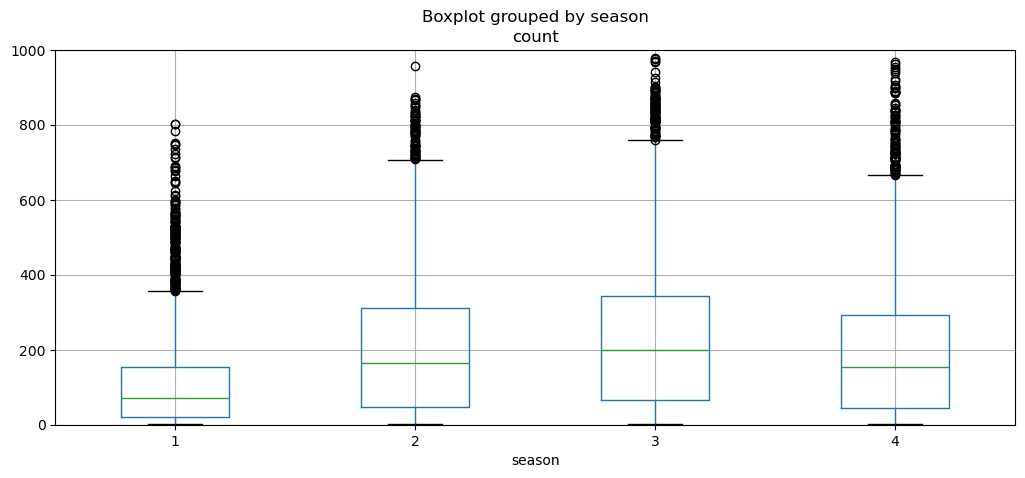

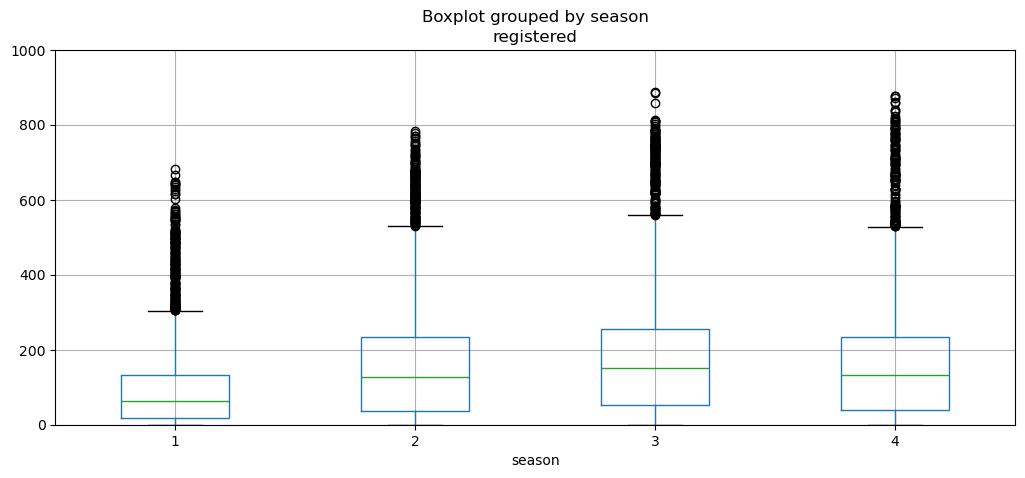

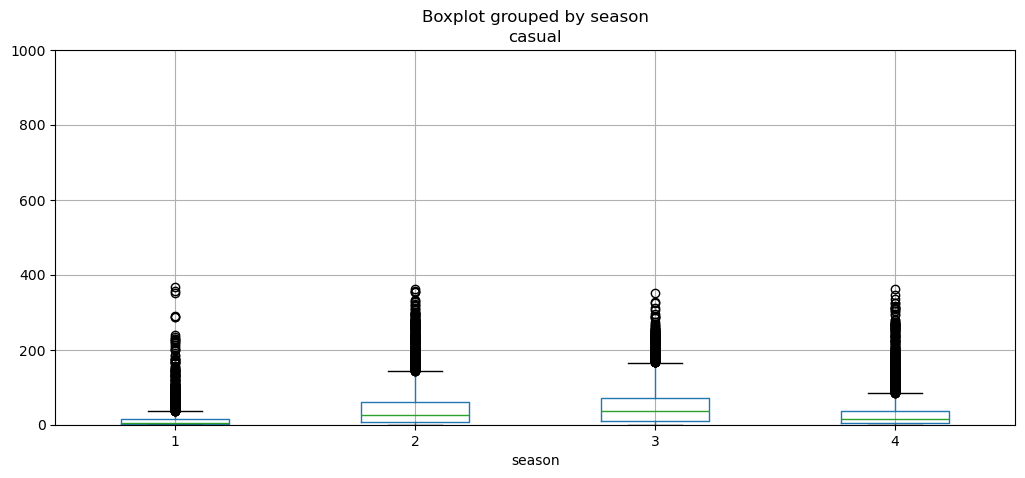

In [60]:
# 계절별 종속변수 분포 확인
df_fe.boxplot(column='count', by='season', grid=True, figsize=(12,5))
plt.ylim(0,1000)
df_fe.boxplot(column='registered', by='season', grid=True, figsize=(12,5))
plt.ylim(0,1000)
df_fe.boxplot(column='casual', by='season', grid=True, figsize=(12,5))
plt.ylim(0,1000)

(0.0, 1000.0)

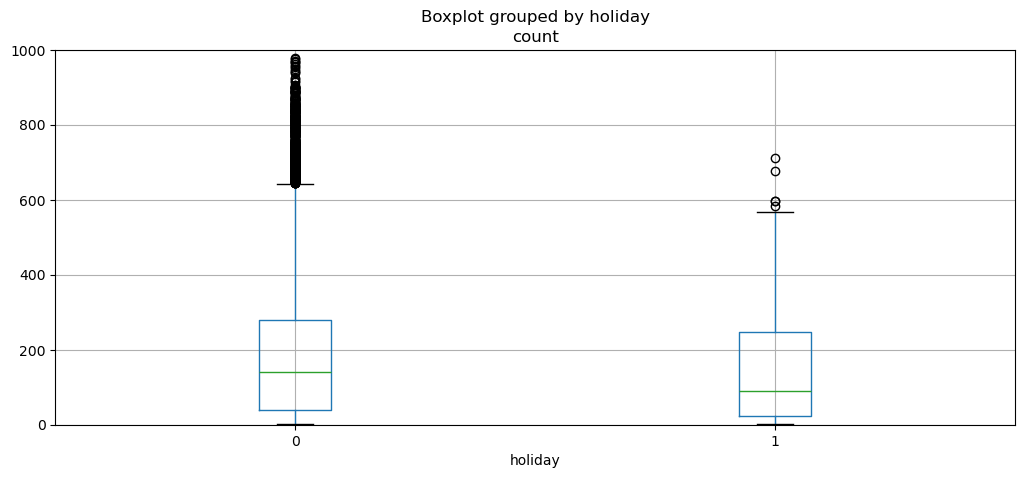

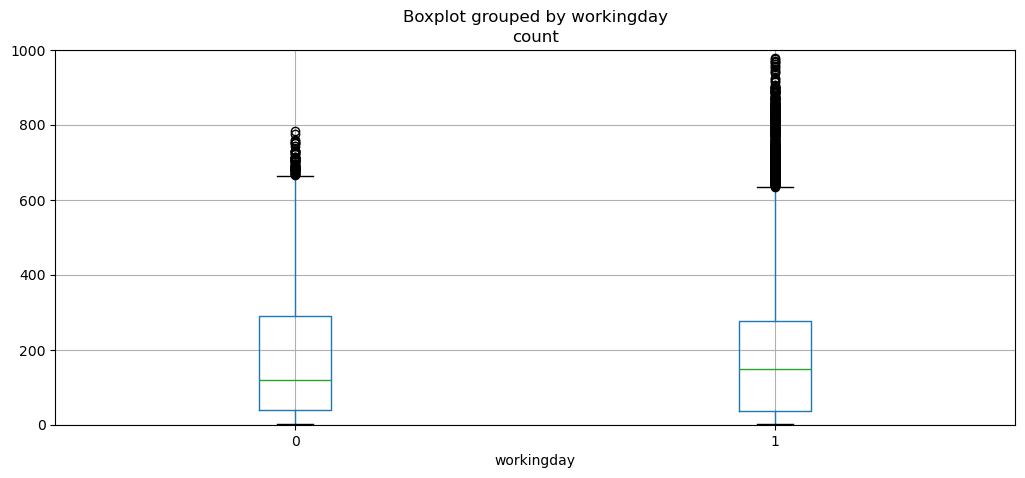

In [61]:
# 주말과 근무일별 종속변수 분포 확인
df_fe.boxplot(column='count', by='holiday', grid=True, figsize=(12,5))
plt.ylim(0,1000)
df_fe.boxplot(column='count', by='workingday', grid=True, figsize=(12,5))
plt.ylim(0,1000)

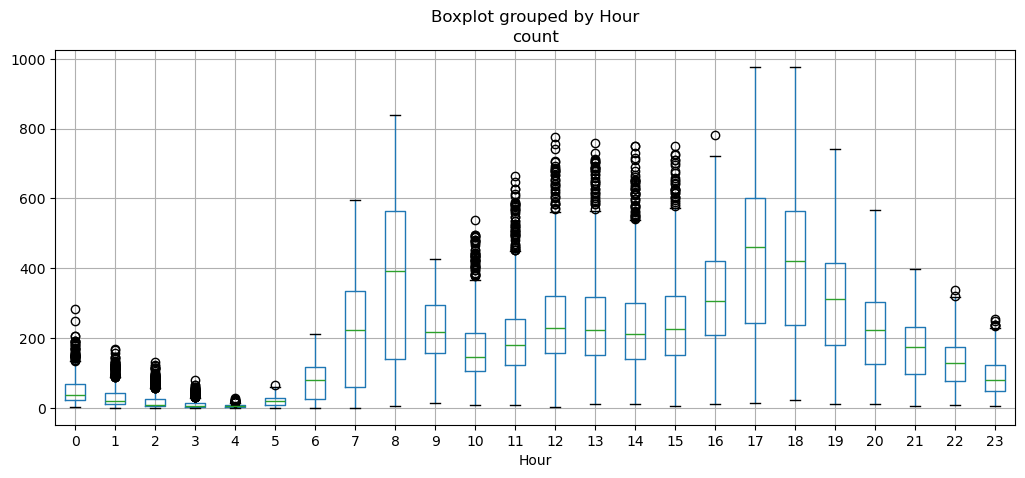

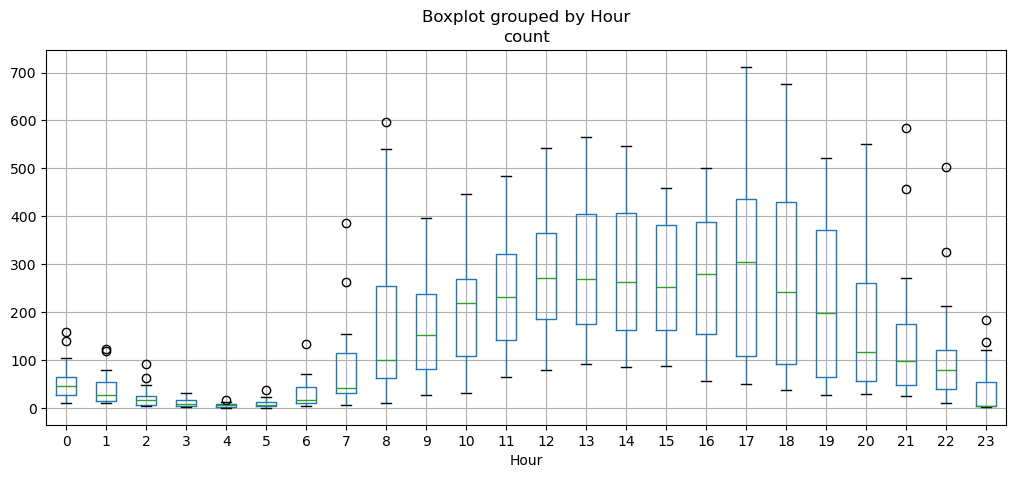

In [62]:
# 주말 여부에 따른 시간별 종속변수 분포 확인
df_fe[df_fe.holiday == 0].boxplot(column='count', by='Hour', grid=True, figsize=(12,5))
plt.show()
df_fe[df_fe.holiday == 1].boxplot(column='count', by='Hour', grid=True, figsize=(12,5))
plt.show()

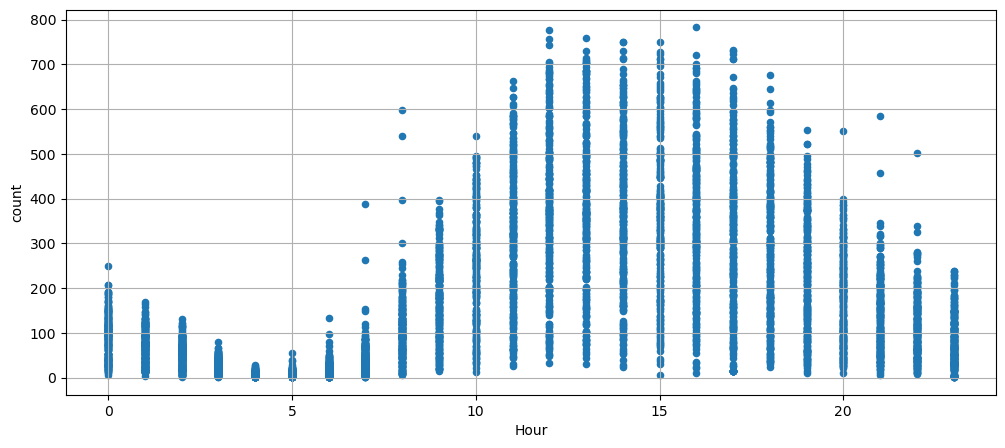

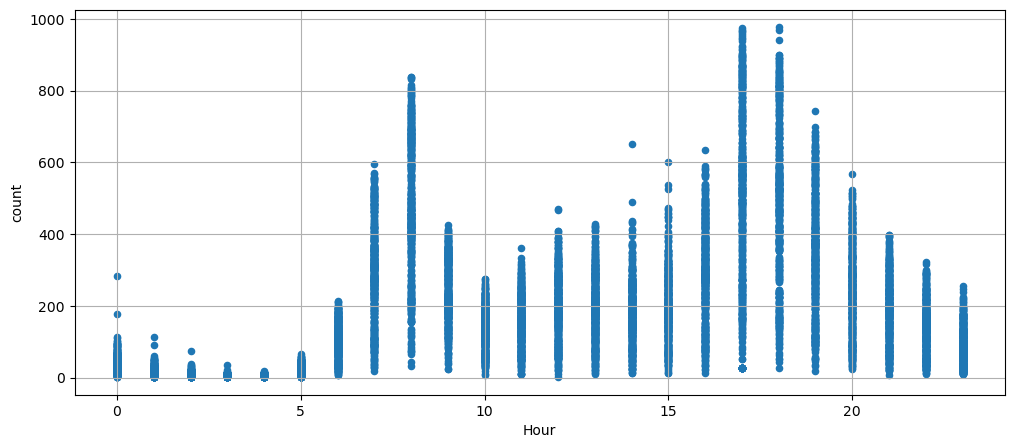

In [63]:
# 근무일 여부에 따른 시간별 종속변수 분포 확인
df_fe[df_fe.workingday == 0].plot.scatter(y='count', x='Hour', grid=True, figsize=(12,5))
plt.show()
df_fe[df_fe.workingday == 1].plot.scatter(y='count', x='Hour', grid=True, figsize=(12,5))
plt.show()

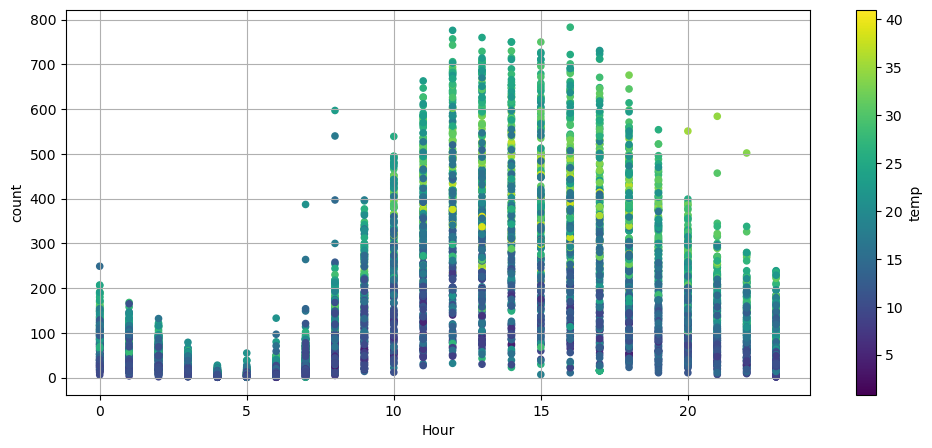

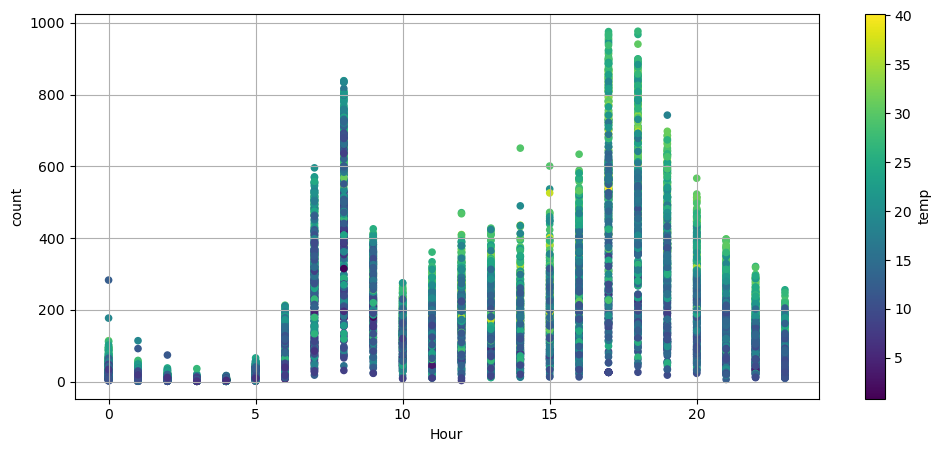

In [64]:
# 근무일 여부에 따른 시간별 온도별 종속변수 분포 확인
df_fe[df_fe.workingday == 0].plot.scatter(y='count', x='Hour', c='temp', grid=True, figsize=(12,5), colormap='viridis')
plt.show()
df_fe[df_fe.workingday == 1].plot.scatter(y='count', x='Hour', c='temp', grid=True, figsize=(12,5), colormap='viridis')
plt.show()

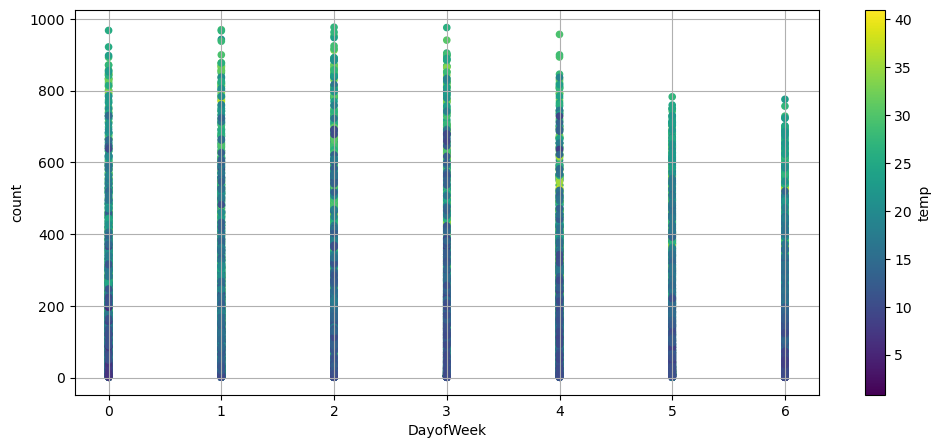

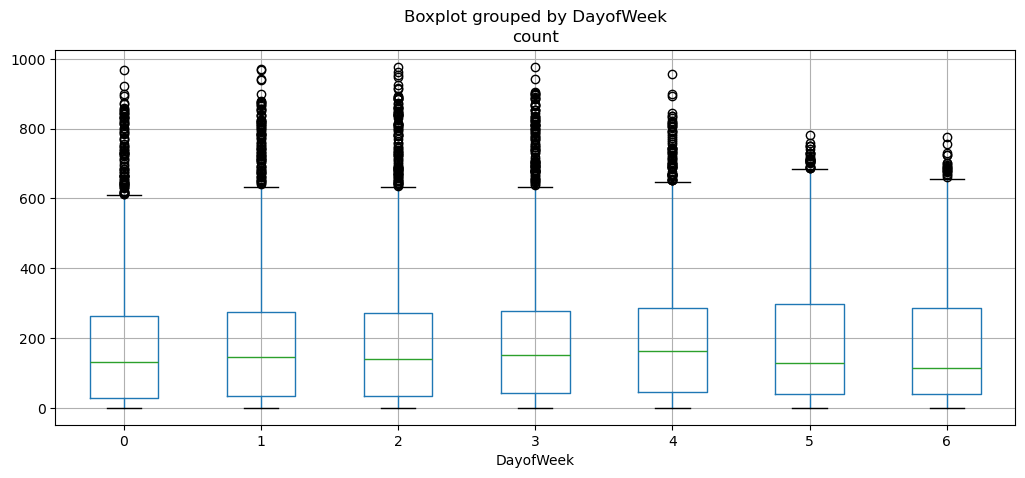

In [65]:
# 요일별 종속변수 분포 확인
df_fe.plot.scatter(y='count', x='DayofWeek', c='temp', grid=True, figsize=(12,5), colormap='viridis')
plt.show()
df_fe.boxplot(column='count', by='DayofWeek', grid=True, figsize=(12,5))
plt.show()

(0.0, 1000.0)

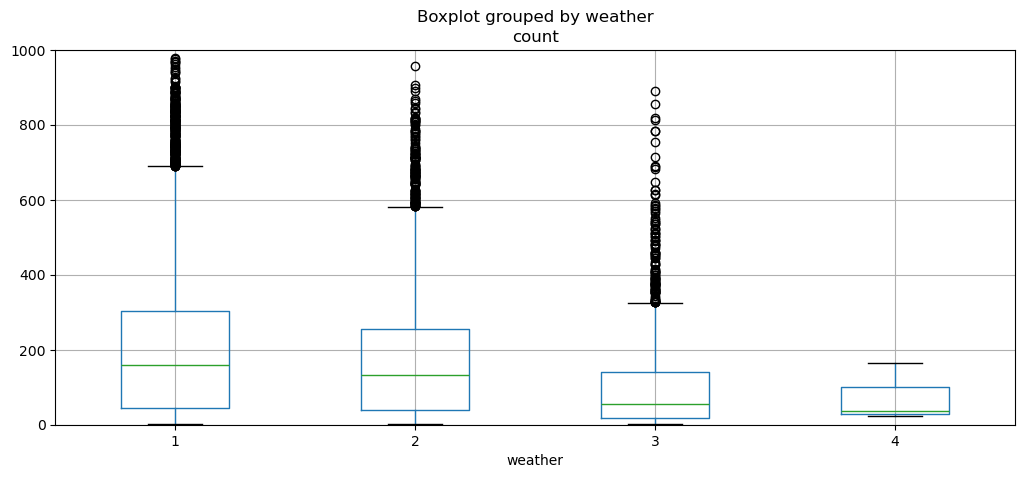

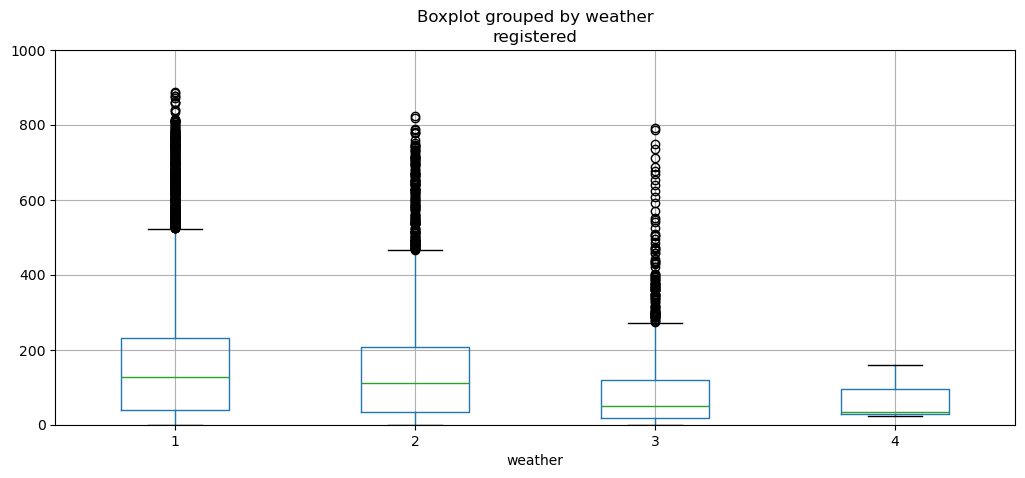

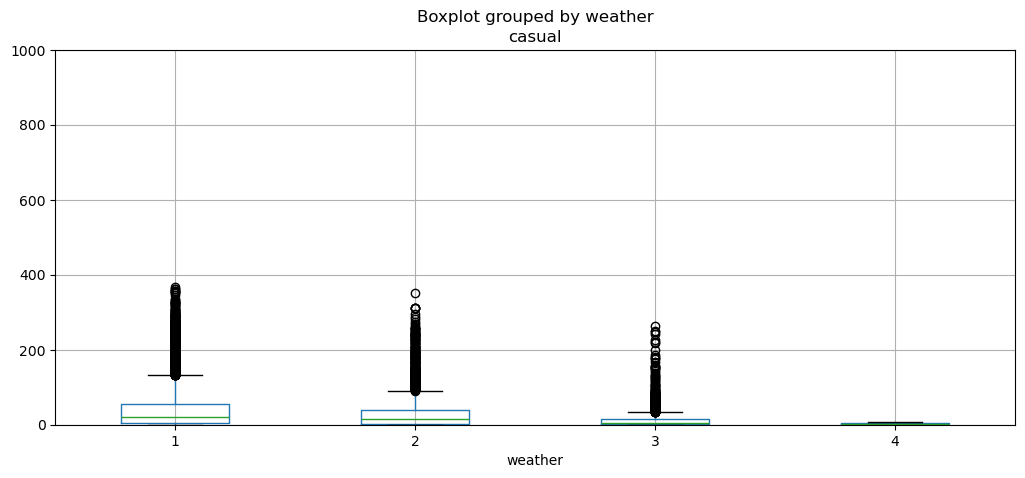

In [66]:
# 날씨별 종속변수 후보군 분포 확인
df_fe.boxplot(column='count', by='weather', grid=True, figsize=(12,5))
plt.ylim(0,1000)
df_fe.boxplot(column='registered', by='weather', grid=True, figsize=(12,5))
plt.ylim(0,1000)
df_fe.boxplot(column='casual', by='weather', grid=True, figsize=(12,5))
plt.ylim(0,1000)

- `다른 관점`에서의 시각화를 위해 `별도 DataFrame 생성`

In [67]:
# 날씨 변수의 히스토그램 분포 확인
df_fe['weather'].value_counts()

weather
1    11455
2     4563
3     1523
4        3
Name: count, dtype: int64

In [68]:
# 날씨 변수의 히스토그램 분포비율 확인
pd.DataFrame(df_fe['weather'].value_counts()/df_fe['weather'].value_counts().sum()*100).T

weather,1,2,3,4
count,65.29,26.01,8.68,0.02


In [69]:
# 날씨별 종속변수의 히스토그램 분포 확인
pd.crosstab(index=df_fe['count'], columns=df_fe['weather'], margins=True)

weather,1,2,3,4,All
count,,,,,
1,100,45,27,0,172
2,136,59,37,0,232
3,136,66,41,0,243
4,149,62,36,0,247
5,164,63,36,0,263
...,...,...,...,...,...
968,1,0,0,0,1
970,1,0,0,0,1
976,1,0,0,0,1


In [70]:
# 날씨별 종속변수의 히스토그램 분포비율 확인
sub_table = pd.crosstab(index=df_fe['count'], columns=df_fe['weather'], margins=True)
sub_table/sub_table.loc['All']*100

weather,1,2,3,4,All
count,,,,,
1,0.87,0.99,1.77,0.00,0.98
2,1.19,1.29,2.43,0.00,1.32
3,1.19,1.45,2.69,0.00,1.39
4,1.30,1.36,2.36,0.00,1.41
5,1.43,1.38,2.36,0.00,1.50
...,...,...,...,...,...
968,0.01,0.00,0.00,0.00,0.01
970,0.01,0.00,0.00,0.00,0.01
976,0.01,0.00,0.00,0.00,0.01


In [71]:
# 날씨와 요일을 index로 그룹핑하여 변수별 평균 계산
# df_fe.groupby(['weather', 'DayofWeek']).count()
df_fe.groupby(['weather', 'DayofWeek']).mean()

datetime  season  holiday  workingday  \
weather DayofWeek                                                              
1       0         2011-12-23 10:59:08.055207168    2.45     0.14        0.86   
        1         2011-12-28 22:42:49.744597248    2.48     0.00        1.00   
        2         2012-01-08 13:29:54.292961280    2.50     0.01        0.99   
        3         2012-01-13 05:00:04.337349376    2.53     0.03        0.97   
        4         2012-01-01 19:36:10.042449920    2.56     0.03        0.97   
...                                         ...     ...      ...         ...   
3       5         2011-11-22 14:34:01.791044864    2.31     0.00        0.00   
        6         2012-01-28 02:11:38.823529472    2.62     0.00        0.00   
4       0         2012-01-09 18:00:00.000000000    1.00     0.00        1.00   
        2         2011-01-26 16:00:00.000000000    1.00     0.00        1.00   
        5         2012-01-21 01:00:00.000000000    1.00     0.00        0.00   

                   temp  atemp  humidity  windspeed  casual  registered  ...  \
weather DayofWeek                                                        ...   
1       0         20.70  24.23     59.05      12.86   30.40      160.04  ...   
        1         21.36  24.89     57.11      12.95   27.57      186.58  ...   
        2         21.61  25.08     58.23      12.22   26.65      181.52  ...   
        3         21.35  24.88     55.85      13.01   28.95      184.81  ...   
        4         20.71  24.00     57.06      12.73   33.50      168.64  ...   
...                 ...    ...       ...        ...     ...         ...  ...   
3       5         17.50  20.48     86.43      18.08   26.43       70.57  ...   
        6         19.17  22.40     81.39      16.12   31.76       84.02  ...   
4       0          8.20  11.37     86.00       6.00    6.00      158.00  ...   
        2          9.02   9.85     93.00      22.00    1.00       35.00  ...   
        5          5.74   6.82     86.00      13.00    1.00       22.00  ...   

                      Year  Quater_ver2  Month   Day  Hour  count_lag1  \
weather DayofWeek                                                        
1       0         2,011.49         4.42   6.36 15.64 11.39      188.77   
        1         2,011.51         4.48   6.22 16.16 12.17      213.34   
        2         2,011.53         4.59   6.41 15.86 11.60      207.08   
        3         2,011.54         4.64   6.51 15.01 11.90      213.36   
        4         2,011.49         4.52   6.71 15.41 11.57      203.38   
...                    ...          ...    ...   ...   ...         ...   
3       5         2,011.46         4.15   5.71 16.32 12.18      109.89   
        6         2,011.58         4.87   6.46 14.36 13.77      143.89   
4       0         2,012.00         5.00   1.00  9.00 18.00      152.00   
        2         2,011.00         1.00   1.00 26.00 16.00       43.00   
        5         2,012.00         5.00   1.00 21.00  1.00       24.00   

                   count_lag2  Quater_Dummy_2  Quater_Dummy_3  Quater_Dummy_4  
weather DayofWeek                                                              
1       0              188.68            0.25            0.27            0.22  
        1              213.59            0.24            0.30            0.20  
        2              209.14            0.27            0.30            0.20  
        3              214.26            0.28            0.28            0.22  
        4              204.10            0.28            0.25            0.26  
...                       ...             ...             ...             ...  
3       5              120.54            0.21            0.30            0.17  
        6              166.62            0.25            0.28            0.25  
4       0               49.00            0.00            0.00            0.00  
        2               36.00            0.00            0.00            0.00  
        5               38.00     

In [72]:
# 날씨와 요일을 index로 그룹핑하여 변수별 기초통계 계산
df_fe.groupby(['weather', 'DayofWeek']).describe()

datetime                                 \
                     count                           mean   
weather DayofWeek                                           
1       0             1594  2011-12-23 10:59:08.055206912   
        1             1527  2011-12-28 22:42:49.744597248   
        2             1577  2012-01-08 13:29:54.292961536   
        3             1660  2012-01-13 05:00:04.337349376   
        4             1649  2012-01-01 19:36:10.042449920   
...                    ...                            ...   
3       5              201  2011-11-22 14:34:01.791044864   
        6              170  2012-01-28 02:11:38.823529472   
4       0                1            2012-01-09 18:00:00   
        2                1            2011-01-26 16:00:00   
        5                1            2012-01-21 01:00:00   

                                                             \
                                   min                  25%   
weather DayofWeek                                             
1       0          2011-01-03 00:00:00  2011-07-04 07:15:00   
        1          2011-01-04 00:00:00  2011-07-12 10:30:00   
        2          2011-01-05 00:00:00  2011-07-06 17:00:00   
        3          2011-01-06 00:00:00  2011-07-14 02:45:00   
        4          2011-01-07 07:00:00  2011-07-15 05:00:00   
...                                ...                  ...   
3       5          2011-01-01 18:00:00  2011-05-14 23:00:00   
        6          2011-01-02 06:00:00  2011-08-07 16:15:00   
4       0          2012-01-09 18:00:00  2012-01-09 18:00:00   
        2          2011-01-26 16:00:00  2011-01-26 16:00:00   
        5          2012-01-21 01:00:00  2012-01-21 01:00:00   

                                                             \
                                   50%                  75%   
weather DayofWeek                                             
1       0          2011-12-26 06:30:00  2012-06-11 13:45:00   
        1          2012-01-03 22:00:00  2012-06-26 00:30:00   
        2          2012-01-25 05:00:00  2012-07-11 20:00:00   
        3          2012-02-02 21:30:00  2012-07-12 10:15:00   
        4          2011-12-23 18:00:00  2012-06-15 17:00:00   
...                                ...                  ...   
3       5          2011-10-29 12:00:00  2012-03-24 19:00:00   
        6          2012-02-19 21:30:00  2012-08-19 19:15:00   
4       0          2012-01-09 18:00:00  2012-01-09 18:00:00   
        2          2011-01-26 16:00:00  2011-01-26 16:00:00   
        5          2012-01-21 01:00:00  2012-01-21 01:00:00   

                                              season       ... Quater_Dummy_3  \
                                   max  std    count mean  ...            max   
weather DayofWeek                                          ...                  
1       0          2012-12-31 23:00:00  NaN 1,594.00 2.45  ...           1.00   
        1          2012-12-25 15:00:00  NaN 1,527.00 2.48  ...           1.00   
        2          2012-12-26 04:00:00  NaN 1,577.00 2.50  ...           1.00   
        3          2012-12-27 20:00:00  NaN 1,660.00 2.53  ...           1.00   
        4          2012-12-28 18:00:00  NaN 1,649.00 2.56  ...           1.00   
...                                ...  ...      ...  ...  ...            ...   
3       5          2012-12-29 13:00:00  NaN   201.00 2.31  ...           1.00   
        6          2012-12-16 18:00:00  NaN   170.00 2.62  ...           1.00   
4       0          2012-01-09 18:00:00  NaN     1.00 1.00  ...           0.00   
        2          2011-01-26 16:00:00  NaN     1.00 1.00  ...           0.00   
        5          2012-01-21 01:00:00  NaN     1.00 1.00  ...           0.00   

                       Quater_Dummy_4                                     
                   std          count mean  min  25%  50%  75%  max  std  
weather DayofWeek                                                         
1       0         0.45       1,594.00

In [73]:
# 날씨와 요일을 index로 그룹핑하여 특정 변수의 통계량 확인
df_fe.groupby(['weather', 'DayofWeek']).agg({'count':[sum, min, max]})

count          
                      sum  min  max
weather DayofWeek                  
1       0          303551    1  968
        1          326993    1  970
        2          328285    1  977
        3          354852    1  976
        4          333333    1  900
...                   ...  ...  ...
3       5           19498    1  584
        6           19683    1  626
4       0             164  164  164
        2              36   36   36
        5              23   23   23

[24 rows x 3 columns]

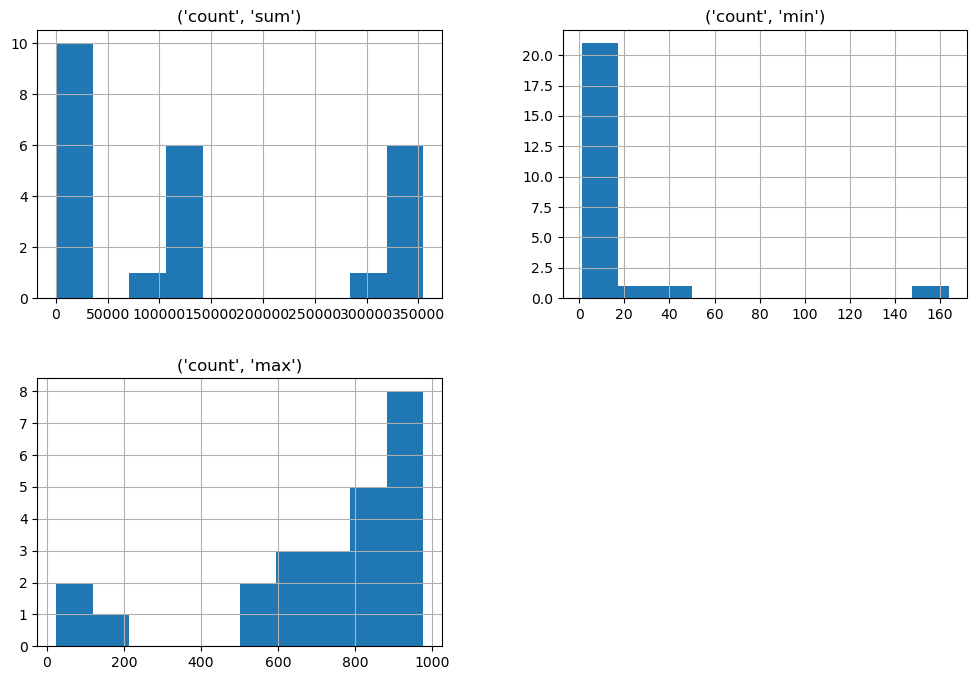

In [74]:
# 날씨와 요일을 index로 그룹핑하여 특정 변수의 통계량 시각화
df_fe.groupby(['weather', 'DayofWeek']).agg({'count':[sum, min, max]}).hist(grid=True, figsize=(12,8))
plt.show()

In [75]:
# 날씨로 index로 그룹핑 결과는 dictionary로 저장 확인
for key, item in df_fe.groupby('weather'):
    display(key, item)

1

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,...,1,1,1,0,5,16.00,16.00,0,0,0
2011-01-01 01:00:00,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,...,1,1,1,1,5,16.00,16.00,0,0,0
2011-01-01 02:00:00,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,...,1,1,1,2,5,40.00,16.00,0,0,0
2011-01-01 03:00:00,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,...,1,1,1,3,5,32.00,40.00,0,0,0
2011-01-01 04:00:00,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,...,1,1,1,4,5,13.00,32.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 07:00:00,2012-12-31 07:00:00,1,0,1,1,6.56,9.09,64,9.00,2,...,8,12,31,7,0,40.00,9.00,0,0,1
2012-12-31 08:00:00,2012-12-31 08:00:00,1,0,1,1,5.74,7.58,69,9.00,9,...,8,12,31,8,0,85.00,40.00,0,0,1
2012-12-31 21:00:00,2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,7,...,8,12,31,21,0,89.00,119.00,0,0,1


2

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 05:00:00,2011-01-01 05:00:00,1,0,0,2,9.84,12.88,75,6.00,0,...,1,1,1,5,5,1.00,13.00,0,0,0
2011-01-01 13:00:00,2011-01-01 13:00:00,1,0,0,2,18.86,22.73,72,20.00,47,...,1,1,1,13,5,84.00,56.00,0,0,0
2011-01-01 14:00:00,2011-01-01 14:00:00,1,0,0,2,18.86,22.73,72,19.00,35,...,1,1,1,14,5,94.00,84.00,0,0,0
2011-01-01 15:00:00,2011-01-01 15:00:00,1,0,0,2,18.04,21.97,77,20.00,40,...,1,1,1,15,5,106.00,94.00,0,0,0
2011-01-01 16:00:00,2011-01-01 16:00:00,1,0,0,2,17.22,21.21,82,20.00,41,...,1,1,1,16,5,110.00,106.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 16:00:00,2012-12-31 16:00:00,1,0,1,2,10.66,12.88,48,13.00,30,...,8,12,31,16,0,315.00,247.00,0,0,1
2012-12-31 17:00:00,2012-12-31 17:00:00,1,0,1,2,10.66,14.39,48,6.00,14,...,8,12,31,17,0,214.00,315.00,0,0,1
2012-12-31 18:00:00,2012-12-31 18:00:00,1,0,1,2,10.66,13.63,48,9.00,10,...,8,12,31,18,0,164.00,214.00,0,0,1


3

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 18:00:00,2011-01-01 18:00:00,1,0,0,3,17.22,21.21,88,17.00,9,...,1,1,1,18,5,67.00,93.00,0,0,0
2011-01-01 19:00:00,2011-01-01 19:00:00,1,0,0,3,17.22,21.21,88,17.00,6,...,1,1,1,19,5,35.00,67.00,0,0,0
2011-01-02 06:00:00,2011-01-02 06:00:00,1,0,0,3,17.22,21.21,77,20.00,0,...,1,1,2,6,6,3.00,3.00,0,0,0
2011-01-02 08:00:00,2011-01-02 08:00:00,1,0,0,3,16.40,20.45,71,15.00,0,...,1,1,2,8,6,1.00,2.00,0,0,0
2011-01-02 14:00:00,2011-01-02 14:00:00,1,0,0,3,14.76,17.43,76,13.00,4,...,1,1,2,14,6,75.00,93.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-27 01:00:00,2012-12-27 01:00:00,1,0,1,3,9.84,9.85,93,30.00,0,...,8,12,27,1,3,3.00,10.00,0,0,1
2012-12-29 10:00:00,2012-12-29 10:00:00,1,0,0,3,10.66,12.12,81,9.00,6,...,8,12,29,10,5,49.00,44.00,0,0,1
2012-12-29 11:00:00,2012-12-29 11:00:00,1,0,0,3,8.20,12.12,93,6.00,7,...,8,12,29,11,5,41.00,49.00,0,0,1


4

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-26 16:00:00,2011-01-26 16:00:00,1,0,1,4,9.02,9.85,93,22.00,1,...,1,1,26,16,2,43.00,36.00,0,0,0
2012-01-09 18:00:00,2012-01-09 18:00:00,1,0,1,4,8.20,11.37,86,6.00,6,...,5,1,9,18,0,152.00,49.00,0,0,0
2012-01-21 01:00:00,2012-01-21 01:00:00,1,0,0,4,5.74,6.82,86,13.00,1,...,5,1,21,1,5,24.00,38.00,0,0,0


In [76]:
# 온도 변수를 10개의 범주로 구간화 후 히스토그램 확인
# pd.cut(df_fe['temp'], 10)
pd.cut(df_fe['temp'], 10).value_counts()

temp
(24.928, 28.946]    3164
(12.874, 16.892]    2926
(20.91, 24.928]     2687
(16.892, 20.91]     2474
(8.856, 12.874]     2466
(28.946, 32.964]    1976
(4.838, 8.856]      1018
(32.964, 36.982]     625
(0.78, 4.838]        124
(36.982, 41.0]        84
Name: count, dtype: int64

In [77]:
# 온도 변수를 10개의 범주로 구간화한 결과를 index로 그룹핑하여 변수들의 특성 확인
df_fe.groupby(pd.cut(df_fe['temp'], 10)).describe()

datetime                                                      \
                    count                           mean                  min   
temp                                                                            
(0.78, 4.838]         124  2011-05-03 21:26:36.774193408  2011-01-08 23:00:00   
(4.838, 8.856]       1018  2011-06-26 01:28:59.882121728  2011-01-01 07:00:00   
(8.856, 12.874]      2466  2011-12-24 14:05:38.686131200  2011-01-01 00:00:00   
(12.874, 16.892]     2926  2012-01-14 10:21:51.551606272  2011-01-01 09:00:00   
(16.892, 20.91]      2474  2012-01-18 23:49:15.375909376  2011-01-01 12:00:00   
(20.91, 24.928]      2687  2012-01-21 18:22:31.842203136  2011-02-14 11:00:00   
(24.928, 28.946]     3164  2012-01-21 08:50:50.442477824  2011-02-18 14:00:00   
(28.946, 32.964]     1976  2012-01-16 16:42:41.538461696  2011-04-04 14:00:00   
(32.964, 36.982]      625     2012-01-16 19:26:29.760000  2011-05-26 13:00:00   
(36.982, 41.0]         84  2012-02-18 02:34:17.142857216  2011-06-08 14:00:00   

                                                            \
                                  25%                  50%   
temp                                                         
(0.78, 4.838]     2011-01-22 07:45:00  2011-01-24 03:30:00   
(4.838, 8.856]    2011-01-17 23:00:00  2011-02-11 22:30:00   
(8.856, 12.874]   2011-03-26 00:15:00  2012-01-06 07:30:00   
(12.874, 16.892]  2011-09-20 01:15:00  2012-01-05 15:30:00   
(16.892, 20.91]   2011-10-06 20:15:00  2012-01-27 08:30:00   
(20.91, 24.928]   2011-08-31 15:00:00  2012-03-13 00:00:00   
(24.928, 28.946]  2011-07-26 03:45:00  2012-03-19 17:30:00   
(28.946, 32.964]  2011-07-18 21:45:00  2011-09-20 17:30:00   
(32.964, 36.982]  2011-07-20 17:00:00  2012-05-29 15:00:00   
(36.982, 41.0]    2011-07-28 00:45:00  2012-06-30 16:30:00   

                                                                  season       \
                                  75%                  max  std    count mean   
temp                                                                            
(0.78, 4.838]     2012-01-03 23:15:00  2012-02-13 08:00:00  NaN   124.00 1.00   
(4.838, 8.856]    2012-01-13 23:45:00  2012-12-31 10:00:00  NaN 1,018.00 1.22   
(8.856, 12.874]   2012-04-23 05:45:00  2012-12-31 23:00:00  NaN 2,466.00 2.02   
(12.874, 16.892]  2012-04-29 00:45:00  2012-12-30 19:00:00  NaN 2,926.00 2.51   
(16.892, 20.91]   2012-05-03 00:45:00  2012-12-21 03:00:00  NaN 2,474.00 2.66   
(20.91, 24.928]   2012-06-14 04:30:00  2012-12-10 19:00:00  NaN 2,687.00 2.71   
(24.928, 28.946]  2012-07-23 04:15:00  2012-10-26 15:00:00  NaN 3,164.00 2.73   
(28.946, 32.964]  2012-07-23 16:00:00  2012-10-24 16:00:00  NaN 1,976.00 2.80   
(32.964, 36.982]  2012-07-10 14:00:00  2012-09-08 14:00:00  NaN   625.00 2.86   
(36.982, 41.0]    2012-07-07 15:15:00  2012-07-26 18:00:00  NaN    84.00 2.90   

                  ... Quater_Dummy_3      Quater_Dummy_4                      \
                  ...            max  std          count mean  min  25%  50%   
temp              ...                                                          
(0.78, 4.838]     ...           0.00 0.00         124.00 0.00 0.00 0.00 0.00   
(4.838, 8.856]    ...           0.00 0.00       1,018.00 0.11 0.00 0.00 0.00   
(8.856, 12.874]   ...           0.00 0.00       2,466.00 0.42 0.00 0.00 0.00   
(12.874, 16.892]  ...           1.00 0.05       2,926.00 0.49 0.00 0.00 0.00   
(16.892, 20.91]   ...           1.00 0.23       2,474.00 0.42 0.00 0.00 0.00   
(20.91, 24.928]   ...           1.00 0.43       2,687.00 0.23 0.00 0.00 0.00   
(24.928, 28.946]  ...           1.00 0.50       3,164.00 0.05 0.00 0.00 0.00   
(28.946, 32.964]  ...           1.00 0.46       1,976.00 0.01 0.00 0.00 0.00   
(32.964, 36.982]  ...           1.00 0.44         625.00 0.00 0.00 0.00 0.00   
(36.982, 41.0]    ...           1.00 0.40          84.00 0.00 0.00 0.00 0.00   

                                 
                  75%  max 

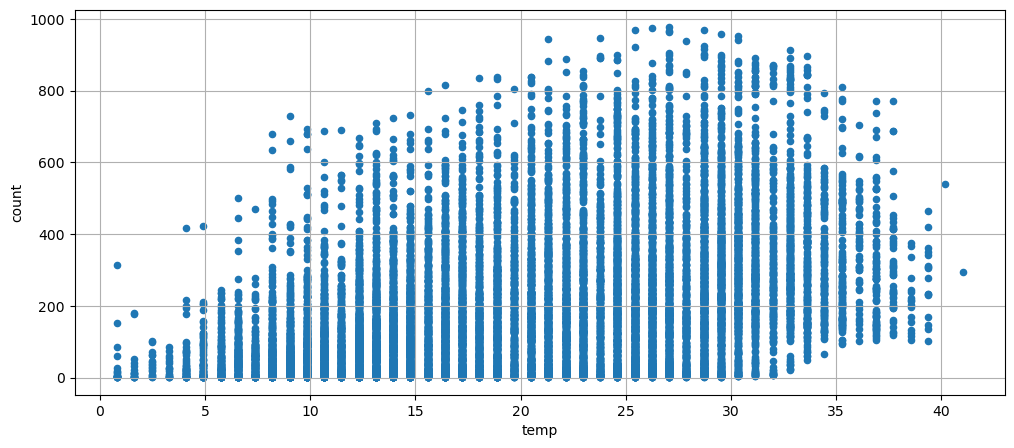

In [78]:
# 온도별 종속변수 움직임 확인
df_fe.plot.scatter(y='count', x='temp', grid=True, figsize=(12,5))
plt.show()

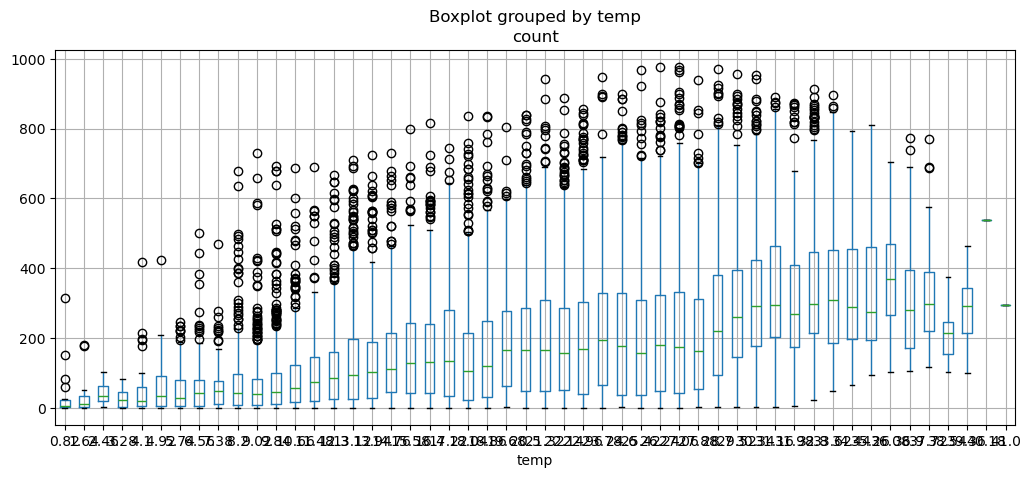

In [79]:
# 온도별 종속변수 움직임 확인
df_fe.boxplot(column='count', by='temp', grid=True, figsize=(12,5))
plt.show()

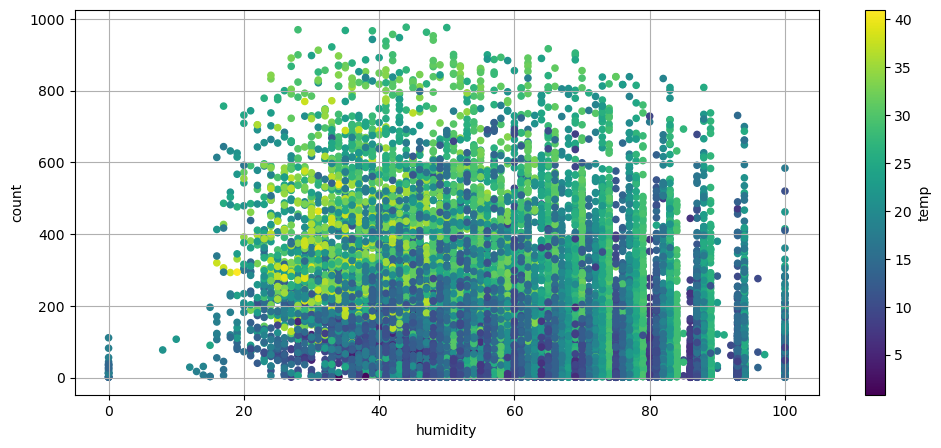

In [80]:
# 습도별 종속변수 및 온도 움직임 확인
df_fe.plot.scatter(y='count', x='humidity', c='temp', grid=True, figsize=(12,5), colormap='viridis')
plt.show()

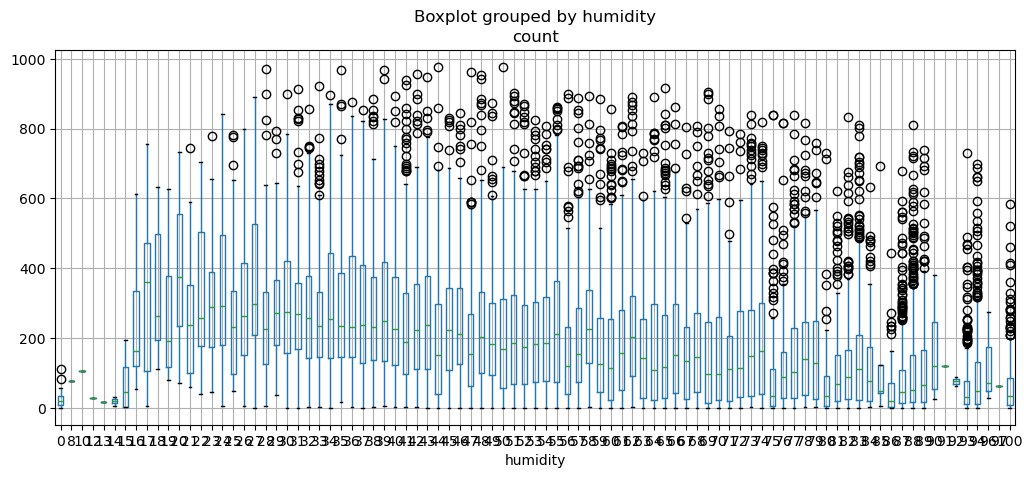

In [81]:
# 습도별 종속변수 움직임 확인
df_fe.boxplot(column='count', by='humidity', grid=True, figsize=(12,5))
plt.show()

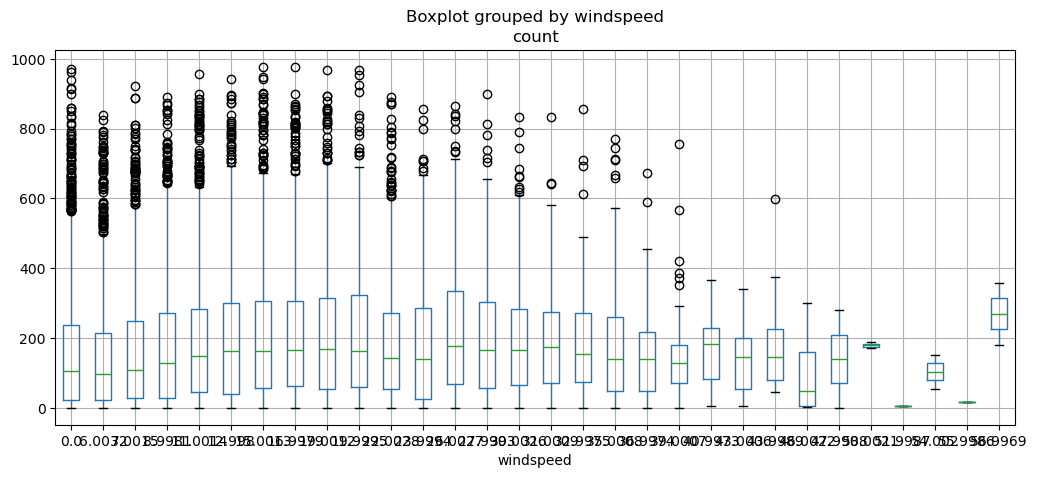

In [82]:
# 바람세기별 종속변수 움직임 확인
df_fe.boxplot(column='count', by='windspeed', grid=True, figsize=(12,5))
plt.show()

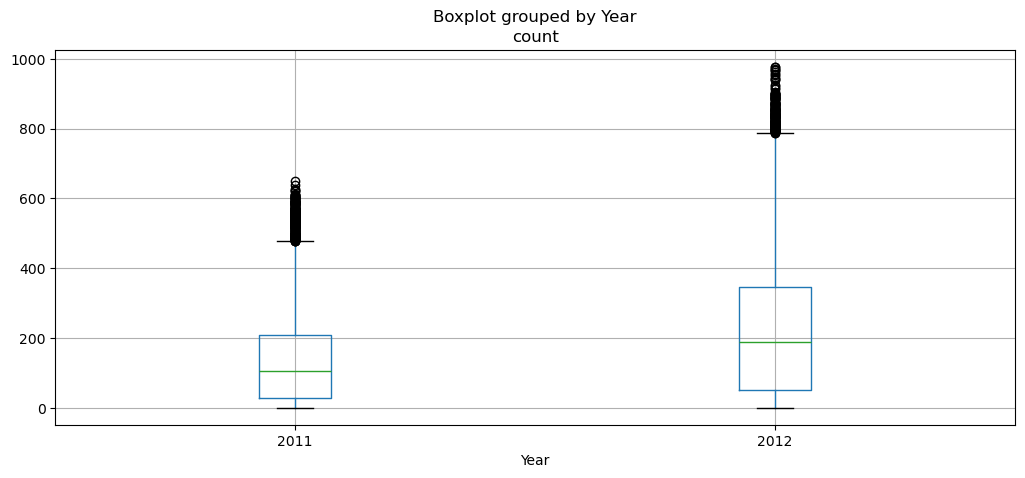

In [83]:
# 연도별 종속변수 움직임 확인
df_fe.boxplot(column='count', by='Year', grid=True, figsize=(12,5))
plt.show()

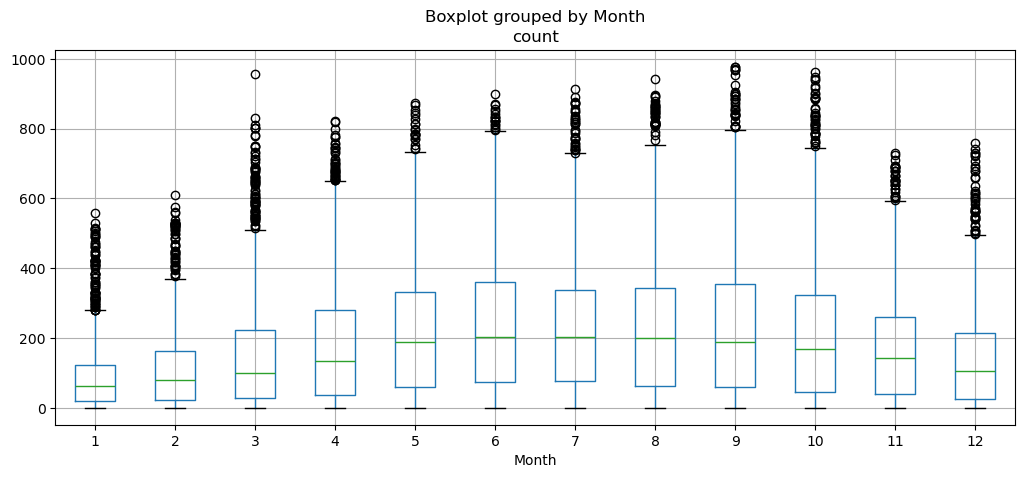

In [84]:
# 월별 종속변수 움직임 확인
df_fe.boxplot(column='count', by='Month', grid=True, figsize=(12,5))
plt.show()

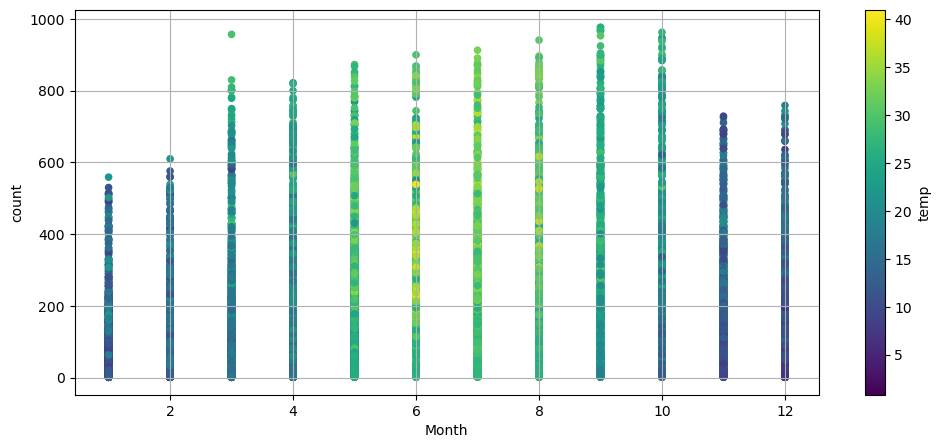

In [85]:
# 월별 종속변수 및 온도 움직임 확인
df_fe.plot.scatter(y='count', x='Month', c='temp', grid=True, figsize=(12,5), colormap='viridis')
plt.show()

In [86]:
# 전체 변수 히스토그램 및 상관관계 확인
# 추정 시간이 오래 걸려서 이미지로 대체
# pd.plotting.scatter_matrix(df_fe, figsize=(18,18), diagonal='kde')
# plt.show()

<img src='Image/Advanced/Scatter_Matrix.png' width='800'>

In [87]:
# 상관관계 계산하기
rs = np.random.RandomState(0)
rs_df = pd.DataFrame(rs.rand(10, 10))
corr = rs_df.corr()
corr.style.background_gradient(cmap='coolwarm')
corr

,0,1,2,3,4,5,6,7,8,9
0,1.00,0.35,0.40,0.46,0.07,-0.23,-0.73,0.48,-0.44,0.02
1,0.35,1.00,-0.28,0.57,-0.29,0.38,-0.36,0.64,0.25,0.19
2,0.40,-0.28,1.00,-0.52,0.15,-0.14,-0.09,0.02,-0.43,-0.38
3,0.46,0.57,-0.52,1.00,-0.23,-0.23,-0.48,0.47,0.28,0.45
4,0.07,-0.29,0.15,-0.23,1.00,-0.10,-0.15,-0.52,-0.61,-0.19
5,-0.23,0.38,-0.14,-0.23,-0.10,1.00,-0.03,0.42,0.21,0.10
6,-0.73,-0.36,-0.09,-0.48,-0.15,-0.03,1.00,-0.49,0.38,-0.35
7,0.48,0.64,0.02,0.47,-0.52,0.42,-0.49,1.00,0.38,0.42
8,-0.44,0.25,-0.43,0.28,-0.61,0.21,0.38,0.38,1.00,0.15
9,0.02,0.19,-0.38,0.45,-0.19,0.10,-0.35,0.42,0.15,1.00


- 최신버전에서는 아래와 같이 코드가 변경됨

> **이전:** `df_fe.corr().style.background_gradient().set_precision(2)`
>
> **이후:** `df_fe.corr().style.background_gradient().format("{:.2f}")`

In [88]:
# 상관관계 계산하기
df_fe.corr()
df_fe.corr().style.background_gradient()
df_fe.corr().style.background_gradient().format("{:.2f}")

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,count_trend,count_seasonal,count_Day,count_Week,count_diff,Year,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
datetime,1.00,0.41,0.01,-0.00,-0.02,0.14,0.15,0.01,-0.08,0.16,0.28,0.28,0.63,0.00,0.64,0.72,-0.00,0.87,0.99,0.50,0.05,-0.01,0.00,0.28,0.28,-0.13,0.12,0.38
season,0.41,1.00,-0.02,0.02,-0.02,0.32,0.33,0.15,-0.14,0.12,0.18,0.18,0.41,0.00,0.41,0.47,-0.00,-0.00,0.42,0.83,-0.00,-0.01,-0.01,0.18,0.18,-0.20,0.31,0.60
holiday,0.01,-0.02,1.00,-0.26,-0.00,-0.04,-0.04,-0.01,0.01,0.03,-0.05,-0.04,-0.08,-0.00,-0.07,-0.04,-0.00,0.00,0.01,0.01,-0.01,0.01,-0.19,-0.04,-0.04,-0.03,-0.03,0.05
workingday,-0.00,0.02,-0.26,1.00,0.04,0.05,0.05,0.02,-0.02,-0.30,0.13,0.03,0.04,0.00,0.02,0.02,0.01,0.00,-0.00,-0.00,0.01,-0.00,-0.70,0.03,0.02,0.01,0.01,-0.02
weather,-0.02,-0.02,-0.00,0.04,1.00,-0.11,-0.11,0.43,0.05,-0.16,-0.13,-0.15,-0.25,-0.00,-0.17,-0.07,-0.02,-0.02,-0.02,0.00,0.01,-0.02,-0.06,-0.14,-0.14,-0.03,-0.07,0.05
temp,0.14,0.32,-0.04,0.05,-0.11,1.00,0.99,-0.07,-0.02,0.46,0.34,0.41,0.60,0.17,0.61,0.62,-0.00,0.05,0.14,0.21,0.02,0.14,-0.03,0.41,0.40,0.26,0.60,-0.31
atemp,0.15,0.33,-0.04,0.05,-0.11,0.99,1.00,-0.06,-0.06,0.46,0.34,0.41,0.61,0.16,0.61,0.62,-0.01,0.05,0.15,0.22,0.02,0.13,-0.03,0.41,0.40,0.27,0.58,-0.29
humidity,0.01,0.15,-0.01,0.02,0.43,-0.07,-0.06,1.00,-0.27,-0.35,-0.28,-0.33,-0.09,-0.34,-0.06,0.04,0.00,-0.08,0.00,0.16,0.03,-0.27,-0.04,-0.33,-0.31,-0.03,0.06,0.10
windspeed,-0.08,-0.14,0.01,-0.02,0.05,-0.02,-0.06,-0.27,1.00,0.08,0.07,0.08,-0.16,0.19,-0.14,-0.10,0.01,-0.01,-0.07,-0.13,0.02,0.14,-0.00,0.08,0.06,0.04,-0.10,-0.06
casual,0.16,0.12,0.03,-0.30,-0.16,0.46,0.46,-0.35,0.08,1.00,0.51,0.70,0.39,0.44,0.39,0.34,0.08,0.14,0.16,0.07,-0.01,0.30,0.24,0.65,0.58,0.15,0.17,-0.10


In [89]:
# 상관관계 계산하기 옵션적용
df_fe.corr().style.background_gradient().format("{:.2f}").set_properties(**{'font-size': '15pt'})

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,count_trend,count_seasonal,count_Day,count_Week,count_diff,Year,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
datetime,1.00,0.41,0.01,-0.00,-0.02,0.14,0.15,0.01,-0.08,0.16,0.28,0.28,0.63,0.00,0.64,0.72,-0.00,0.87,0.99,0.50,0.05,-0.01,0.00,0.28,0.28,-0.13,0.12,0.38
season,0.41,1.00,-0.02,0.02,-0.02,0.32,0.33,0.15,-0.14,0.12,0.18,0.18,0.41,0.00,0.41,0.47,-0.00,-0.00,0.42,0.83,-0.00,-0.01,-0.01,0.18,0.18,-0.20,0.31,0.60
holiday,0.01,-0.02,1.00,-0.26,-0.00,-0.04,-0.04,-0.01,0.01,0.03,-0.05,-0.04,-0.08,-0.00,-0.07,-0.04,-0.00,0.00,0.01,0.01,-0.01,0.01,-0.19,-0.04,-0.04,-0.03,-0.03,0.05
workingday,-0.00,0.02,-0.26,1.00,0.04,0.05,0.05,0.02,-0.02,-0.30,0.13,0.03,0.04,0.00,0.02,0.02,0.01,0.00,-0.00,-0.00,0.01,-0.00,-0.70,0.03,0.02,0.01,0.01,-0.02
weather,-0.02,-0.02,-0.00,0.04,1.00,-0.11,-0.11,0.43,0.05,-0.16,-0.13,-0.15,-0.25,-0.00,-0.17,-0.07,-0.02,-0.02,-0.02,0.00,0.01,-0.02,-0.06,-0.14,-0.14,-0.03,-0.07,0.05
temp,0.14,0.32,-0.04,0.05,-0.11,1.00,0.99,-0.07,-0.02,0.46,0.34,0.41,0.60,0.17,0.61,0.62,-0.00,0.05,0.14,0.21,0.02,0.14,-0.03,0.41,0.40,0.26,0.60,-0.31
atemp,0.15,0.33,-0.04,0.05,-0.11,0.99,1.00,-0.06,-0.06,0.46,0.34,0.41,0.61,0.16,0.61,0.62,-0.01,0.05,0.15,0.22,0.02,0.13,-0.03,0.41,0.40,0.27,0.58,-0.29
humidity,0.01,0.15,-0.01,0.02,0.43,-0.07,-0.06,1.00,-0.27,-0.35,-0.28,-0.33,-0.09,-0.34,-0.06,0.04,0.00,-0.08,0.00,0.16,0.03,-0.27,-0.04,-0.33,-0.31,-0.03,0.06,0.10
windspeed,-0.08,-0.14,0.01,-0.02,0.05,-0.02,-0.06,-0.27,1.00,0.08,0.07,0.08,-0.16,0.19,-0.14,-0.10,0.01,-0.01,-0.07,-0.13,0.02,0.14,-0.00,0.08,0.06,0.04,-0.10,-0.06
casual,0.16,0.12,0.03,-0.30,-0.16,0.46,0.46,-0.35,0.08,1.00,0.51,0.70,0.39,0.44,0.39,0.34,0.08,0.14,0.16,0.07,-0.01,0.30,0.24,0.65,0.58,0.15,0.17,-0.10


In [90]:
# 상관관계 계산하기 테이블 일부 추출
df_fe.corr().iloc[:,8:11]

,windspeed,casual,registered
datetime,-0.08,0.16,0.28
season,-0.14,0.12,0.18
holiday,0.01,0.03,-0.05
workingday,-0.02,-0.30,0.13
weather,0.05,-0.16,-0.13
...,...,...,...
count_lag1,0.08,0.65,0.80
count_lag2,0.06,0.58,0.53
Quater_Dummy_2,0.04,0.15,0.06
Quater_Dummy_3,-0.10,0.17,0.13


In [91]:
# 상관관계 계산하기 테이블 일부 추출
df_fe.corr().loc[:, ['casual', 'registered', 'count']]

,casual,registered,count
datetime,0.16,0.28,0.28
season,0.12,0.18,0.18
holiday,0.03,-0.05,-0.04
workingday,-0.30,0.13,0.03
weather,-0.16,-0.13,-0.15
...,...,...,...
count_lag1,0.65,0.80,0.85
count_lag2,0.58,0.53,0.60
Quater_Dummy_2,0.15,0.06,0.09
Quater_Dummy_3,0.17,0.13,0.15


In [92]:
# 상관관계 계산하기 테이블 일부 추출 옵션 적용
df_fe.corr().loc[:, ['casual', 'registered', 'count']].style.background_gradient().format("{:.2f}").set_properties(**{'font-size': '15pt'})

,casual,registered,count
datetime,0.16,0.28,0.28
season,0.12,0.18,0.18
holiday,0.03,-0.05,-0.04
workingday,-0.30,0.13,0.03
weather,-0.16,-0.13,-0.15
temp,0.46,0.34,0.41
atemp,0.46,0.34,0.41
humidity,-0.35,-0.28,-0.33
windspeed,0.08,0.07,0.08
casual,1.00,0.51,0.70


In [93]:
# 상관관계 계산하기 테이블 일부 추출 옵션 적용
df_fe.corr().iloc[0:8,8:11].style.background_gradient().format("{:.2f}").set_properties(**{'font-size': '15pt'})

,windspeed,casual,registered
datetime,-0.08,0.16,0.28
season,-0.14,0.12,0.18
holiday,0.01,0.03,-0.05
workingday,-0.02,-0.30,0.13
weather,0.05,-0.16,-0.13
temp,-0.02,0.46,0.34
atemp,-0.06,0.46,0.34
humidity,-0.27,-0.35,-0.28


## 시계열 데이터 분리

**1) 시계열 데이터인 경우 `랜덤성(set.seed) 없이 시간축 유지가 핵심!`**

- **훈련셋 < 검증셋 < 테스트셋**

> - **훈련셋(Training set):** `가장 오래된` 데이터
> - **검증셋(Validation set):** `그 다음 최근` 데이터
> - **테스트셋(Testing set):** `가장 최신`의 데이터

<center><img src='Image/Advanced/DataSplit_TimeSeries.png' width='500'></center>

---

**2) 최선의 성능을 가지는 `Robust 모델링`을 위해 `시계열 교차검증` 필수!**

**(1) 모든 미래 시점을 한번에 예측하면 `정확성 낮아짐`:** 미래 시점마다 Train/Test `재분류 필요`

> - **Sliding Window:** `고정된 사이즈의 Train & Test Window`를 움직이며 데이터를 재분리
> - **Expanding Window:** `가변 사이즈 Train Window & 고정된 사이즈 Test Window`를 움직이며 데이터를 재분리

<center><img src='Image/Advanced/DataSplit_TSWindow.png' width='800'>(https://eng.uber.com/forecasting-introduction/)</center>

**(2) 단기/중기/장기 모든 미래시점에 동일 성능을 가지는 `Robust 알고리즘`은 없기 때문에 시점마다 `별도 모델링 필요`**

> - **1스텝 교차검사(One-step Ahead Cross-validation):**
>
> <center><img src='Image/Advanced/DataSplit_TimeSeries_ver1.png' width='500'></center>
>
> - **2스텝 교차검사(Two-step Ahead Cross-validation):**
>
> <center><img src='Image/Advanced/DataSplit_TimeSeries_ver2.png' width='500'></center>



In [94]:
# 종속변수와 독립변수 결정
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
X_colname = [x for x in df_fe.columns if x not in Y_colname+X_remove]
len(X_colname)

24

In [95]:
# 비시계열 데이터의 경우 train_test_split 함수로 데이터 분할
df_train, df_test = train_test_split(df_fe, test_size=0.2, random_state=123)
print(df_train.shape, df_test.shape)

(14035, 28) (3509, 28)


In [96]:
# 비시계열 데이터의 경우 train_test_split 함수로 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(df_fe[X_colname], df_fe[Y_colname], 
                                                    test_size=0.2, random_state=123)
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(14035, 24) (14035, 1)
(3509, 24) (3509, 1)


In [97]:
# 시계열 데이터는 날짜 기준으로 train < test
# index가 날짜로 그리고 빈도가 제대로 반영되어 있는지 확인
df_fe.index

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2012-12-31 14:00:00', '2012-12-31 15:00:00',
               '2012-12-31 16:00:00', '2012-12-31 17:00:00',
               '2012-12-31 18:00:00', '2012-12-31 19:00:00',
               '2012-12-31 20:00:00', '2012-12-31 21:00:00',
               '2012-12-31 22:00:00', '2012-12-31 23:00:00'],
              dtype='datetime64[ns]', name='DateTime', length=17544, freq='h')

In [98]:
# 날짜 index의 경우 쉽게 특정 시점으로 구분 가능
df_fe.index < '2012'

array([ True,  True,  True, ..., False, False, False])

In [99]:
# 날짜 index의 경우 쉽게 특정 시점으로 구분 가능
# Train & Test 분할
df_train = df_fe.loc[df_fe.index < '2012-07-01',:]
df_test = df_fe.loc[df_fe.index >= '2012-07-01',:]
print(df_train.shape, df_test.shape)

(13128, 28) (4416, 28)


In [100]:
# X_train, Y_train, X_test, Y_test 분할
Y_train = df_train[Y_colname]
X_train = df_train[X_colname]
Y_test = df_test[Y_colname]
X_test = df_test[X_colname]
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(13128, 24) (13128, 1)
(4416, 24) (4416, 1)


### Code Summary

In [101]:
# 데이터 분리
## cross sectional 데이터
def datasplit(df, Y_colname, test_size=0.2, random_state=123):
    X_colname = [x for x in df.columns if x not in Y_colname]
       
    X_train, X_test, Y_train, Y_test = train_test_split(df[X_colname], df[Y_colname],
                                                        test_size=test_size, random_state=random_state)
    print(X_train.shape, Y_train.shape)
    print(X_test.shape, Y_test.shape)
    
    return X_train, X_test, Y_train, Y_test


## time series 데이터
def datasplit_ts(df, Y_colname, X_colname, criteria):
    df_train = df.loc[df.index < criteria,:]
    df_test = df.loc[df.index >= criteria,:]
    Y_train = df_train[Y_colname]
    X_train = df_train[X_colname]
    Y_test = df_test[Y_colname]
    X_test = df_test[X_colname]
    print('Train_size:', df_train.shape, 'Test_size:', df_test.shape)
    print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
    print('X_test:', X_test.shape, 'Y_test:', Y_test.shape)
    
    return X_train, X_test, Y_train, Y_test

In [102]:
# 데이터 로딩
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df_all = pd.read_csv(location)

# 데이터 전처리
df_nfe = non_feature_engineering(df_all)
df_fe = feature_engineering(df_all)

# 데이터 분리
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
X_colname = [x for x in df_fe.columns if x not in Y_colname+X_remove]
X_train, X_test, Y_train, Y_test = datasplit_ts(df_fe, Y_colname, X_colname, '2012-07-01')

Train_size: (13128, 28) Test_size: (4416, 28)
X_train: (13128, 24) Y_train: (13128, 1)
X_test: (4416, 24) Y_test: (4416, 1)


## **코드 정리:** 전처리 단계별 코드의 함수화

In [103]:
# 시계열 변수추출
## 날짜인식 및 빈도 설정만
def non_feature_engineering(df):
    df_nfe = df.copy()
    if 'datetime' in df_nfe.columns:
        df_nfe['datetime'] = pd.to_datetime(df_nfe['datetime'])
        df_nfe['DateTime'] = pd.to_datetime(df_nfe['datetime'])
    if df_nfe.index.dtype == 'int64':
        df_nfe.set_index('DateTime', inplace=True)
    df_nfe = df_nfe.asfreq('H', method='ffill')

    return df_nfe


## 날짜인식 및 빈도 설정을 포함한 모든 전처리
def feature_engineering(df):
    df_fe = df.copy()
    if 'datetime' in df_fe.columns:
        df_fe['datetime'] = pd.to_datetime(df_fe['datetime'])
        df_fe['DateTime'] = pd.to_datetime(df_fe['datetime'])

    if df_fe.index.dtype == 'int64':
        df_fe.set_index('DateTime', inplace=True)

    df_fe = df_fe.asfreq('H', method='ffill')

    result = sm.tsa.seasonal_decompose(df_fe['count'], model='additive')
    Y_trend = pd.DataFrame(result.trend)
    Y_trend.fillna(method='ffill', inplace=True)
    Y_trend.fillna(method='bfill', inplace=True)
    Y_trend.columns = ['count_trend']
    Y_seasonal = pd.DataFrame(result.seasonal)
    Y_seasonal.fillna(method='ffill', inplace=True)
    Y_seasonal.fillna(method='bfill', inplace=True)
    Y_seasonal.columns = ['count_seasonal']
    pd.concat([df_fe, Y_trend, Y_seasonal], axis=1).isnull().sum()
    if 'count_trend' not in df_fe.columns:
        if 'count_seasonal' not in df_fe.columns:
            df_fe = pd.concat([df_fe, Y_trend, Y_seasonal], axis=1)

    Y_count_Day = df_fe[['count']].rolling(24).mean()
    Y_count_Day.fillna(method='ffill', inplace=True)
    Y_count_Day.fillna(method='bfill', inplace=True)
    Y_count_Day.columns = ['count_Day']
    Y_count_Week = df_fe[['count']].rolling(24*7).mean()
    Y_count_Week.fillna(method='ffill', inplace=True)
    Y_count_Week.fillna(method='bfill', inplace=True)
    Y_count_Week.columns = ['count_Week']
    if 'count_Day' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_count_Day], axis=1)
    if 'count_Week' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_count_Week], axis=1)

    Y_diff = df_fe[['count']].diff()
    Y_diff.fillna(method='ffill', inplace=True)
    Y_diff.fillna(method='bfill', inplace=True)
    Y_diff.columns = ['count_diff']
    if 'count_diff' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_diff], axis=1)

#     df_fe['temp_group'] = pd.cut(df_fe['temp'], 10)
    df_fe['Year'] = df_fe.datetime.dt.year
    df_fe['Quater'] = df_fe.datetime.dt.quarter
    df_fe['Quater_ver2'] = df_fe['Quater'] + (df_fe.Year - df_fe.Year.min()) * 4
    df_fe['Month'] = df_fe.datetime.dt.month
    df_fe['Day'] = df_fe.datetime.dt.day
    df_fe['Hour'] = df_fe.datetime.dt.hour
    df_fe['DayofWeek'] = df_fe.datetime.dt.dayofweek

    df_fe['count_lag1'] = df_fe['count'].shift(1)
    df_fe['count_lag2'] = df_fe['count'].shift(2)
    df_fe['count_lag1'].fillna(method='bfill', inplace=True)
    df_fe['count_lag2'].fillna(method='bfill', inplace=True)

    if 'Quater' in df_fe.columns:
        if 'Quater_Dummy' not in ['_'.join(col.split('_')[:2]) for col in df_fe.columns]:
            df_fe = pd.concat([df_fe, pd.get_dummies(df_fe['Quater'], 
                                                     prefix='Quater_Dummy', drop_first=True).astype(int)], axis=1)
            del df_fe['Quater']
    
    return df_fe


# 데이터 분리
## cross sectional 데이터
def datasplit(df, Y_colname, test_size=0.2, random_state=123):
    X_colname = [x for x in df.columns if x not in Y_colname]
       
    X_train, X_test, Y_train, Y_test = train_test_split(df[X_colname], df[Y_colname],
                                                        test_size=test_size, random_state=random_state)
    print(X_train.shape, Y_train.shape)
    print(X_test.shape, Y_test.shape)
    
    return X_train, X_test, Y_train, Y_test


## time series 데이터
def datasplit_ts(df, Y_colname, X_colname, criteria):
    df_train = df.loc[df.index < criteria,:]
    df_test = df.loc[df.index >= criteria,:]
    Y_train = df_train[Y_colname]
    X_train = df_train[X_colname]
    Y_test = df_test[Y_colname]
    X_test = df_test[X_colname]
    print('Train_size:', df_train.shape, 'Test_size:', df_test.shape)
    print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
    print('X_test:', X_test.shape, 'Y_test:', Y_test.shape)
    
    return X_train, X_test, Y_train, Y_test

In [104]:
# 데이터 로딩
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df_all = pd.read_csv(location)

# 데이터 전처리
df_nfe = non_feature_engineering(df_all)
df_fe = feature_engineering(df_all)

# 데이터 분리
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
X_colname = [x for x in df_fe.columns if x not in Y_colname+X_remove]
X_train, X_test, Y_train, Y_test = datasplit_ts(df_fe, Y_colname, X_colname, '2012-07-01')

Train_size: (13128, 28) Test_size: (4416, 28)
X_train: (13128, 24) Y_train: (13128, 1)
X_test: (4416, 24) Y_test: (4416, 1)


In [105]:
# 전처리 출력
display(X_train, X_test, Y_train, Y_test)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count_trend,count_seasonal,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,41.06,-134.25,...,1,1,1,0,5,16.00,16.00,0,0,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,41.06,-154.75,...,1,1,1,1,5,16.00,16.00,0,0,0
2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,41.06,-165.27,...,1,1,1,2,5,40.00,16.00,0,0,0
2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,41.06,-176.48,...,1,1,1,3,5,32.00,40.00,0,0,0
2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,41.06,-181.67,...,1,1,1,4,5,13.00,32.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-06-30 19:00:00,3,0,0,1,34.44,37.88,44,17.00,241.29,122.70,...,6,6,30,19,5,339.00,362.00,1,0,0
2012-06-30 20:00:00,3,0,0,1,33.62,38.63,52,11.00,239.33,37.48,...,6,6,30,20,5,374.00,339.00,1,0,0
2012-06-30 21:00:00,3,0,0,1,33.62,38.63,52,11.00,237.08,-16.10,...,6,6,30,21,5,292.00,374.00,1,0,0


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count_trend,count_seasonal,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
DateTime,,,,,,,,,,,,,,,,,,,,,
2012-07-01 00:00:00,3,0,0,1,31.16,36.37,66,0.00,230.42,-134.25,...,7,7,1,0,6,152.00,172.00,0,1,0
2012-07-01 01:00:00,3,0,0,1,30.34,34.85,70,9.00,229.46,-154.75,...,7,7,1,1,6,149.00,152.00,0,1,0
2012-07-01 02:00:00,3,0,0,1,29.52,34.85,74,6.00,230.02,-165.27,...,7,7,1,2,6,93.00,149.00,0,1,0
2012-07-01 03:00:00,3,0,0,1,29.52,35.60,84,9.00,229.52,-176.48,...,7,7,1,3,6,90.00,93.00,0,1,0
2012-07-01 04:00:00,3,0,0,1,28.70,33.34,79,13.00,227.04,-181.67,...,7,7,1,4,6,33.00,90.00,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,1,0,1,2,10.66,12.88,60,11.00,113.71,122.70,...,8,12,31,19,0,122.00,164.00,0,0,1
2012-12-31 20:00:00,1,0,1,2,10.66,12.88,60,11.00,113.71,37.48,...,8,12,31,20,0,119.00,122.00,0,0,1
2012-12-31 21:00:00,1,0,1,1,10.66,12.88,60,11.00,113.71,-16.10,...,8,12,31,21,0,89.00,119.00,0,0,1


,count
DateTime,
2011-01-01 00:00:00,16
2011-01-01 01:00:00,40
2011-01-01 02:00:00,32
2011-01-01 03:00:00,13
2011-01-01 04:00:00,1
...,...
2012-06-30 19:00:00,374
2012-06-30 20:00:00,292
2012-06-30 21:00:00,213


,count
DateTime,
2012-07-01 00:00:00,149
2012-07-01 01:00:00,93
2012-07-01 02:00:00,90
2012-07-01 03:00:00,33
2012-07-01 04:00:00,4
...,...
2012-12-31 19:00:00,119
2012-12-31 20:00:00,89
2012-12-31 21:00:00,90


In [106]:
# 전처리 후 통계량 확인하기
display(X_train.describe(), X_test.describe(), Y_train.describe(), Y_test.describe())

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count_trend,count_seasonal,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
count,"13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00",...,"13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00","13,128.00"
mean,2.20,0.03,0.68,1.43,19.66,23.04,62.48,13.21,166.17,0.00,...,3.50,5.52,15.70,11.54,3.00,166.20,166.18,0.33,0.17,0.17
std,1.05,0.17,0.46,0.66,7.87,8.61,20.01,8.44,70.75,128.50,...,1.70,3.31,8.78,6.93,2.00,160.76,160.77,0.47,0.37,0.37
min,1.00,0.00,0.00,1.00,0.82,0.00,0.00,0.00,20.00,-181.67,...,1.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,1.00,13.12,15.91,47.00,7.00,111.45,-117.81,...,2.00,3.00,8.00,6.00,1.00,33.00,33.00,0.00,0.00,0.00
50%,2.00,0.00,1.00,1.00,19.68,23.48,62.00,13.00,170.60,21.32,...,4.00,5.00,16.00,12.00,3.00,123.00,123.00,0.00,0.00,0.00
75%,3.00,0.00,1.00,2.00,26.24,30.30,79.00,19.00,208.73,64.69,...,5.00,8.00,23.00,18.00,5.00,244.00,244.00,1.00,0.00,0.00
max,4.00,1.00,1.00,4.00,40.18,50.00,100.00,57.00,356.75,273.37,...,6.00,12.00,31.00,23.00,6.00,957.00,957.00,1.00,1.00,1.00


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count_trend,count_seasonal,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
count,"4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00",...,"4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00","4,416.00"
mean,3.36,0.03,0.68,1.44,22.20,25.70,64.03,11.64,252.05,0.00,...,7.50,9.49,15.83,11.42,3.00,252.00,252.02,0.00,0.50,0.50
std,0.77,0.18,0.47,0.63,7.74,8.37,17.12,7.74,71.59,128.51,...,0.50,1.71,8.85,6.98,2.02,219.82,219.81,0.00,0.50,0.50
min,1.00,0.00,0.00,1.00,5.74,7.58,16.00,0.00,18.06,-181.67,...,7.00,7.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,3.00,0.00,0.00,1.00,14.76,18.18,50.00,7.00,220.45,-117.81,...,7.00,8.00,8.00,5.00,1.00,54.00,54.00,0.00,0.00,0.00
50%,3.00,0.00,1.00,1.00,22.96,26.52,65.00,11.00,267.19,21.32,...,7.50,9.50,16.00,11.00,3.00,212.00,212.00,0.00,0.50,0.50
75%,4.00,0.00,1.00,2.00,28.70,32.58,78.00,17.00,306.38,64.69,...,8.00,11.00,23.25,17.00,5.00,374.00,374.00,0.00,1.00,1.00
max,4.00,1.00,1.00,3.00,41.00,45.45,100.00,44.00,379.06,273.37,...,8.00,12.00,31.00,23.00,6.00,977.00,977.00,0.00,1.00,1.00


,count
count,"13,128.00"
mean,166.21
std,160.76
min,1.00
25%,33.00
50%,123.00
75%,244.00
max,957.00


,count
count,"4,416.00"
mean,251.97
std,219.84
min,1.00
25%,53.75
50%,212.00
75%,374.00
max,977.00


# **Applying Base Algorithm:** Linear Regression

**1) 알고리즘 함수세팅:** 

$$
\begin{aligned}
Y \approx \hat{Y} &= f(X_1, X_2, ..., X_k) = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_kX_k 
= [\beta_0~\beta_1~\beta_2~\cdots~\beta_k]\begin{bmatrix} 1 \\ X_1 \\ X_2 \\ \vdots \\ X_k \end{bmatrix} \\
&= [1~X_1~X_2~\cdots~X_k]\begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \vdots \\ \beta_k \end{bmatrix} 
= \begin{bmatrix} 1~X_{11}~X_{21}~\cdots~X_{k1} \\ 1~X_{12}~X_{22}~\cdots~X_{k2} \\ \vdots \\ 1~X_{1t}~X_{2t}~\cdots~X_{kt} \end{bmatrix}
\begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \vdots \\ \beta_k \end{bmatrix} = X\beta
\end{aligned}
$$

---

<center><img src='Image/Advanced/Example_LinearRegression.png' width='900'></center>

**2) 함수 추정을 위한 비용함수:** 나의 주장 기반 알고리즘의 `예측값`($\hat{Y}$)과 `실제 데이터`($Y$)의 차이를 평가하는 함수
> - **손실함수(Loss Function):** `하나의 데이터(Single Row)`에서 예측값과 정답의 차이를 평가
> - **비용함수(Cost Function):** `모든 데이터`에서 예측값과 정답의 차이를 평가
> 
> $$
\begin{aligned}
Y - \hat{Y} &= Y - X\beta = \text{residual} = \text{cost} \\
&= \sum_{i=1}^{m} \left[ \sum_{j=1}^{k} (Y_{i} - X_{j}\beta_{j}) \right]
\end{aligned}
$$
>
>
> - `회귀분석`은 여러가지의 비용함수 중 `최소제곱법/최소자승법`을 사용 
> - `최소제곱법/최소자승법`를 최소로 하는 `직선`을 추정하여 `계수(coefficient)`를 결정
>
$$
\begin{aligned}
\hat{\beta} = \underset{\beta}{\arg\min} \sum_{i=1}^{m} \left[\sum_{j=1}^{k} (Y_{i} - X_{j}\beta_{j})^2 \right]
\end{aligned}
$$


<!-- - **비선형변수 효과:** 로그 또는 제곱근 등의 변환된 변수 사용시 회귀분석 성능 향상 가능
    - 독립 변수나 종속 변수가 심하게 한쪽으로 치우친 분포를 보이는 경우
    - 독립 변수와 종속 변수간의 관계가 곱셈 혹은 나눗셉으로 연결된 경우
    - 종속 변수와 예측치가 비선형 관계를 보이는 경우 -->

## 종속변수와 독립변수의 관계성 확인하기

In [107]:
# 종속변수와 독립변수의 관계 확인을 위해 데이터 붙이기
YX_train = pd.concat([Y_train, X_train], axis=1)
YX_test = pd.concat([Y_test, X_test], axis=1)

In [108]:
# 종속변수와 독립변수의 상관관계 확인하기
YX_test.corr()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count_trend,...,Quater_ver2,Month,Day,Hour,DayofWeek,count_lag1,count_lag2,Quater_Dummy_2,Quater_Dummy_3,Quater_Dummy_4
count,1.00,0.09,-0.04,0.06,-0.13,0.34,0.34,-0.41,0.12,0.32,...,-0.17,-0.18,-0.06,0.44,-0.02,0.83,0.55,NaN,0.17,-0.17
season,0.09,1.00,-0.05,0.05,-0.00,-0.17,-0.13,0.02,-0.07,0.29,...,0.36,0.21,-0.20,-0.01,-0.03,0.09,0.09,NaN,-0.36,0.36
holiday,-0.04,-0.05,1.00,-0.27,-0.02,-0.04,-0.03,0.05,-0.05,-0.14,...,0.06,0.05,-0.07,0.00,-0.18,-0.04,-0.05,NaN,-0.06,0.06
workingday,0.06,0.05,-0.27,1.00,0.03,0.06,0.04,-0.02,-0.05,0.13,...,-0.01,-0.03,0.05,-0.01,-0.70,0.05,0.05,NaN,0.01,-0.01
weather,-0.13,-0.00,-0.02,0.03,1.00,-0.14,-0.14,0.38,0.11,-0.34,...,0.16,0.14,0.01,-0.03,-0.07,-0.12,-0.11,NaN,-0.16,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
count_lag1,0.83,0.09,-0.04,0.05,-0.12,0.34,0.34,-0.39,0.11,0.32,...,-0.17,-0.18,-0.06,0.52,-0.01,1.00,0.83,NaN,0.17,-0.17
count_lag2,0.55,0.09,-0.05,0.05,-0.11,0.33,0.33,-0.36,0.09,0.32,...,-0.17,-0.18,-0.06,0.58,-0.01,0.83,1.00,NaN,0.17,-0.17
Quater_Dummy_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quater_Dummy_3,0.17,-0.36,-0.06,0.01,-0.16,0.82,0.79,-0.04,-0.08,0.51,...,-1.00,-0.88,0.00,0.01,0.02,0.17,0.17,NaN,1.00,-1.00


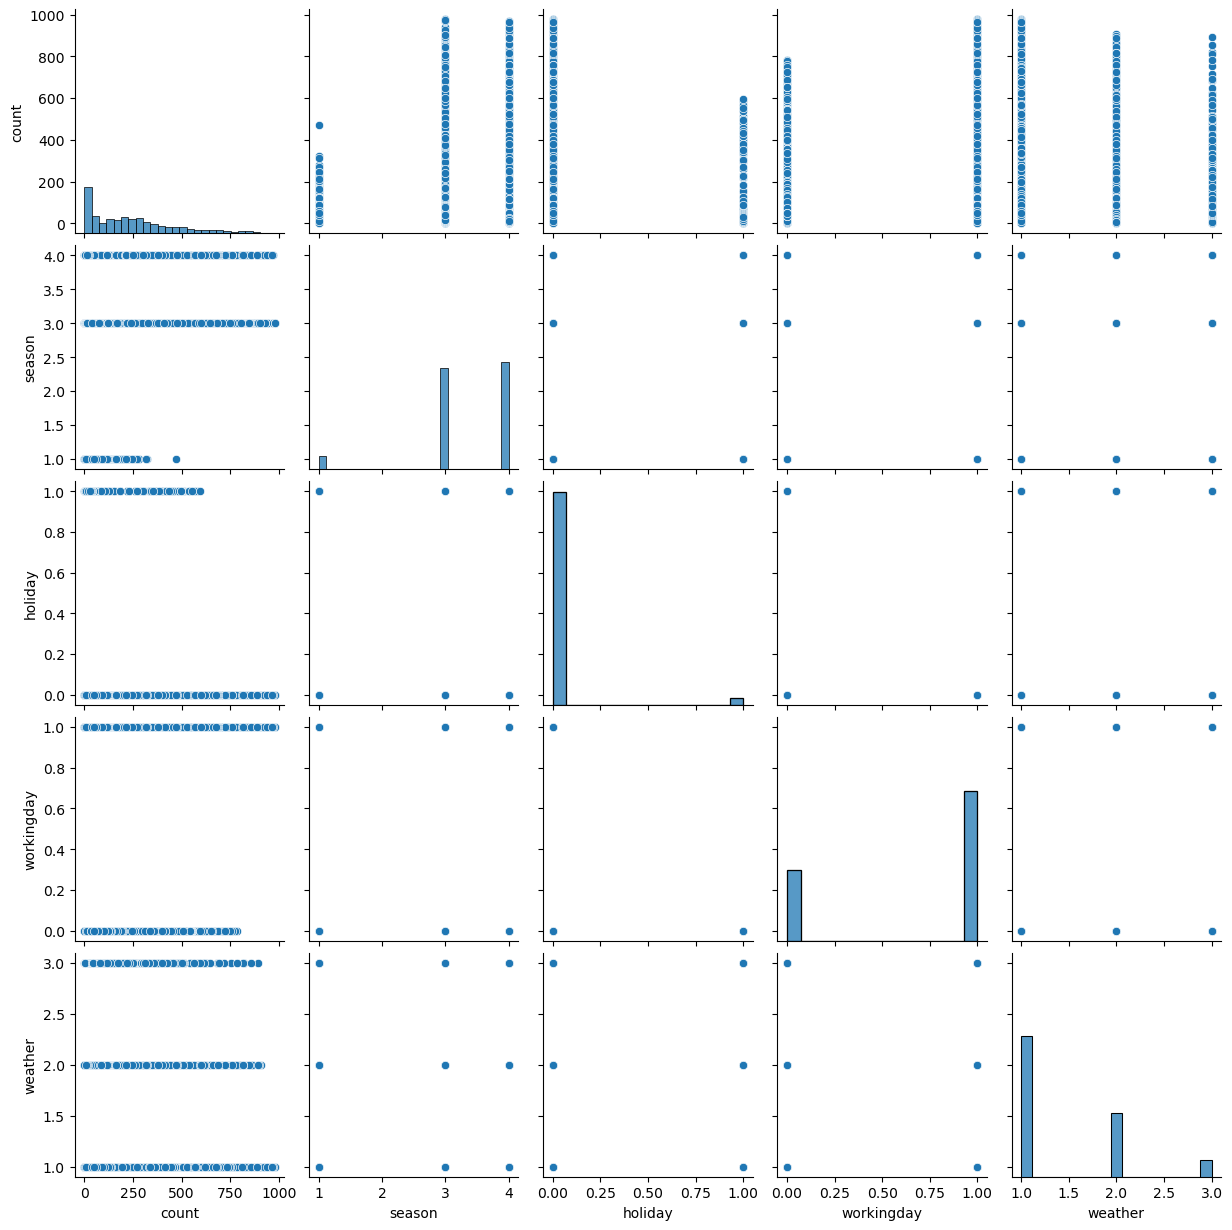

In [109]:
# seaborn 함수를 sns로 사용하여 pairplot 그리기 (Test로 5개의 변수만 실행)
sns.pairplot(YX_test.iloc[:,:5])
plt.show()

## 회귀분석으로 종속변수와 독립변수 관계 정량적으로 추정하기

In [110]:
# 모든 X_train 데이터의 값들의 통계량을 확인하기
X_train.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
season,"13,128.00",2.20,1.05,1.00,1.00,2.00,3.00,4.00
holiday,"13,128.00",0.03,0.17,0.00,0.00,0.00,0.00,1.00
workingday,"13,128.00",0.68,0.46,0.00,0.00,1.00,1.00,1.00
weather,"13,128.00",1.43,0.66,1.00,1.00,1.00,2.00,4.00
temp,"13,128.00",19.66,7.87,0.82,13.12,19.68,26.24,40.18
...,...,...,...,...,...,...,...,...
count_lag1,"13,128.00",166.20,160.76,1.00,33.00,123.00,244.00,957.00
count_lag2,"13,128.00",166.18,160.77,1.00,33.00,123.00,244.00,957.00
Quater_Dummy_2,"13,128.00",0.33,0.47,0.00,0.00,0.00,1.00,1.00
Quater_Dummy_3,"13,128.00",0.17,0.37,0.00,0.00,0.00,0.00,1.00


In [111]:
# 모든 X_train 데이터의 값들이 숫자로 반영되었는지 확인하기
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13128 entries, 2011-01-01 00:00:00 to 2012-06-30 23:00:00
Freq: h
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          13128 non-null  int64  
 1   holiday         13128 non-null  int64  
 2   workingday      13128 non-null  int64  
 3   weather         13128 non-null  int64  
 4   temp            13128 non-null  float64
 5   atemp           13128 non-null  float64
 6   humidity        13128 non-null  int64  
 7   windspeed       13128 non-null  float64
 8   count_trend     13128 non-null  float64
 9   count_seasonal  13128 non-null  float64
 10  count_Day       13128 non-null  float64
 11  count_Week      13128 non-null  float64
 12  count_diff      13128 non-null  float64
 13  Year            13128 non-null  int32  
 14  Quater_ver2     13128 non-null  int32  
 15  Month           13128 non-null  int32  
 16  Day             13128 non-null  i

In [112]:
# 회귀분석 실행하고 model 변수에 저장하기
# model 변수의 결과를 요약 출력하기
model_lr = sm.OLS(Y_train, X_train).fit()
model_lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.362e+08
Date:                Sun, 21 Sep 2025   Prob (F-statistic):               0.00
Time:                        23:54:34   Log-Likelihood:                 1906.2
No. Observations:               13128   AIC:                            -3764.
Df Residuals:                   13104   BIC:                            -3585.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
season            -0.0005      0.004     -0.129      0.897      -0.009       0.008
holiday            0.0083      0.014      0.612      0.540      -0.018       0.035
workingday         0.0079      0.007      1.184      0.236      -0.005       0.021
weather            0.0042      0.003      1.232      0.218      -0.003       0.011
temp               0.0022      0.002      1.075      0.282      -0.002       0.006
atemp             -0.0025      0.002     -1.347      0.178      -0.006       0.001
humidity          -0.0001      0.000     -0.845      0.398      -0.000       0.000
windspeed          0.0003      0.000      1.062      0.288      -0.000       0.001
count_trend     9.161e-05   8.57e-05      1.069      0.285   -7.64e-05       0.000
count_seasonal  1.984e-05   2.56e-05      0.775      0.438   -3.03e-05       7e-05
count_Day       4.177e-05   8.36e-05      0.500      0.617      -0.000       0.000
count_Week     -4.345e-05   9.61e-05     -0.452      0.651      -0.000       0.000
count_diff         1.0000    2.9e-05   3.45e+04      0.000       1.000       1.000
Year           -1.547e-05   7.97e-06     -1.939      0.052   -3.11e-05    1.66e-07
Quater_ver2        0.0004      0.002      0.180      0.857      -0.004       0.005
Month              0.0026      0.002      1.051      0.293      -0.002       0.007
Day                0.0004      0.000      1.728      0.084   -4.91e-05       0.001
Hour               0.0006      0.000      1.538      0.124      -0.000       0.001
DayofWeek          0.0003      0.002      0.224      0.823      -0.003       0.003
count_lag1         1.0000    2.7e-05    3.7e+04      0.000       1.000       1.000
count_lag2     -1.926e-05   2.59e-05     -0.744      0.457      -7e-05    3.15e-05
Quater_Dummy_2    -0.0010      0.009     -0.115      0.909      -0.019       0.017
Quater_Dummy_3    -0.0037      0.017     -0.220      0.826      -0.037       0.030
Quater_Dummy_4    -0.0132      0.026     -0.512      0.609      -0.064       0.037
==============================================================================
Omnibus:                    54426.083   Durbin-Watson:                   1.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      93552024983.816
Skew:                        -114.255   Prob(JB):                         0.00
Kurtosis:                   13078.751   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 학습된 회귀분석으로 과거/현재/미래 예측하기

In [113]:
# 학습된 모델을 사용하여 X_train 값 예측하기
model_lr.predict(X_train)

DateTime
2011-01-01 00:00:00    39.95
2011-01-01 01:00:00    39.96
2011-01-01 02:00:00    31.96
2011-01-01 03:00:00    12.96
2011-01-01 04:00:00     0.96
                       ...  
2012-06-30 19:00:00   374.00
2012-06-30 20:00:00   292.00
2012-06-30 21:00:00   213.00
2012-06-30 22:00:00   172.00
2012-06-30 23:00:00   152.00
Freq: h, Length: 13128, dtype: float64

In [114]:
# 학습된 모델을 사용하여 X_train 값 예측하고 DataFrame 형식으로 바꾸며 컬럼 이름은 'Pred'로 출력하기
pd.DataFrame(model_lr.predict(X_train), columns=['Pred'])

,Pred
DateTime,
2011-01-01 00:00:00,39.95
2011-01-01 01:00:00,39.96
2011-01-01 02:00:00,31.96
2011-01-01 03:00:00,12.96
2011-01-01 04:00:00,0.96
...,...
2012-06-30 19:00:00,374.00
2012-06-30 20:00:00,292.00
2012-06-30 21:00:00,213.00


In [115]:
# 학습된 모델을 사용하여 X_train 및 X_test 값 예측하고 변수로 저장
Y_trpred = pd.DataFrame(model_lr.predict(X_train), columns=['Pred'])
Y_tepred = pd.DataFrame(model_lr.predict(X_test), columns=['Pred'])

In [116]:
# 실제 Y_train과 예측치인 Y_trpred 붙여서 비교하기
pd.concat([Y_train, Y_trpred], axis=1)

,count,Pred
DateTime,,
2011-01-01 00:00:00,16,39.95
2011-01-01 01:00:00,40,39.96
2011-01-01 02:00:00,32,31.96
2011-01-01 03:00:00,13,12.96
2011-01-01 04:00:00,1,0.96
...,...,...
2012-06-30 19:00:00,374,374.00
2012-06-30 20:00:00,292,292.00
2012-06-30 21:00:00,213,213.00


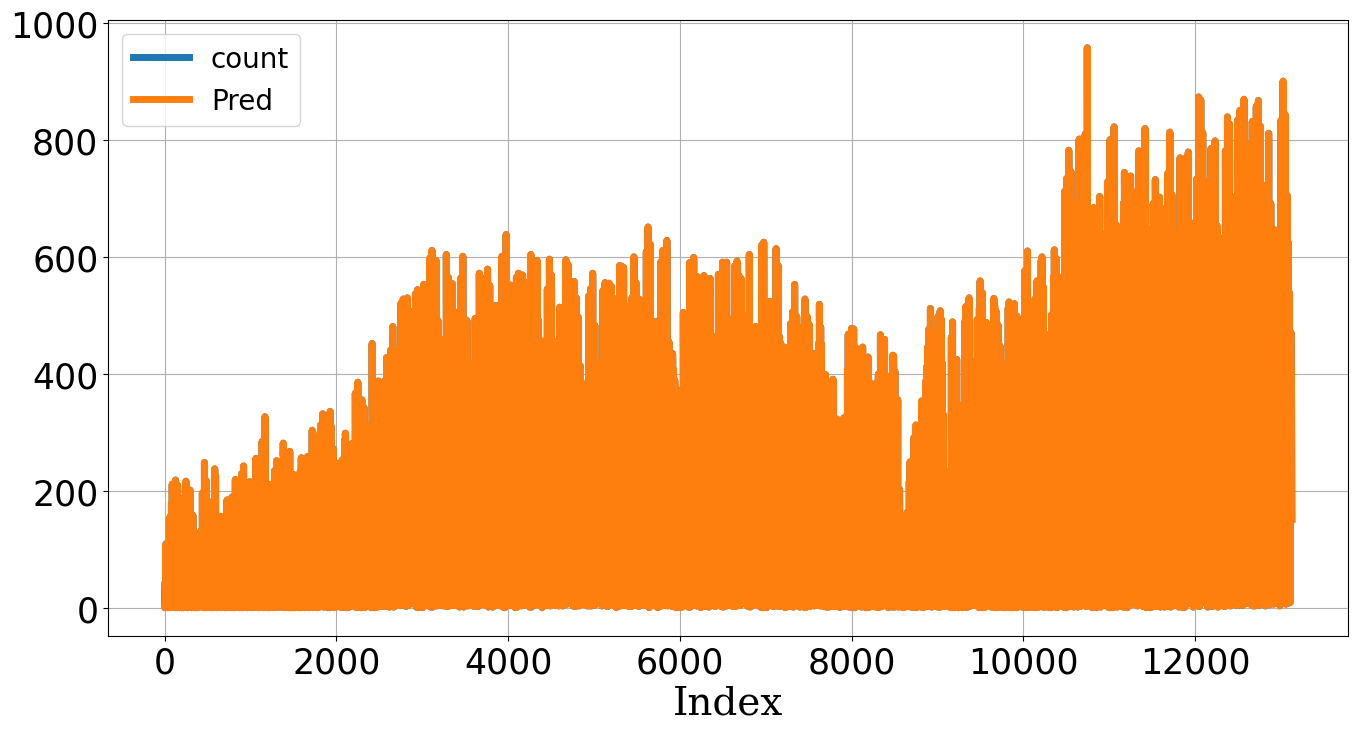

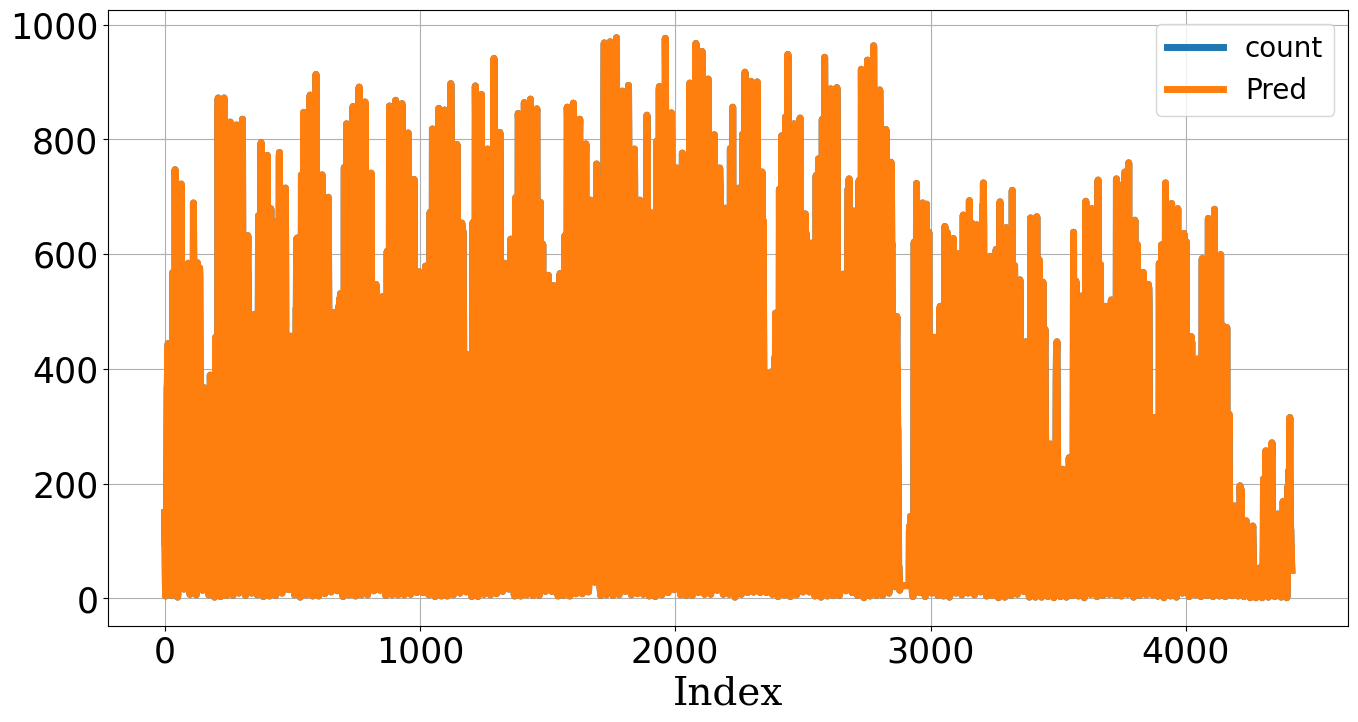

In [117]:
# 실제 Y와 예측치 시각화
def plot_prediction(Y_true_pred):
    plt.figure(figsize=(16, 8))
    plt.plot(Y_true_pred, linewidth=5, label=Y_true_pred.columns)
    plt.xticks(fontsize=25, rotation=0)
    plt.yticks(fontsize=25)
    plt.xlabel('Index', fontname='serif', fontsize=28)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()
    
plot_prediction(pd.concat([Y_train, Y_trpred], axis=1).reset_index().iloc[:,1:])
plot_prediction(pd.concat([Y_test, Y_tepred], axis=1).reset_index().iloc[:,1:])

## **코드 정리:** 전처리 + 모델링

In [118]:
# 실제 Y와 예측치 시각화
def plot_prediction(Y_true_pred):
    plt.figure(figsize=(16, 8))
    plt.plot(Y_true_pred, linewidth=5, label=Y_true_pred.columns)
    plt.xticks(fontsize=25, rotation=0)
    plt.yticks(fontsize=25)
    plt.xlabel('Index', fontname='serif', fontsize=28)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()

Train_size: (13128, 28) Test_size: (4416, 28)
X_train: (13128, 24) Y_train: (13128, 1)
X_test: (4416, 24) Y_test: (4416, 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.362e+08
Date:                Sun, 21 Sep 2025   Prob (F-statistic):               0.00
Time:                        23:54:34   Log-Likelihood:                 1906.2
No. Observations:               13128   AIC:                            -3764.
Df Residuals:                   13104   BIC:                            -3585.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
season            -0.0005      0.004     -0.129      0.897      -0.009       0.008
holiday            0.0083      0.014      0.612      0.540      -0.018       0.035
workingday         0.0079      0.007      1.184      0.236      -0.005       0.021
weather            0.0042      0.003      1.232      0.218      -0.003       0.011
temp               0.0022      0.002      1.075      0.282      -0.002       0.006
atemp             -0.0025      0.002     -1.347      0.178      -0.006       0.001
humidity          -0.0001      0.000     -0.845      0.398      -0.000       0.000
windspeed          0.0003      0.000      1.062      0.288      -0.000       0.001
count_trend     9.161e-05   8.57e-05      1.069      0.285   -7.64e-05       0.000
count_seasonal  1.984e-05   2.56e-05      0.775      0.438   -3.03e-05       7e-05
count_Day       4.177e-05   8.36e-05      0.500      0.617      -0.000       0.000
count_Week     -4.345e-05   9.61e-05     -0.452      0.651      -0.000       0.000
count_diff         1.0000    2.9e-05   3.45e+04      0.000       1.000       1.000
Year           -1.547e-05   7.97e-06     -1.939      0.052   -3.11e-05    1.66e-07
Quater_ver2        0.0004      0.002      0.180      0.857      -0.004       0.005
Month              0.0026      0.002      1.051      0.293      -0.002       0.007
Day                0.0004      0.000      1.728      0.084   -4.91e-05       0.001
Hour               0.0006      0.000      1.538      0.124      -0.000       0.001
DayofWeek          0.0003      0.002      0.224      0.823      -0.003       0.003
count_lag1         1.0000    2.7e-05    3.7e+04      0.000       1.000       1.000
count_lag2     -1.926e-05   2.59e-05     -0.744      0.457      -7e-05    3.15e-05
Quater_Dummy_2    -0.0010      0.009     -0.115      0.909      -0.019       0.017
Quater_Dummy_3    -0.0037      0.017     -0.220      0.826      -0.037       0.030
Quater_Dummy_4    -0.0132      0.026     -0.512      0.609      -0.064       0.037
==============================================================================
Omnibus:                    54426.083   Durbin-Watson:                   1.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      93552024983.816
Skew:                        -114.255   Prob(JB):                         0.00
Kurtosis:                   13078.751   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

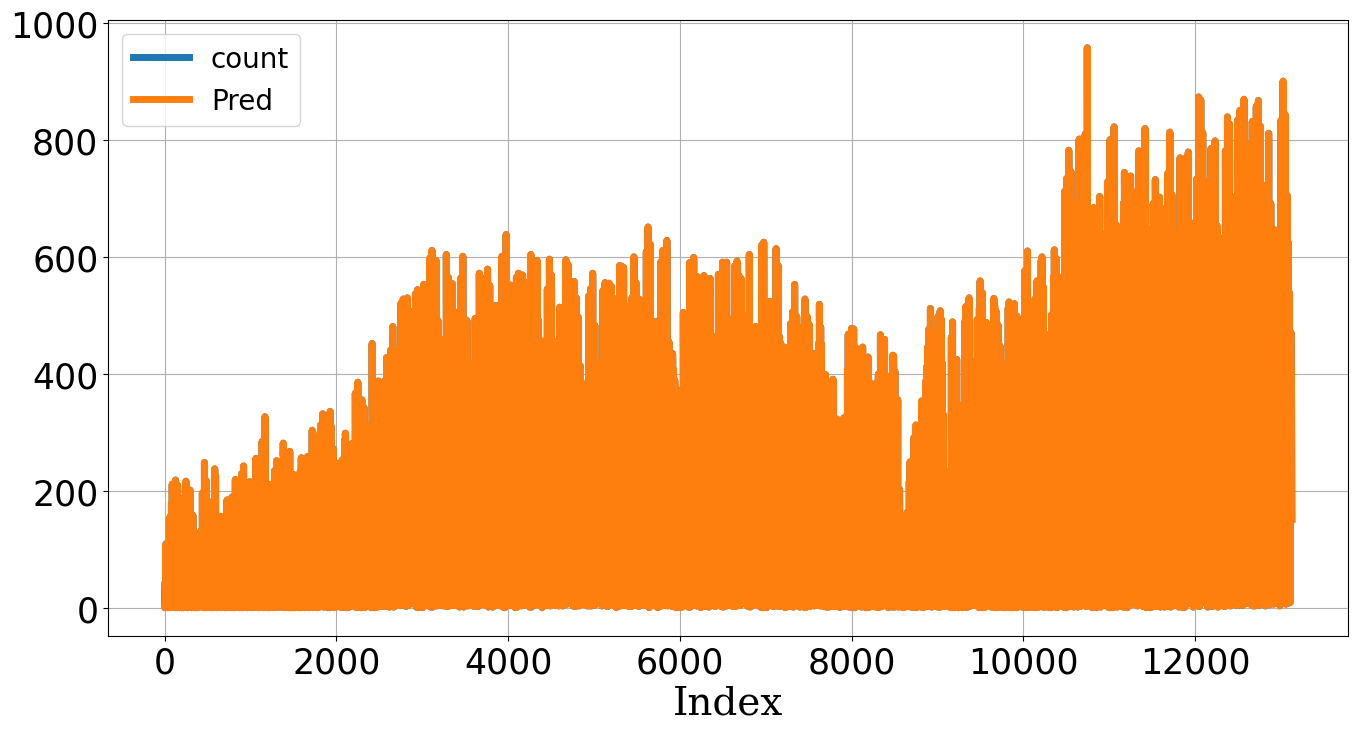

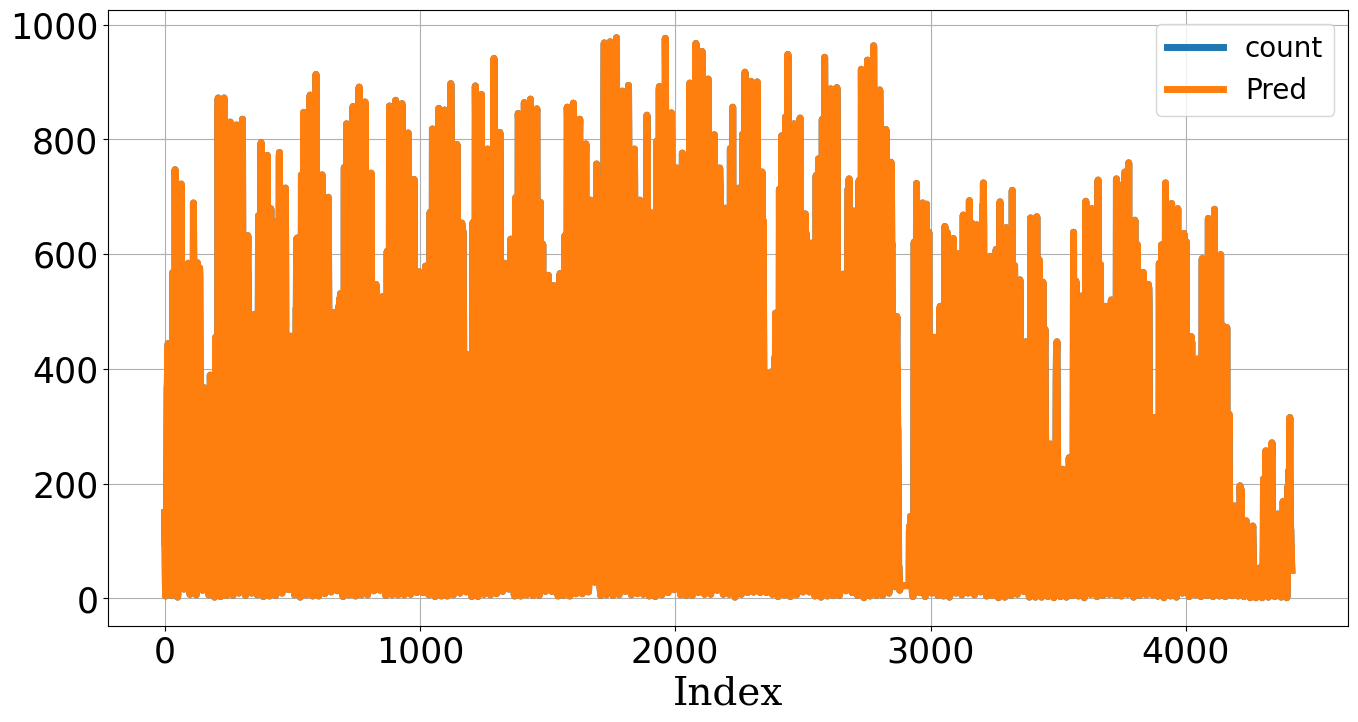

In [119]:
# 데이터 로딩
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df_all = pd.read_csv(location)

# 데이터 전처리
df_nfe = non_feature_engineering(df_all)
df_fe = feature_engineering(df_all)

# 데이터 분리
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
X_colname = [x for x in df_fe.columns if x not in Y_colname+X_remove]
X_train, X_test, Y_train, Y_test = datasplit_ts(df_fe, Y_colname, X_colname, '2012-07-01')

# Linear Regression
model_lr = sm.OLS(Y_train, X_train).fit()
display(model_lr.summary())

Y_trpred = pd.DataFrame(model_lr.predict(X_train), columns=['Pred'])
Y_tepred = pd.DataFrame(model_lr.predict(X_test), columns=['Pred'])
plot_prediction(pd.concat([Y_train, Y_trpred], axis=1).reset_index().iloc[:,1:])
plot_prediction(pd.concat([Y_test, Y_tepred], axis=1).reset_index().iloc[:,1:])

# **Evaluation:** 분석 성능 확인/평가하기 

## 회귀문제 검증지표

**1) R-squared(R^2):** 추정된 `(선형)모형이 주어진 데이터에 잘 적합된 정도`, 계량경제학에서는 `모델에 의해 설명되는 데이터 분산의 정도(퍼센트)`, $(- \infty, 1]$  
$$R^2 = \dfrac{ESS}{TSS} = \dfrac{\sum_{i=1}^{n} (\hat{y}_i - \bar{y})^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \dfrac{RSS}{TSS} = 1 - \dfrac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

```python
import sklearn
sklearn.metrics.r2_score
```

**2) Mean Absolute Error(MAE):** 각 `데이터의 단위에 덜 민감한` 성능지표, $[0, +\infty)$
$$MAE = \dfrac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

```python
import sklearn
sklearn.metrics.mean_absolute_error
```

**3) Mean Squared Error(MSE):** 가장 많이 사용되며 `큰 오차에 패널티(Penalty)를 높게 부여`하는 성능지표, $[0, +\infty)$  
$$MSE = \dfrac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

```python
import sklearn
sklearn.metrics.mean_squared_error
```

**4) Mean Squared Logarithmic Error(MSLE):** MSE와 유사하나 `큰값/작은값에 적은/많은 비중(Weignt)`을 부여하는 성능지표, `Exponential 추세가 있는 데이터에 많이 활용`, $[0, +\infty)$  
$$MSLE = \dfrac{1}{n} \sum_{i=1}^{n} (\log(1+y_i) - \log(1+\hat{y}_i))^2$$

```python
import sklearn
sklearn.metrics.mean_squared_log_error
```

**5) Median Absolute Error(MedAE):** `이상치에 덜 민감한(Robust)` 성능지표, $[0, +\infty)$
$$MedAE = \text{median}(|y_1 - \hat{y}_1|, |y_2 - \hat{y}_2|, \dots , |y_n - \hat{y}_n|)$$

```python
import sklearn
sklearn.metrics.median_absolute_error
```

**6) Root Mean Squared Error(RMSE):** `MSE를 보정`한 성능지표, $[0, +\infty)$  
$$RMSE = \sqrt{MSE}$$

**7) Mean Absolute Percentage Error(MAPE):** MAE와 유사하나 `퍼센트 형식`으로 표시한 성능지표, $[0, +\infty)$
$$MAPE = \dfrac{100}{n} \sum_{i=1}^{n} \dfrac{|y_i - \hat{y}_i|}{y_i}$$

**8) Mean Percentage Error(MPE):** MAPE와 유사하나 `오차의 부호(+/-)까지 고려`한 성능지표, $(-\infty, +\infty)$
$$MPE = \dfrac{100}{n} \sum_{i=1}^{n} \dfrac{y_i - \hat{y}_i}{y_i}$$

---

- **Summary:**

| Acroynm | Full Name | Residual Operation? | Robust To Outliers? |
|:---------:|:--------------------------------:|---------------------|---------------------|
| **MAE** | Mean Absolute Error | Absolute Value | Yes |
| **MSE** | Mean Squared Error | Square | No |
| **MedAE** | Median Absolute Error | Absolute Value | Yes |
| **RMSE** | Root Mean Squared Error | Square | No |
| **MAPE** | Mean Absolute Percentage Error | Absolute Value | Yes |
| **MPE** | Mean Percentage Error | N/A | Yes |


In [120]:
# MSE 값을 계산하여 하나의 숫자로 Train 데이터에서 알고리즘의 예측 성능을 표현하기
import numpy as np

np.mean((Y_trpred.values - Y_train.values)**2)

0.04379330871665982

In [121]:
# Test 데이터에서도 MSE 출력하기
np.mean((Y_tepred.values - Y_test.values)**2)

0.0001466943510625224

In [122]:
# MSE 정리하기
Y_train_score = np.mean((Y_trpred.values - Y_train.values)**2)
Y_test_score = np.mean((Y_tepred.values - Y_test.values)**2)
MSE = pd.DataFrame([Y_train_score, Y_test_score], columns=['MSE'], index=['Train', 'Test'])
MSE

,MSE
Train,0.04
Test,0.00


In [123]:
# 함수를 사용하여 MSE 출력하기
mean_squared_error(Y_train, Y_trpred)

0.04379330871665982

In [124]:
# 함수를 사용하여 MAE 출력하기
mean_absolute_error(Y_train, Y_trpred)

0.008965784931663957

In [125]:
# 함수를 사용하여 MAPE 출력하기
mean_absolute_percentage_error(Y_train, Y_trpred)

0.0005965808753694205

In [126]:
# MSE, MAE, MAPE 정리
MAE = mean_absolute_error(Y_train, Y_trpred)
MSE = mean_squared_error(Y_train, Y_trpred)
MAPE = mean_absolute_percentage_error(Y_train, Y_trpred)
pd.DataFrame([MAE, MSE, MAPE], index=['MAE', 'MSE', 'MAPE'], columns=['Score']).T

,MAE,MSE,MAPE
Score,0.01,0.04,0.00


In [127]:
# 마찬가지로 Test 데이터의 성능 확인하기
MAE = mean_absolute_error(Y_test, Y_tepred)
MSE = mean_squared_error(Y_test, Y_tepred)
MAPE = mean_absolute_percentage_error(Y_test, Y_tepred)
pd.DataFrame([MAE, MSE, MAPE], index=['MAE', 'MSE', 'MAPE'], columns=['Score']).T

,MAE,MSE,MAPE
Score,0.01,0.00,0.00


## **코드 정리:** 전처리 + 모델링 + 검증

In [128]:
# 검증 함수화
def evaluation_reg(Y_real, Y_pred):
    MAE = mean_absolute_error(Y_real, Y_pred)
    MSE = mean_squared_error(Y_real, Y_pred)
    MAPE = mean_absolute_percentage_error(Y_real, Y_pred)
    Score = pd.DataFrame([MAE, MSE, MAPE], index=['MAE', 'MSE', 'MAPE'], columns=['Score']).T
    
    return Score

# Train & Test 모두의 검증 함수화
def evaluation_reg_trte(Y_real_tr, Y_pred_tr, Y_real_te, Y_pred_te):
    Score_tr = evaluation_reg(Y_real_tr, Y_pred_tr)
    Score_te = evaluation_reg(Y_real_te, Y_pred_te)
    Score_trte = pd.concat([Score_tr, Score_te], axis=0)
    Score_trte.index = ['Train', 'Test']

    return Score_trte

Train_size: (13128, 28) Test_size: (4416, 28)
X_train: (13128, 24) Y_train: (13128, 1)
X_test: (4416, 24) Y_test: (4416, 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.362e+08
Date:                Sun, 21 Sep 2025   Prob (F-statistic):               0.00
Time:                        23:54:35   Log-Likelihood:                 1906.2
No. Observations:               13128   AIC:                            -3764.
Df Residuals:                   13104   BIC:                            -3585.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
season            -0.0005      0.004     -0.129      0.897      -0.009       0.008
holiday            0.0083      0.014      0.612      0.540      -0.018       0.035
workingday         0.0079      0.007      1.184      0.236      -0.005       0.021
weather            0.0042      0.003      1.232      0.218      -0.003       0.011
temp               0.0022      0.002      1.075      0.282      -0.002       0.006
atemp             -0.0025      0.002     -1.347      0.178      -0.006       0.001
humidity          -0.0001      0.000     -0.845      0.398      -0.000       0.000
windspeed          0.0003      0.000      1.062      0.288      -0.000       0.001
count_trend     9.161e-05   8.57e-05      1.069      0.285   -7.64e-05       0.000
count_seasonal  1.984e-05   2.56e-05      0.775      0.438   -3.03e-05       7e-05
count_Day       4.177e-05   8.36e-05      0.500      0.617      -0.000       0.000
count_Week     -4.345e-05   9.61e-05     -0.452      0.651      -0.000       0.000
count_diff         1.0000    2.9e-05   3.45e+04      0.000       1.000       1.000
Year           -1.547e-05   7.97e-06     -1.939      0.052   -3.11e-05    1.66e-07
Quater_ver2        0.0004      0.002      0.180      0.857      -0.004       0.005
Month              0.0026      0.002      1.051      0.293      -0.002       0.007
Day                0.0004      0.000      1.728      0.084   -4.91e-05       0.001
Hour               0.0006      0.000      1.538      0.124      -0.000       0.001
DayofWeek          0.0003      0.002      0.224      0.823      -0.003       0.003
count_lag1         1.0000    2.7e-05    3.7e+04      0.000       1.000       1.000
count_lag2     -1.926e-05   2.59e-05     -0.744      0.457      -7e-05    3.15e-05
Quater_Dummy_2    -0.0010      0.009     -0.115      0.909      -0.019       0.017
Quater_Dummy_3    -0.0037      0.017     -0.220      0.826      -0.037       0.030
Quater_Dummy_4    -0.0132      0.026     -0.512      0.609      -0.064       0.037
==============================================================================
Omnibus:                    54426.083   Durbin-Watson:                   1.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      93552024983.816
Skew:                        -114.255   Prob(JB):                         0.00
Kurtosis:                   13078.751   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

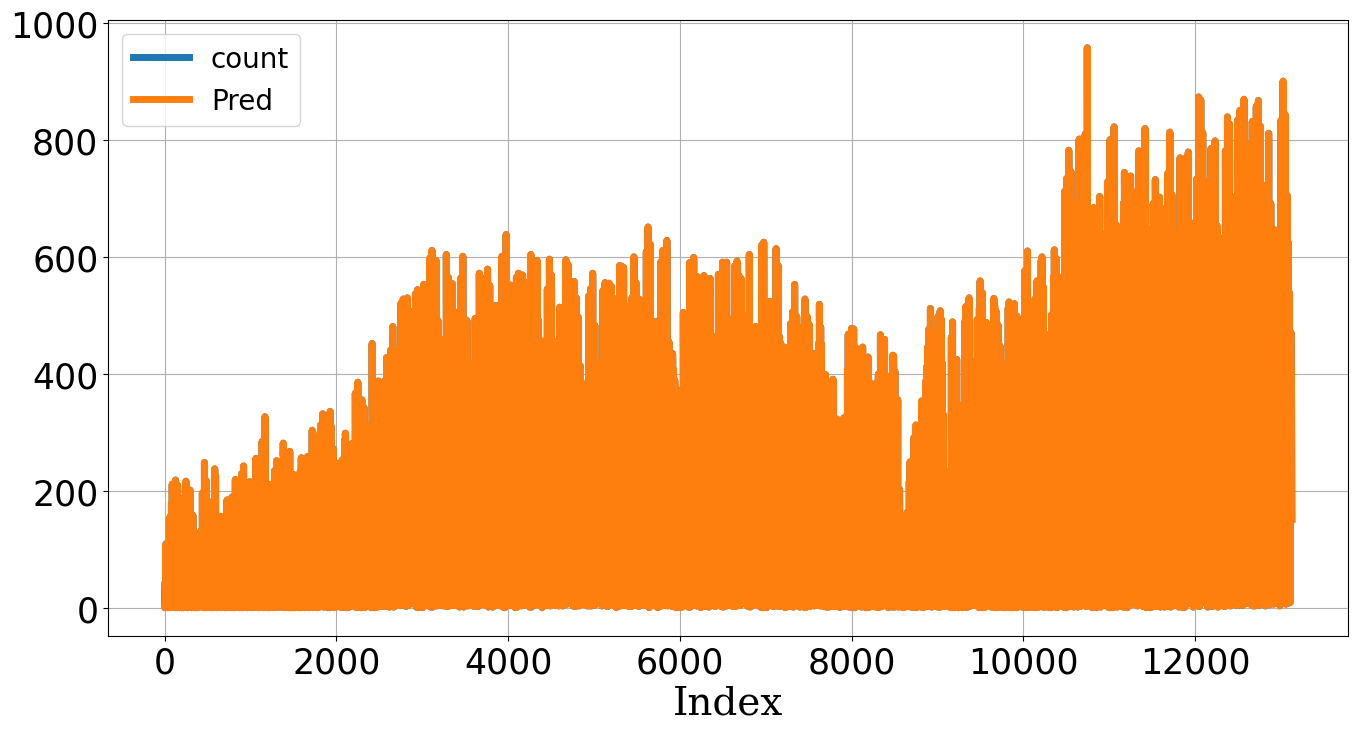

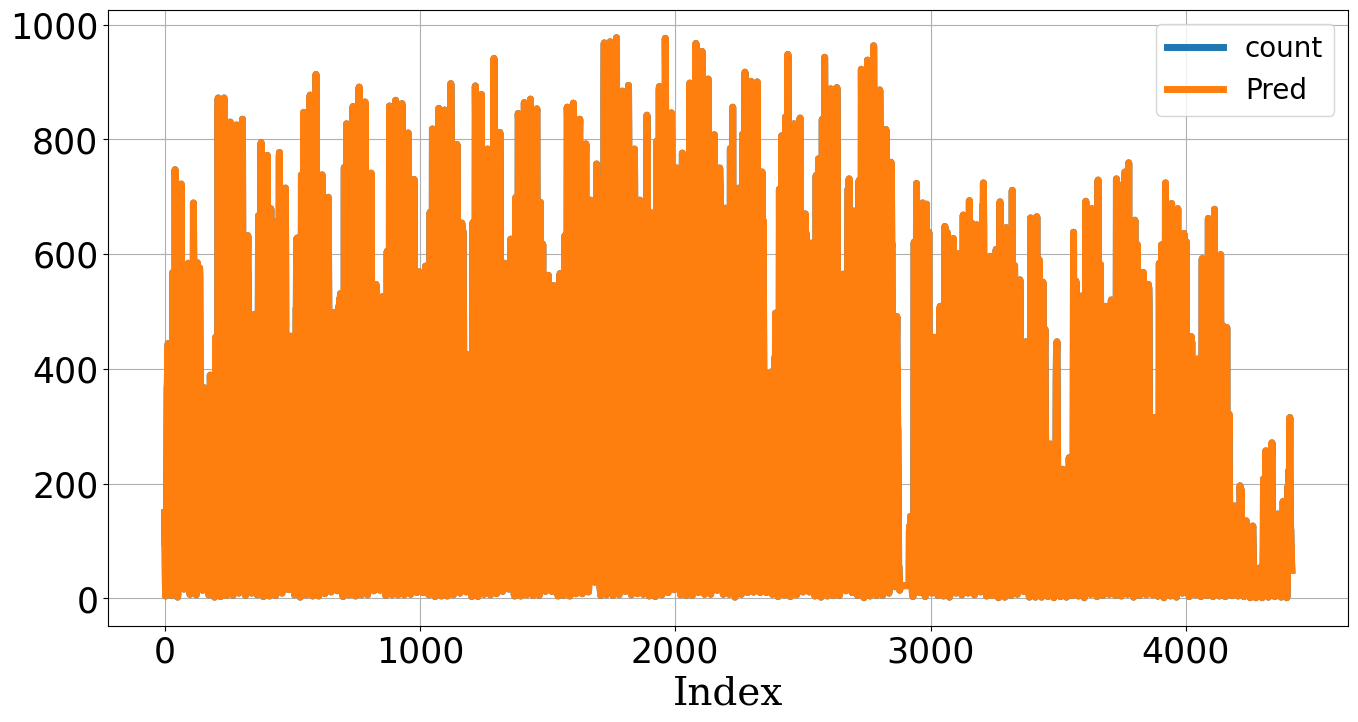

,MAE,MSE,MAPE
Train,0.01,0.04,0.00
Test,0.01,0.00,0.00


In [129]:
# 데이터 로딩
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df_all = pd.read_csv(location)

# 데이터 전처리
df_nfe = non_feature_engineering(df_all)
df_fe = feature_engineering(df_all)

# 데이터 분리
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
X_colname = [x for x in df_fe.columns if x not in Y_colname+X_remove]
X_train, X_test, Y_train, Y_test = datasplit_ts(df_fe, Y_colname, X_colname, '2012-07-01')

# Linear Regression
model_lr = sm.OLS(Y_train, X_train).fit()
display(model_lr.summary())

Y_trpred = pd.DataFrame(model_lr.predict(X_train), columns=['Pred'])
Y_tepred = pd.DataFrame(model_lr.predict(X_test), columns=['Pred'])
plot_prediction(pd.concat([Y_train, Y_trpred], axis=1).reset_index().iloc[:,1:])
plot_prediction(pd.concat([Y_test, Y_tepred], axis=1).reset_index().iloc[:,1:])

# 분석 검증
Score = evaluation_reg_trte(Y_train, Y_trpred, Y_test, Y_tepred)
Score

# **Error Analysis:** 분석 성능/종료 판단하기

**0) 검증지표 vs 잔차진단:** Y수치 비교가 가능한 `예측문제`에서 Y라벨이 있는 `지도학습`에 적용 가능

<br>
<center><img src='Image/Advanced/Evaluation_Residual.png' width='800'></center>

---

**1) 잔차진단의 2가지 목적:**

> **"`예측 성능`도 중요하지만(추정성능), 추정/분석 이후 `데이터의 패턴이 모델링에 잘 반영되었는지`(잔차진단) 평가하는 것도 중요"**
>
> (1) 추가할만한 `데이터 전처리` 또는 다른 `모델링의 대안` 파악
>> - 잔차에 `남아있는 패턴`을 전처리 단계에서 `추가 반영` 가능
>> - 잔차의 남은 패턴으로 `다른 분석 알고리즘 고려` 가능
>
> (2) 분석 시작은 여러분들이 시작했지만, `분석 종료`는 `잔차 진단`이 알려줌
>> - 잔차의 남은 패턴이 없다는 것은 `모델링이 데이터의 패턴을 최대한 반영` 의미
>> - 모델링으로 더이상 할 수 있는 것들이 없으니 `분석을 마무리` 해도 됨을 의미

---

**2) 잔차진단의 목표: 잔차가 `백색잡음`과 얼마나 유사한지 측정**

- 모델링에 데이터의 패턴이 잘 반영 되었다면, 추정 후의 `잔차`에는 아무 패턴도 없어야 함
- `잔차`에 아무런 패턴도 남아있지 않은 경우 `백색잡음`의 형태로 분포
- `잔차 분석/진단`을 통해 잔차가 `백색잡음(White Noise)`라면 역으로 `모델링`에서 데이터의 패턴을 잘 반영하여 성능이 좋음을 의미

---

**3) 백색잡음:** 잔차가 백색잡음이 아니라면 `모델링으로 개선의 여지가 있음`을 의미  

<center><img src='Image/Advanced/White_Noise.png' width='450'></center>
    
> **(1) 잔차들은 `정규분포`이고, (unbiased) `평균 0이고 일정한 분산`을 가져야 함:** 
>
> $$
\begin{align*}
\{\epsilon_t : t = \dots, -1, 0, 1, \dots\} & \sim N(0,\sigma^2_{\epsilon_t}) \\
\text{where  } \epsilon_t & \sim \text{i.i.d(independent and identically distributed)} \\
\epsilon_t &= Y_t - \hat{Y_t} \\
E(\epsilon_t) &= 0 \\
Var(\epsilon_t) &= \sigma^2_{\epsilon_t} \\
Cov(\epsilon_s, \epsilon_k) &= 0 \text{ for different times!(s $\ne$ k)}
\end{align*}
$$
>
> **(2) 잔차들이 시간의 흐름에 따라 `상관성이 없어야` 함:** `자기상관함수(Autocorrelation Function, ACF)=0` 확인
> - 공분산(Covariance): 
>
> $$Cov(Y_s, Y_k) = E[(Y_s-E(Y_s))(Y_k-E(Y_k))] = \gamma_{s,k}$$
>
> - 자기상관함수(Autocorrelation Function): 
>
> $$Corr(Y_s, Y_k) = \dfrac{Cov(Y_s, Y_k)}{\sqrt{Var(Y_s)Var(Y_k)}} = \dfrac{\gamma_{s,k}}{\sqrt{\gamma_s \gamma_k}}$$
>
> - 편자기상관함수(Partial Autocorrelation Function): $s$와 $k$사이의 `상관성을 제거한 자기상관함수`
>
> $$Corr[(Y_s-\hat{Y}_s, Y_{s-t}-\hat{Y}_{s-t})] \quad \text{for } 1<t<k$$

---
            
**4) 자기상관 테스트:**

- **예시:**

> - Apply a portmanteau test to check the hypothesis that residuals are uncorrelated.
> 
> <center><img src='Image/Advanced/Portmanteau_Test.jpg' width='600'></center>
>
> - Plot the Autocorrelation function (ACF) and evaluate that at least 95% of the spikes are on the interval.
>
> <center><img src='Image/Advanced/Residual_Plot.png' width='700'></center> 

- 정규분포 테스트(Normality Test)
- 등분산성 테스트(Homoscedasticity Test)
- 자기상관 테스트(Autocorrelation Test)
- <span style="color:red">정상성 테스트(Stationarity Test)</span>


In [130]:
# 잔차 추출하기
# 2차원끼리 빼기 1차원의 값으로 DataFrame 유지한 채 쉽게 연산 가능
Y_train - Y_trpred.values

,count
DateTime,
2011-01-01 00:00:00,-23.95
2011-01-01 01:00:00,0.04
2011-01-01 02:00:00,0.04
2011-01-01 03:00:00,0.04
2011-01-01 04:00:00,0.04
...,...
2012-06-30 19:00:00,-0.00
2012-06-30 20:00:00,0.00
2012-06-30 21:00:00,0.00


In [131]:
# Train & Test 모두 잔차를 추출하고 변수 저장
# 각 변수의 column 이름은 'Error'로 변경
Resid_tr = Y_train - Y_trpred.values
Resid_tr.columns = ['Error']
Resid_te = Y_test - Y_tepred.values
Resid_te.columns = ['Error']

In [132]:
# Train & Test index를 별도 변수로 저장 
Resid_tr['Index'] = Resid_tr.reset_index().index
Resid_te['Index'] = Resid_te.reset_index().index
Resid_tr

,Error,Index
DateTime,,
2011-01-01 00:00:00,-23.95,0
2011-01-01 01:00:00,0.04,1
2011-01-01 02:00:00,0.04,2
2011-01-01 03:00:00,0.04,3
2011-01-01 04:00:00,0.04,4
...,...,...
2012-06-30 19:00:00,-0.00,13123
2012-06-30 20:00:00,0.00,13124
2012-06-30 21:00:00,0.00,13125


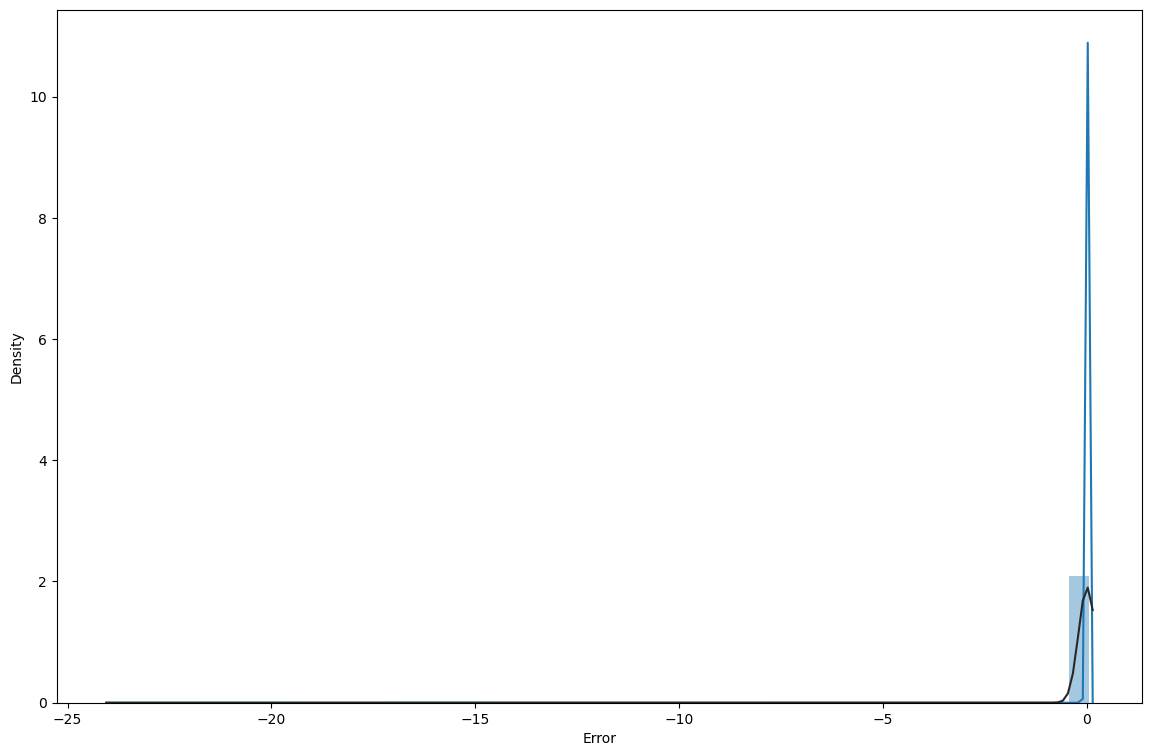

In [133]:
# 잔차의 정규분포성 확인
sns.distplot(Resid_tr.Error, norm_hist='True', fit=stats.norm)
plt.show()

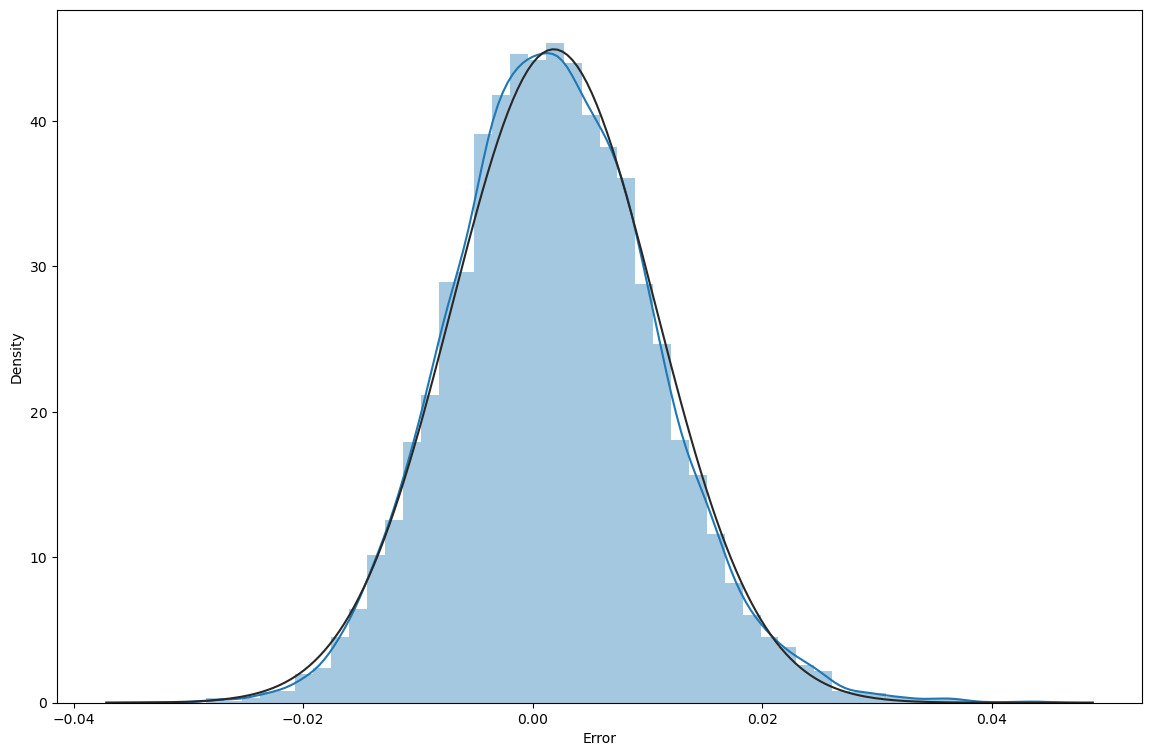

In [134]:
# 잔차의 정규본포성 확인
# 초기 예측오류 제외시
sns.distplot(Resid_tr.Error.iloc[1:], norm_hist='True', fit=stats.norm)
plt.show()

- 최신 `seaborn`에서는 `size` 파라미터 대신 `height` 파라미터 사용

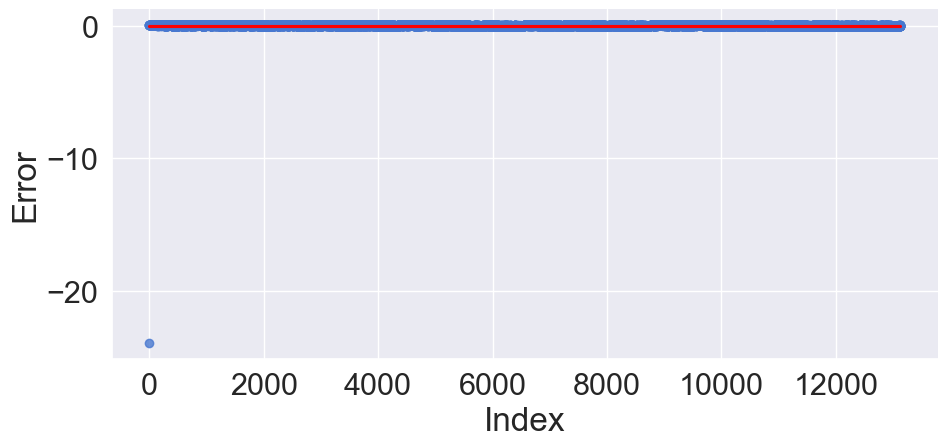

In [135]:
# 잔차의 등분산성 확인
sns.set(palette="muted", color_codes=True, font_scale=2)
sns.lmplot(data=Resid_tr, x='Index', y='Error',
           fit_reg=True, line_kws={'color': 'red'}, height=5, aspect=2, ci=99, sharey=True)
plt.show()

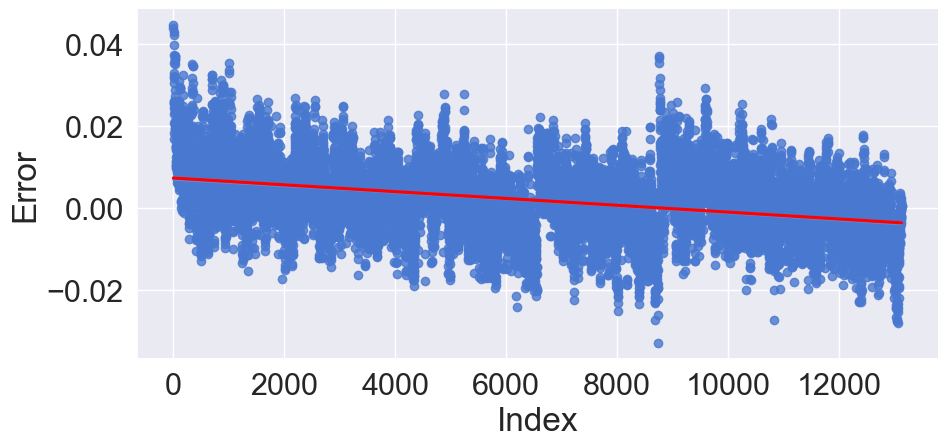

In [136]:
# 잔차의 등분산성 확인
# 초기 예측오류 제외시
sns.set(palette="muted", color_codes=True, font_scale=2)
sns.lmplot(data=Resid_tr.iloc[1:,:], x='Index', y='Error',
           fit_reg=True, line_kws={'color': 'red'}, height=5, aspect=2, ci=99, sharey=True)
plt.show()

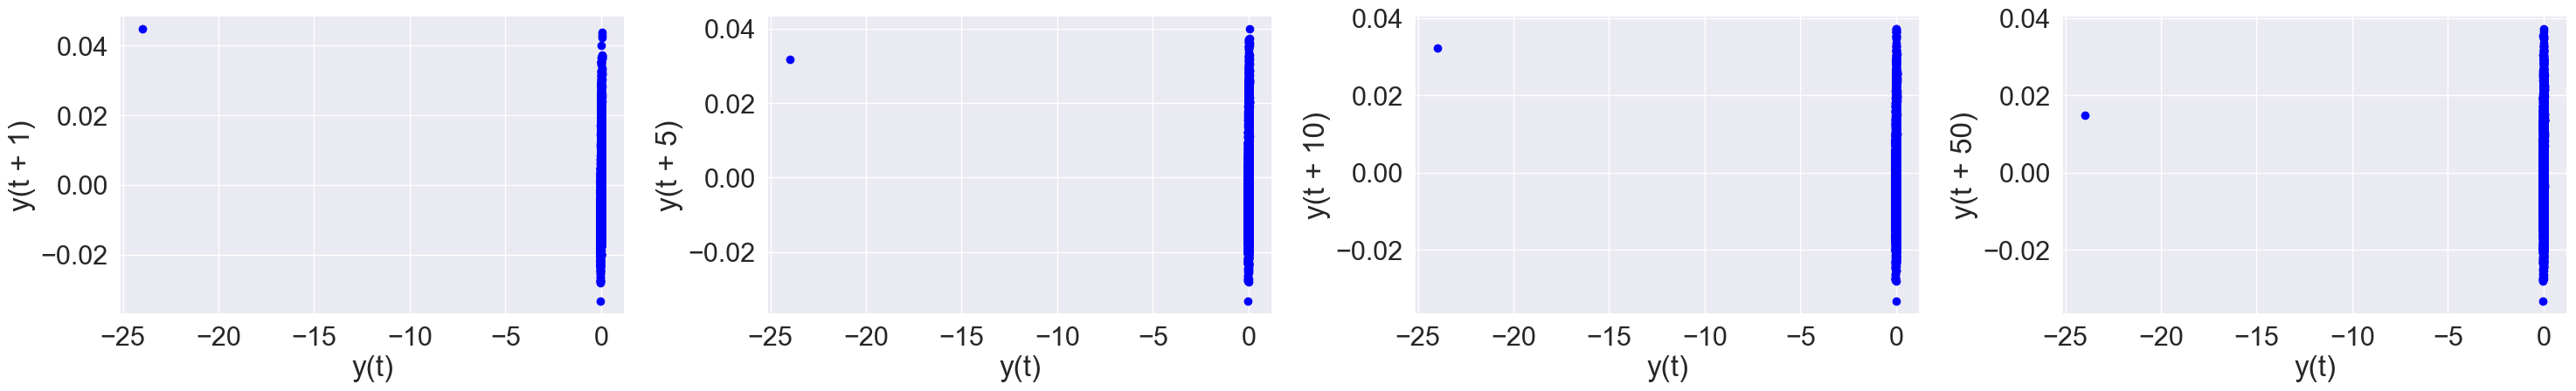

In [137]:
# 잔차의 자기상관성 확인
figure, axes = plt.subplots(1, 4, figsize=(30,5))
pd.plotting.lag_plot(Resid_tr.Error, lag=1, ax=axes[0], c='blue')
pd.plotting.lag_plot(Resid_tr.Error, lag=5, ax=axes[1], c='blue')
pd.plotting.lag_plot(Resid_tr.Error, lag=10, ax=axes[2], c='blue')
pd.plotting.lag_plot(Resid_tr.Error, lag=50, ax=axes[3], c='blue')
plt.tight_layout()
plt.show()

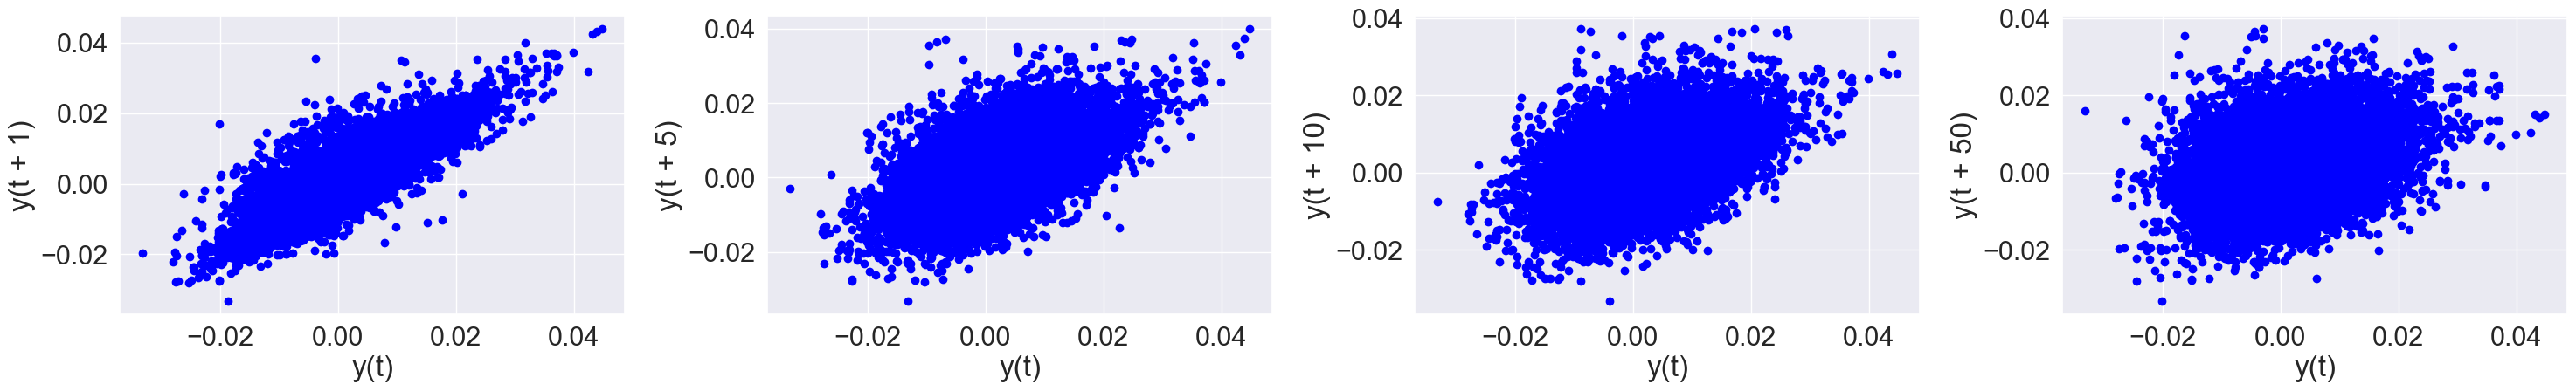

In [138]:
# 잔차의 자기상관성 확인
# 초기 예측오류 제외시
figure, axes = plt.subplots(1, 4, figsize=(30,5))
pd.plotting.lag_plot(Resid_tr.Error.iloc[1:], lag=1, ax=axes[0], c='blue')
pd.plotting.lag_plot(Resid_tr.Error.iloc[1:], lag=5, ax=axes[1], c='blue')
pd.plotting.lag_plot(Resid_tr.Error.iloc[1:], lag=10, ax=axes[2], c='blue')
pd.plotting.lag_plot(Resid_tr.Error.iloc[1:], lag=50, ax=axes[3], c='blue')
plt.tight_layout()
plt.show()

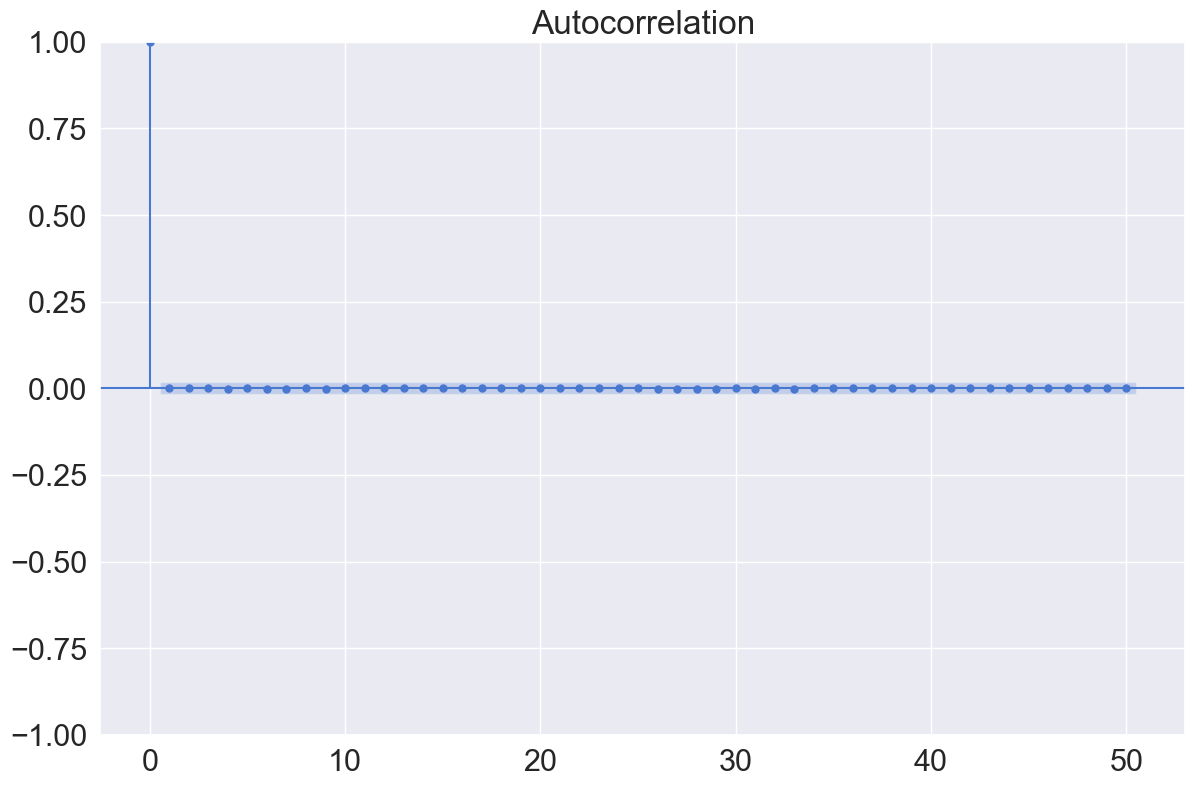

In [139]:
# 잔차의 자기상관성 확인
sm.graphics.tsa.plot_acf(Resid_tr.Error, lags=50, use_vlines=True)
plt.show()

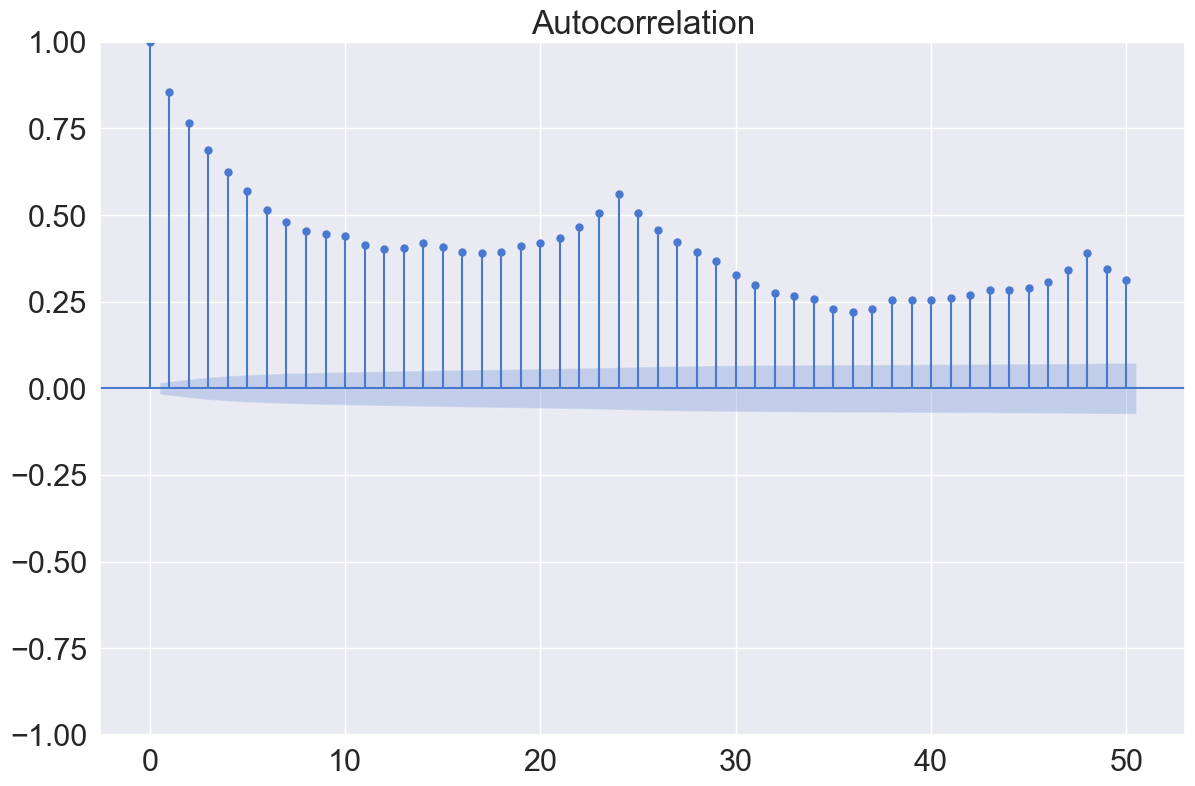

In [140]:
# 잔차의 자기상관성 확인
# 초기 예측오류 제외시
sm.graphics.tsa.plot_acf(Resid_tr.Error.iloc[1:], lags=50, use_vlines=True)
plt.show()

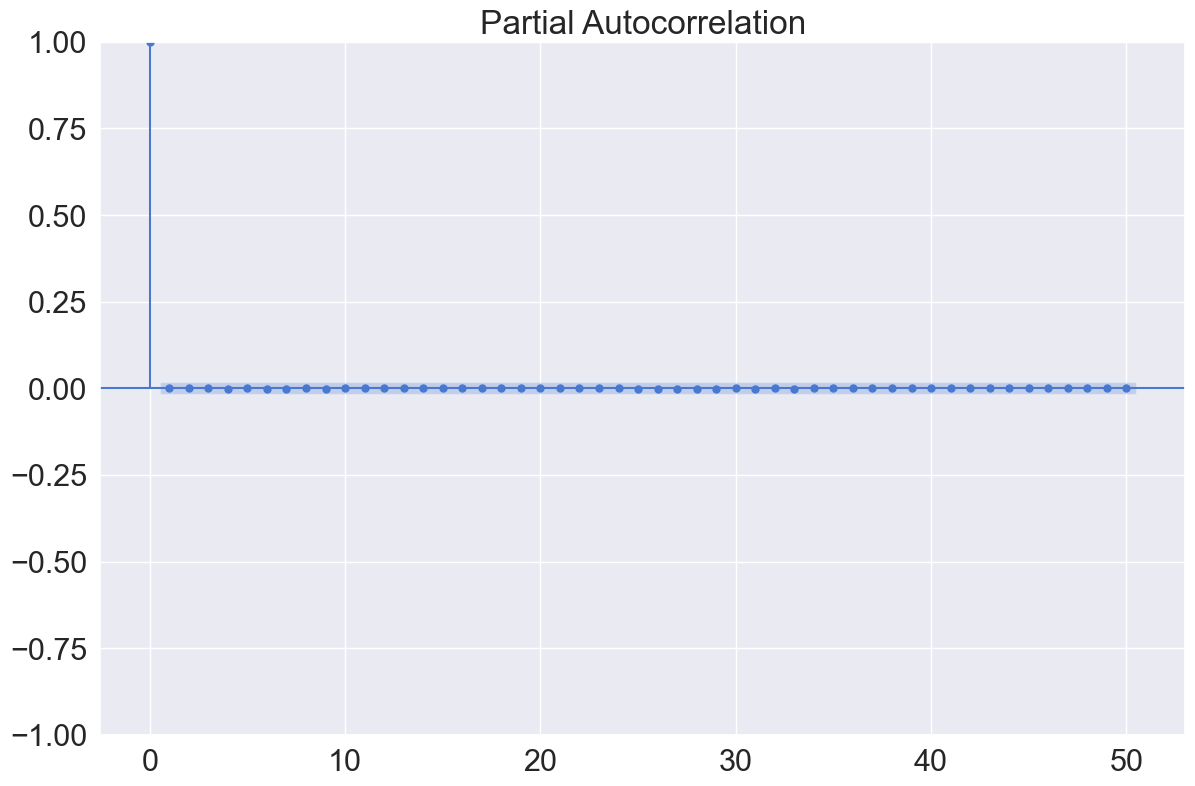

In [141]:
# 잔차의 편자기상관성 확인
sm.graphics.tsa.plot_pacf(Resid_tr.Error, lags=50, use_vlines=True)
plt.show()

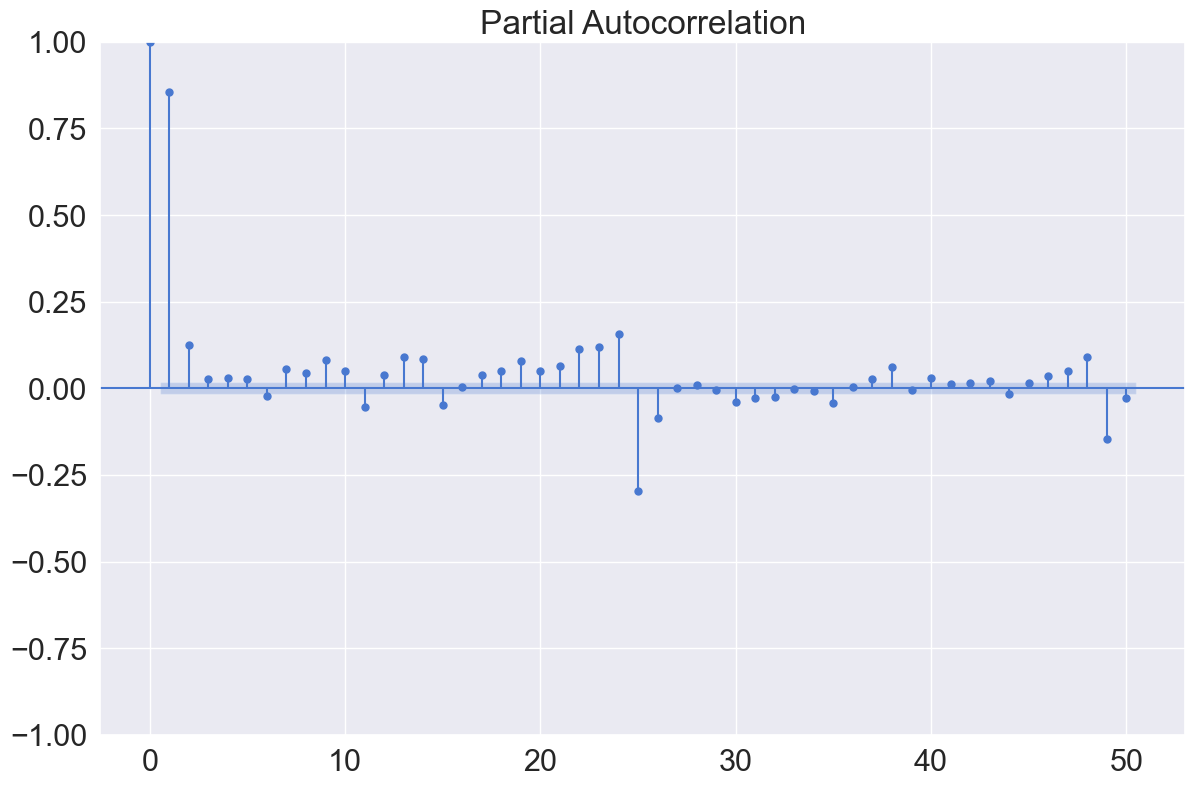

In [142]:
# 잔차의 편자기상관성 확인
# 초기 예측오류 제외시
sm.graphics.tsa.plot_pacf(Resid_tr.Error.iloc[1:], lags=50, use_vlines=True)
plt.show()

In [143]:
# 잔차의 정규분포, 자기상관, 등분산성, 정상성을 통계량으로 확인
# 정규분포
# Null Hypothesis: The residuals are normally distributed
Normality = pd.DataFrame([stats.shapiro(Resid_tr.Error)], 
                         index=['Normality'], columns=['Test Statistics', 'p-value']).T

# 등분산성
# Null Hypothesis: Error terms are homoscedastic
Heteroscedasticity = pd.DataFrame([sm.stats.diagnostic.het_goldfeldquandt(Resid_tr.Error, 
                                                                          X_train.values, 
                                                                          alternative='two-sided')],
                                  index=['Heteroscedasticity'], 
                                  columns=['Test Statistics', 'p-value', 'Alternative']).T

# 자기상관
# Null Hypothesis: Autocorrelation is absent
Autocorrelation = pd.DataFrame(sm.stats.diagnostic.acorr_ljungbox(Resid_tr.Error, lags=[10,50])).T
Autocorrelation.index = ['Test Statistics', 'p-value']
Autocorrelation.columns = ['Autocorr(lag10)', 'Autocorr(lag50)']

# 정상성
# ADF
# Null Hypothesis: The Time-series is non-stationalry
Stationarity = pd.Series(sm.tsa.stattools.adfuller(Resid_tr.Error)[0:3], 
                         index=['Test Statistics', 'p-value', 'Used Lag'])
for key, value in sm.tsa.stattools.adfuller(Resid_tr.Error)[4].items():
    Stationarity['Critical Value(%s)'%key] = value
Stationarity_ADF = pd.DataFrame(Stationarity, columns=['Stationarity_ADF'])
# KPSS
# Null Hypothesis: The Time-series is stationalry
Stationarity = pd.Series(sm.tsa.stattools.kpss(Resid_tr.Error)[0:3], 
                         index=['Test Statistics', 'p-value', 'Used Lag'])
for key, value in sm.tsa.stattools.kpss(Resid_tr.Error)[3].items():
    if key != '2.5%':
        Stationarity['Critical Value(%s)'%key] = value
Stationarity_KPSS = pd.DataFrame(Stationarity, columns=['Stationarity_KPSS'])

# 정리
Error_Analysis = pd.concat([Normality, Heteroscedasticity, Autocorrelation, 
                            Stationarity_ADF, Stationarity_KPSS], 
                           join='outer', axis=1)
Error_Analysis

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\825411335.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  Stationarity = pd.Series(sm.tsa.stattools.kpss(Resid_tr.Error)[0:3],
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\825411335.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  for key, value in sm.tsa.stattools.kpss(Resid_tr.Error)[3].items():


,Normality,Heteroscedasticity,Autocorr(lag10),Autocorr(lag50),Stationarity_ADF,Stationarity_KPSS
Test Statistics,0.01,0.00,0.03,0.10,-9.98,0.09
p-value,0.00,0.00,1.00,1.00,0.00,0.10
Alternative,NaN,two-sided,NaN,NaN,NaN,NaN
Used Lag,NaN,NaN,NaN,NaN,41.00,2.00
Critical Value(1%),NaN,NaN,NaN,NaN,-3.43,0.74
Critical Value(5%),NaN,NaN,NaN,NaN,-2.86,0.46
Critical Value(10%),NaN,NaN,NaN,NaN,-2.57,0.35


## **코드 정리:** 전처리 + 모델링 + 검증 + 에러분석

In [144]:
# 에러 분석
def error_analysis_timeseries(X_Data, Y_Pred, Residual, graph_on=False):
    # Setting
    Resid = Residual.copy()
    if Resid.shape[0] >= 100:
        lag_max = 50
    else:
        lag_max = int(Resid.shape[0]/2)-1
        
    if graph_on == True:
        ##### 시각화
        # index를 별도 변수로 저장 
        Resid = Residual.copy()
        Resid['Index'] = Resid.reset_index().index
    
        # 잔차의 정규분포성 확인
        sns.distplot(Resid.iloc[:,[0]], norm_hist='True', fit=stats.norm)
        plt.show()

        # 잔차의 등분산성 확인
        sns.lmplot(data=Resid, x='Index', y=Resid.columns[0],
                   fit_reg=True, line_kws={'color': 'red'}, height=5, aspect=2, ci=99, sharey=True)
        plt.show()
        
        # 잔차의 자기상관성 확인
        sm.graphics.tsa.plot_acf(Resid.iloc[:,[0]], lags=lag_max, use_vlines=True)
        plt.ylabel('Correlation')
        plt.show()
        
        # 잔차의 편자기상관성 확인
        sm.graphics.tsa.plot_pacf(Resid.iloc[:,[0]], lags=lag_max, use_vlines=True)
        plt.ylabel('Correlation')
        plt.show()

    ##### 통계량
    # 정규분포
    # Null Hypothesis: The residuals are normally distributed
    Normality = pd.DataFrame([stats.shapiro(Residual)], 
                             index=['Normality'], columns=['Test Statistics', 'p-value']).T

    # 등분산성
    # Null Hypothesis: Error terms are homoscedastic
    Heteroscedasticity = pd.DataFrame([sm.stats.diagnostic.het_goldfeldquandt(Residual, X_Data.values, alternative='two-sided')],
                                      index=['Heteroscedasticity'], 
                                      columns=['Test Statistics', 'p-value', 'Alternative']).T
    
    # 자기상관
    # Null Hypothesis: Autocorrelation is absent
    Autocorrelation = pd.concat([pd.DataFrame(sm.stats.diagnostic.acorr_ljungbox(Residual, lags=[10,lag_max]).iloc[:,0]),
                             pd.DataFrame(sm.stats.diagnostic.acorr_ljungbox(Residual, lags=[10,lag_max]).iloc[:,1])], axis=1).T
    Autocorrelation.index = ['Test Statistics', 'p-value']
    Autocorrelation.columns = ['Autocorr(lag10)', 'Autocorr(lag50)']
    
    # 정상성
    # ADF
    # Null Hypothesis: The Time-series is non-stationalry
    Stationarity = pd.Series(sm.tsa.stattools.adfuller(Residual)[0:3], 
                             index=['Test Statistics', 'p-value', 'Used Lag'])
    for key, value in sm.tsa.stattools.adfuller(Resid.iloc[:,[0]])[4].items():
        Stationarity['Critical Value(%s)'%key] = value
    Stationarity_ADF = pd.DataFrame(Stationarity, columns=['Stationarity_ADF'])
    # KPSS
    # Null Hypothesis: The Time-series is stationalry
    Stationarity = pd.Series(sm.tsa.stattools.kpss(Residual)[0:3], 
                             index=['Test Statistics', 'p-value', 'Used Lag'])
    for key, value in sm.tsa.stattools.kpss(Resid.Error)[3].items():
        if key != '2.5%':
            Stationarity['Critical Value(%s)'%key] = value
    Stationarity_KPSS = pd.DataFrame(Stationarity, columns=['Stationarity_KPSS'])
    
    Error_Analysis = pd.concat([Normality, Heteroscedasticity, Autocorrelation,
                                Stationarity_ADF, Stationarity_KPSS], join='outer', axis=1)
    
    return Error_Analysis

Train_size: (13128, 28) Test_size: (4416, 28)
X_train: (13128, 24) Y_train: (13128, 1)
X_test: (4416, 24) Y_test: (4416, 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.362e+08
Date:                Sun, 21 Sep 2025   Prob (F-statistic):               0.00
Time:                        23:54:43   Log-Likelihood:                 1906.2
No. Observations:               13128   AIC:                            -3764.
Df Residuals:                   13104   BIC:                            -3585.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
season            -0.0005      0.004     -0.129      0.897      -0.009       0.008
holiday            0.0083      0.014      0.612      0.540      -0.018       0.035
workingday         0.0079      0.007      1.184      0.236      -0.005       0.021
weather            0.0042      0.003      1.232      0.218      -0.003       0.011
temp               0.0022      0.002      1.075      0.282      -0.002       0.006
atemp             -0.0025      0.002     -1.347      0.178      -0.006       0.001
humidity          -0.0001      0.000     -0.845      0.398      -0.000       0.000
windspeed          0.0003      0.000      1.062      0.288      -0.000       0.001
count_trend     9.161e-05   8.57e-05      1.069      0.285   -7.64e-05       0.000
count_seasonal  1.984e-05   2.56e-05      0.775      0.438   -3.03e-05       7e-05
count_Day       4.177e-05   8.36e-05      0.500      0.617      -0.000       0.000
count_Week     -4.345e-05   9.61e-05     -0.452      0.651      -0.000       0.000
count_diff         1.0000    2.9e-05   3.45e+04      0.000       1.000       1.000
Year           -1.547e-05   7.97e-06     -1.939      0.052   -3.11e-05    1.66e-07
Quater_ver2        0.0004      0.002      0.180      0.857      -0.004       0.005
Month              0.0026      0.002      1.051      0.293      -0.002       0.007
Day                0.0004      0.000      1.728      0.084   -4.91e-05       0.001
Hour               0.0006      0.000      1.538      0.124      -0.000       0.001
DayofWeek          0.0003      0.002      0.224      0.823      -0.003       0.003
count_lag1         1.0000    2.7e-05    3.7e+04      0.000       1.000       1.000
count_lag2     -1.926e-05   2.59e-05     -0.744      0.457      -7e-05    3.15e-05
Quater_Dummy_2    -0.0010      0.009     -0.115      0.909      -0.019       0.017
Quater_Dummy_3    -0.0037      0.017     -0.220      0.826      -0.037       0.030
Quater_Dummy_4    -0.0132      0.026     -0.512      0.609      -0.064       0.037
==============================================================================
Omnibus:                    54426.083   Durbin-Watson:                   1.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      93552024983.816
Skew:                        -114.255   Prob(JB):                         0.00
Kurtosis:                   13078.751   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

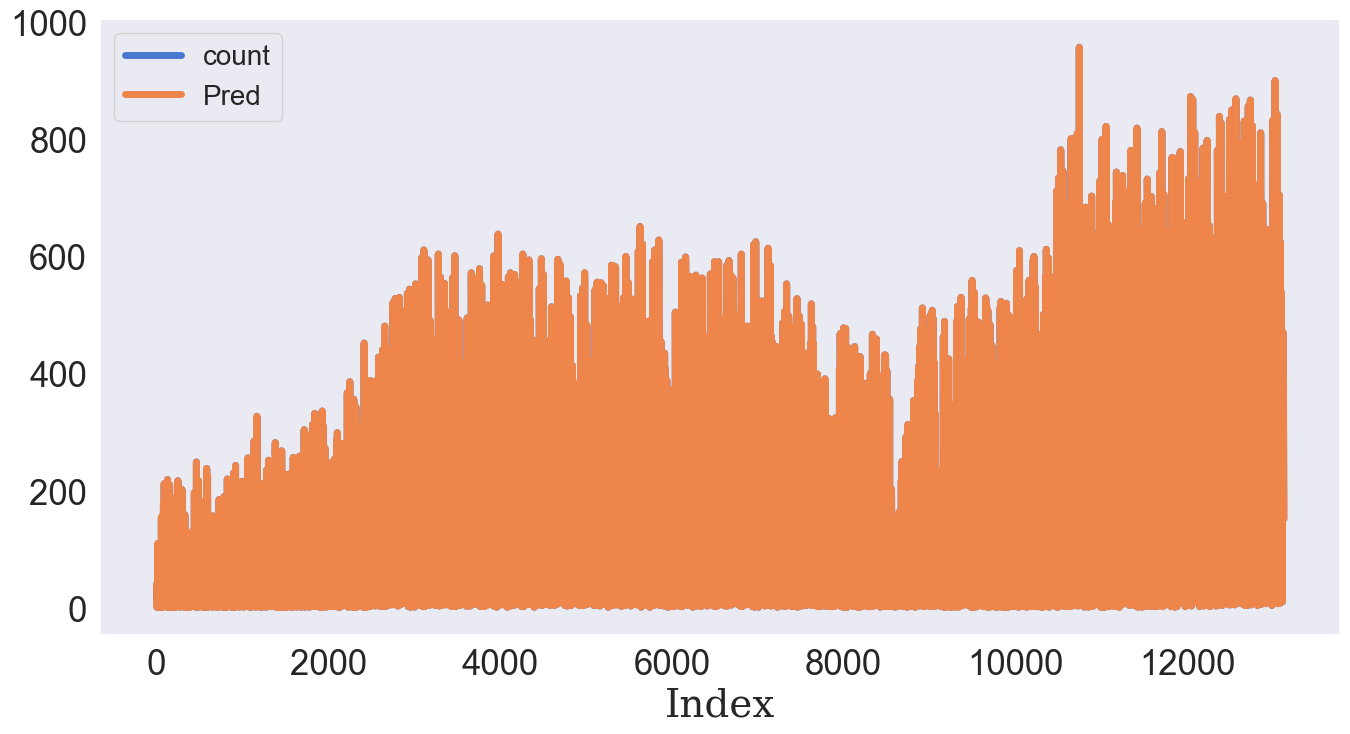

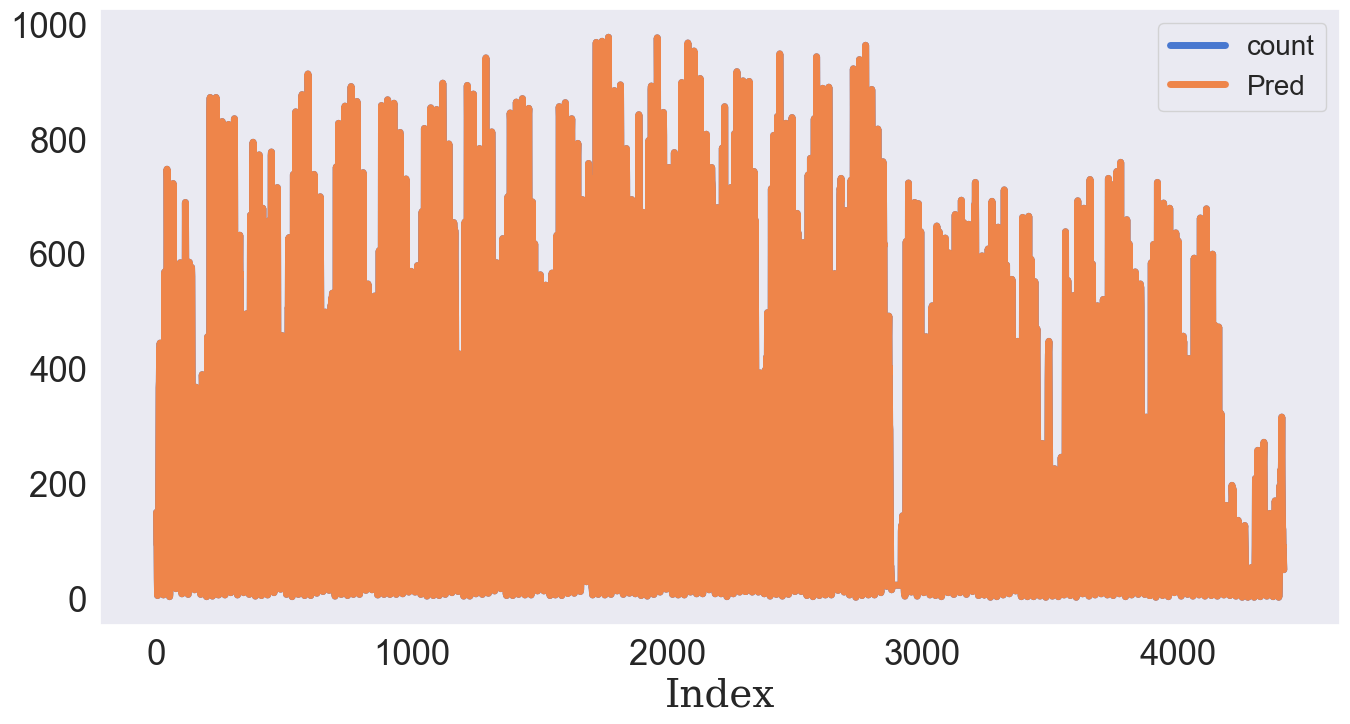

,MAE,MSE,MAPE
Train,0.01,0.04,0.00
Test,0.01,0.00,0.00


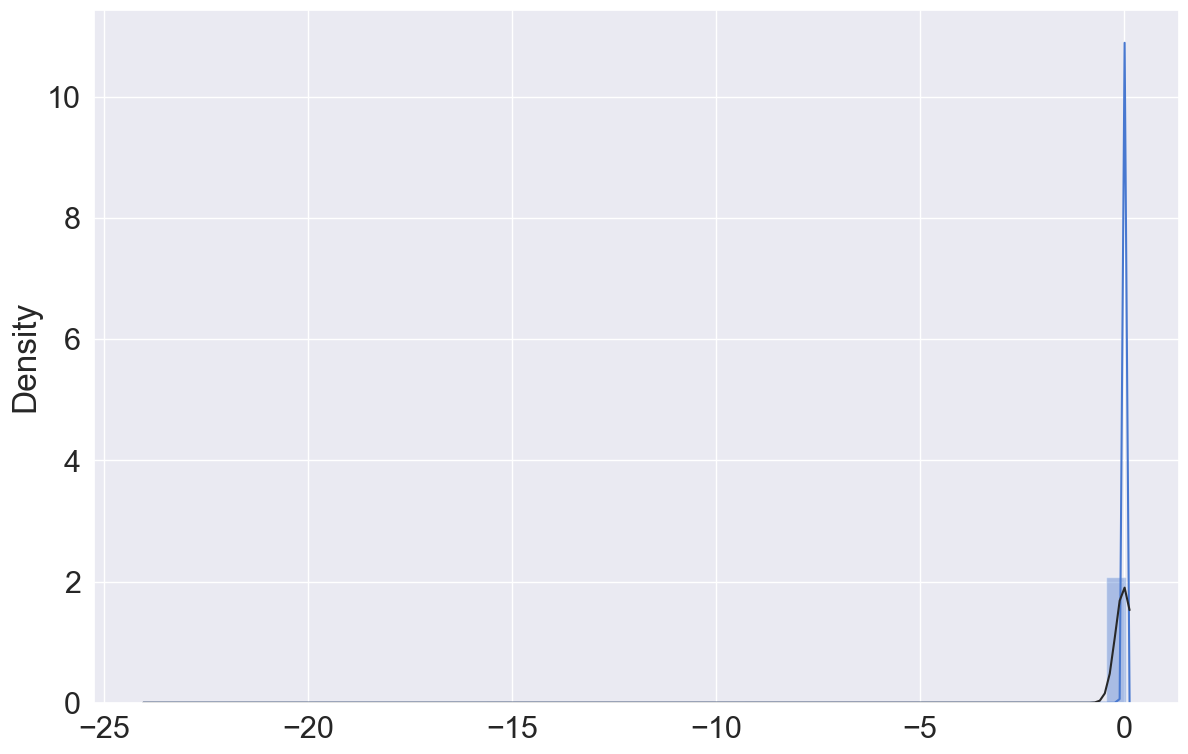

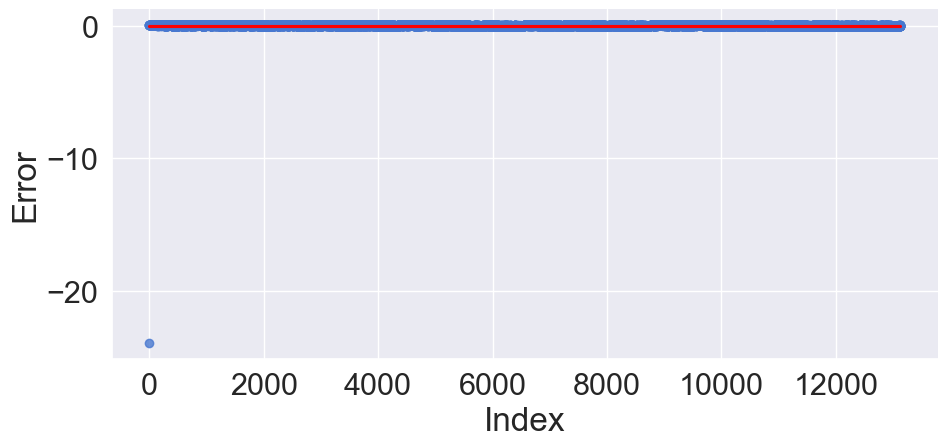

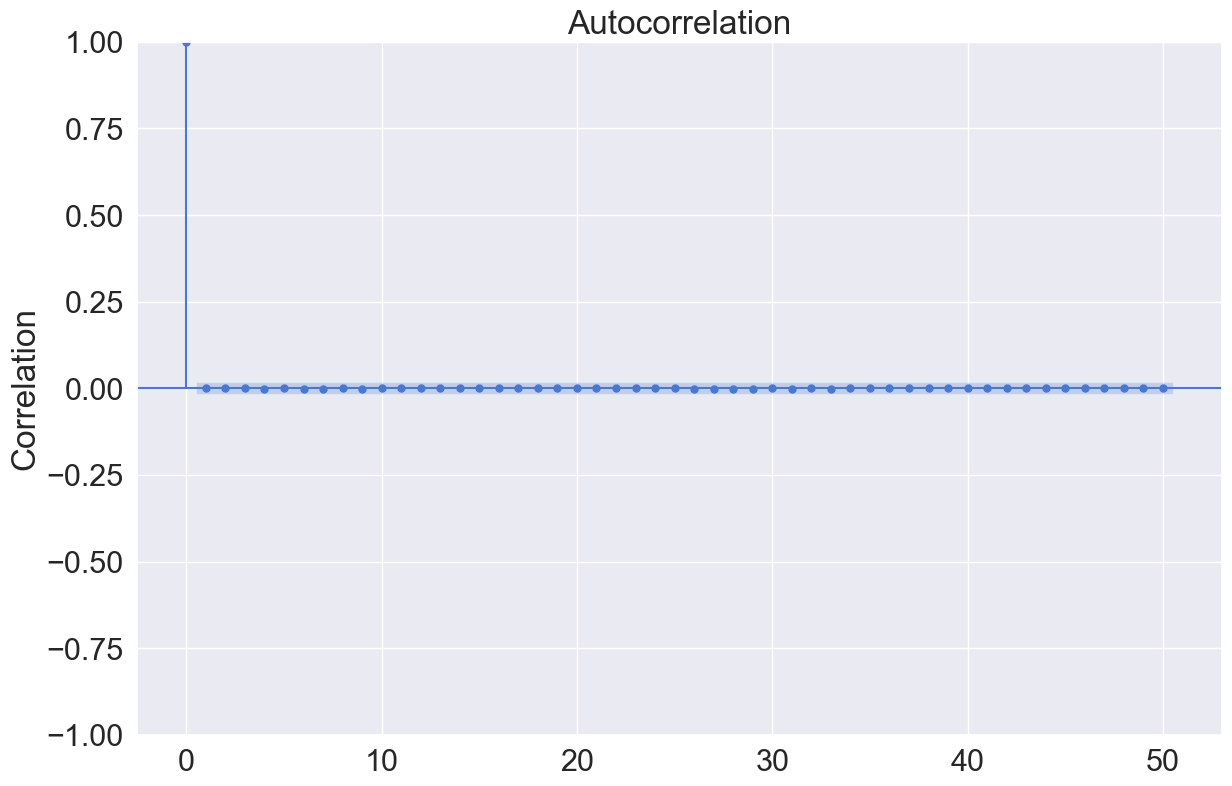

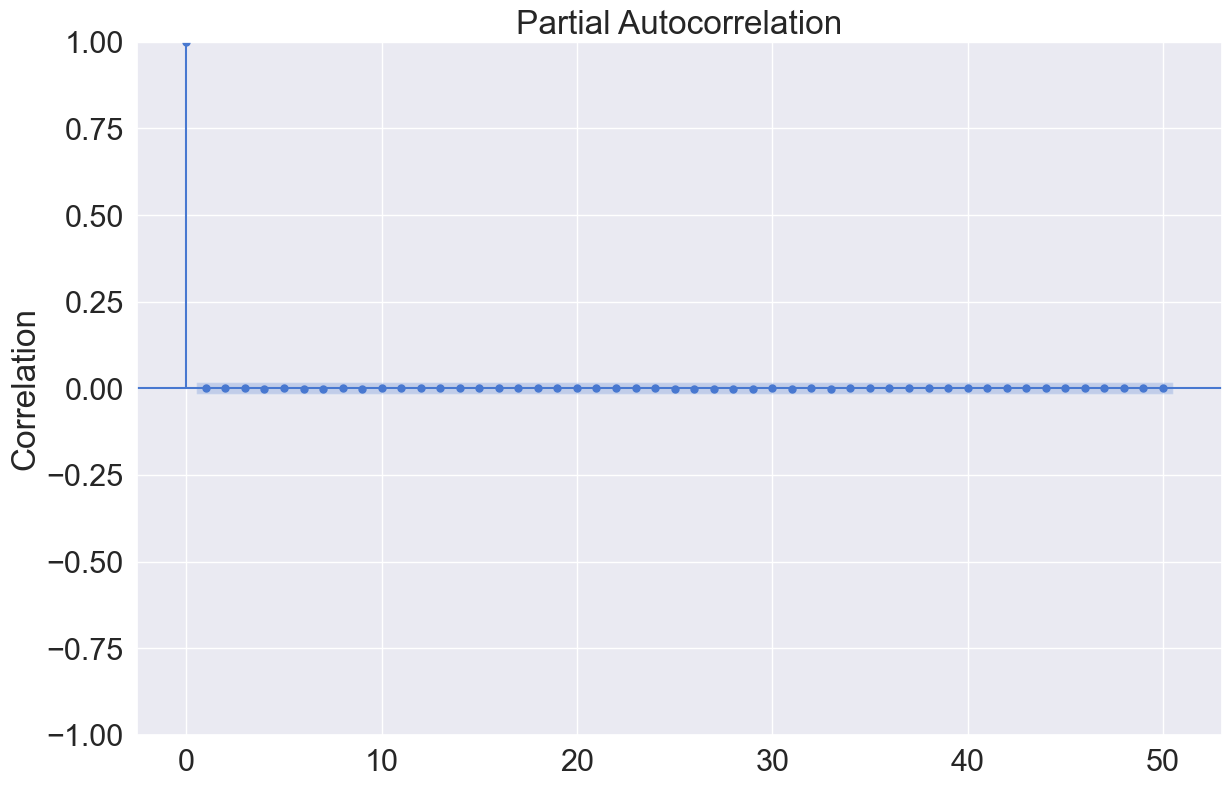

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\2961621548.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  Stationarity = pd.Series(sm.tsa.stattools.kpss(Residual)[0:3],
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\2961621548.py:66: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  for key, value in sm.tsa.stattools.kpss(Resid.Error)[3].items():


,Normality,Heteroscedasticity,Autocorr(lag10),Autocorr(lag50),Stationarity_ADF,Stationarity_KPSS
Test Statistics,0.01,0.00,0.03,0.10,-9.98,0.09
p-value,0.00,0.00,1.00,1.00,0.00,0.10
Alternative,NaN,two-sided,NaN,NaN,NaN,NaN
Used Lag,NaN,NaN,NaN,NaN,41.00,2.00
Critical Value(1%),NaN,NaN,NaN,NaN,-3.43,0.74
Critical Value(5%),NaN,NaN,NaN,NaN,-2.86,0.46
Critical Value(10%),NaN,NaN,NaN,NaN,-2.57,0.35


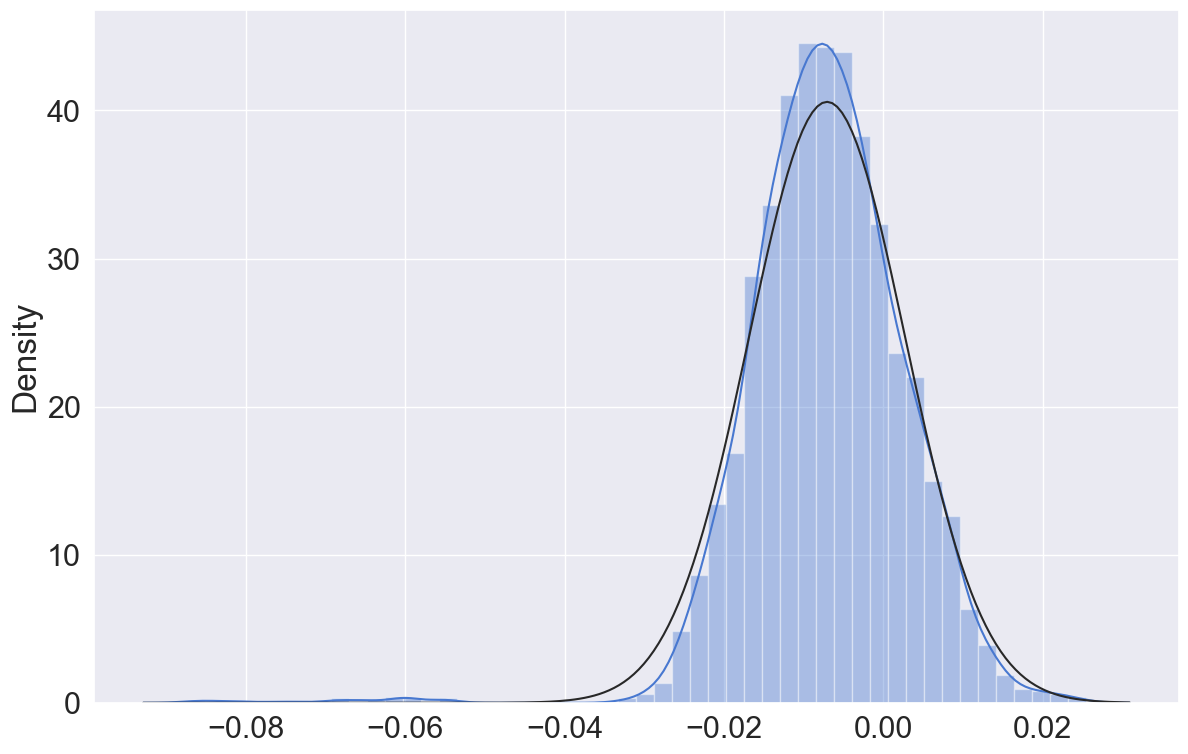

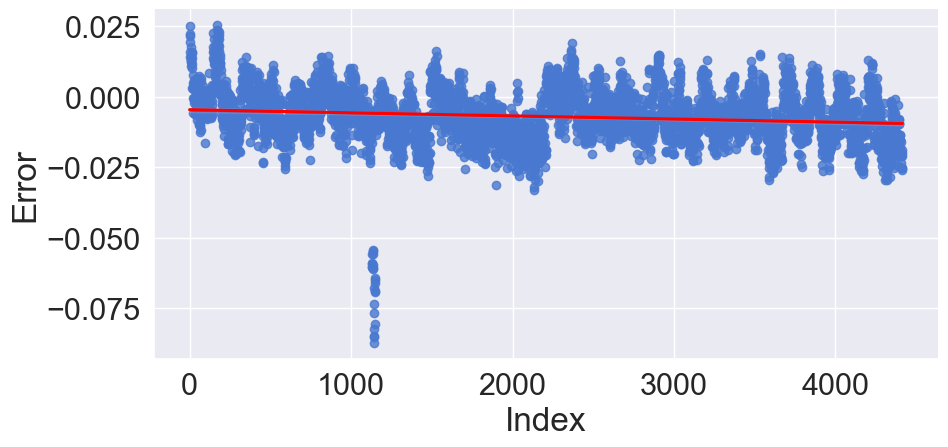

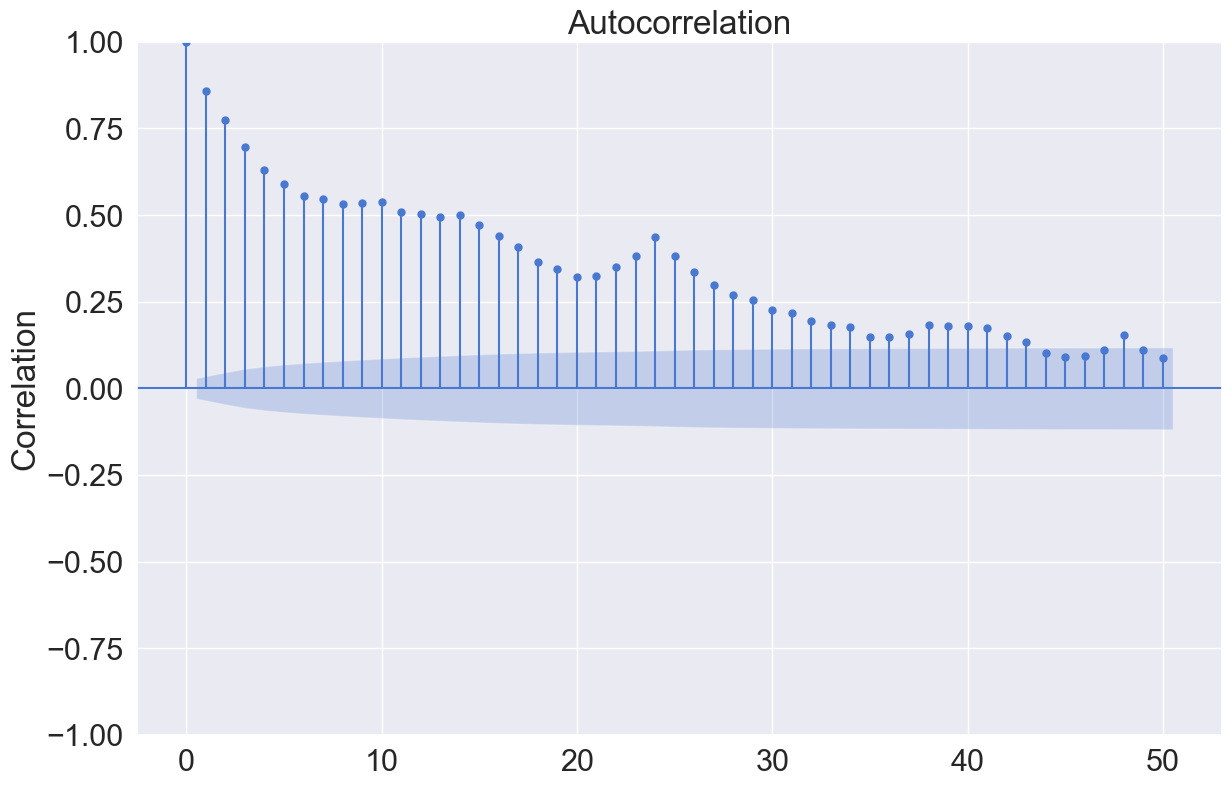

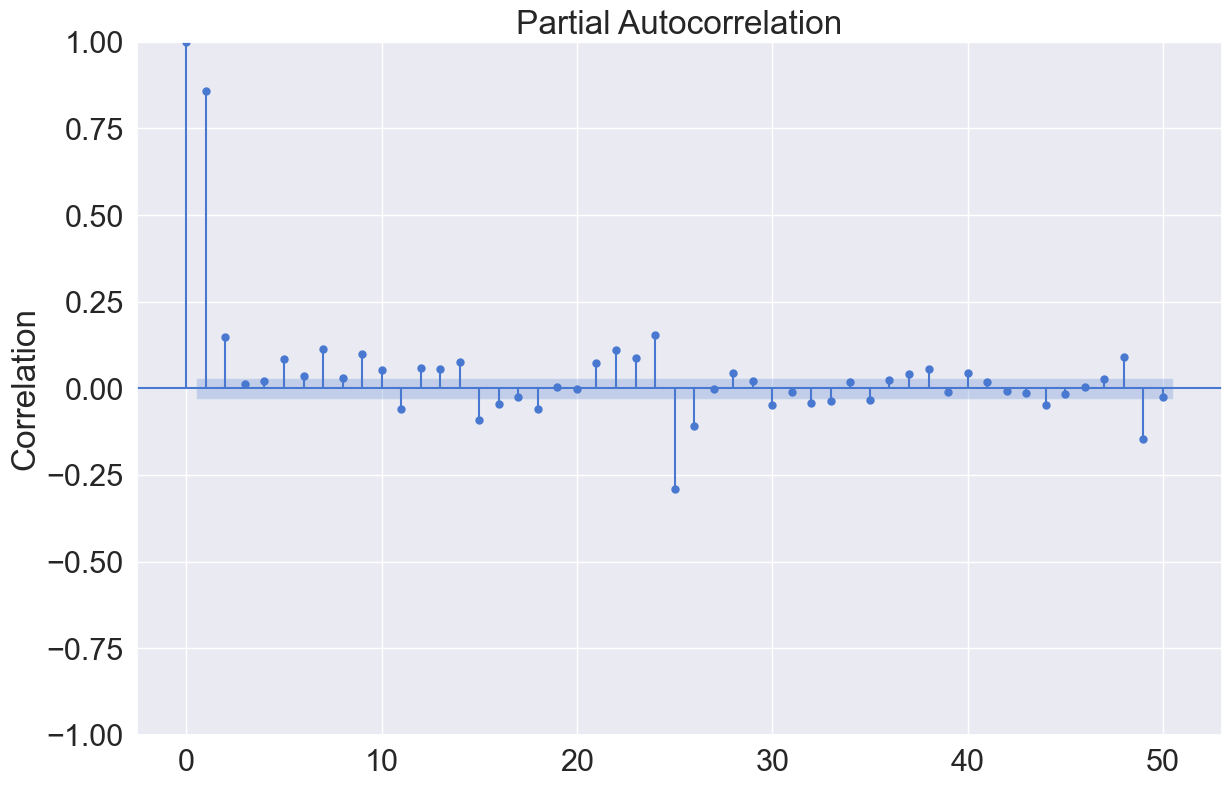

,Normality,Heteroscedasticity,Autocorr(lag10),Autocorr(lag50),Stationarity_ADF,Stationarity_KPSS
Test Statistics,0.93,0.63,"17,815.72","33,403.03",-8.08,0.51
p-value,0.00,0.00,0.00,0.00,0.00,0.04
Alternative,NaN,two-sided,NaN,NaN,NaN,NaN
Used Lag,NaN,NaN,NaN,NaN,31.00,38.00
Critical Value(1%),NaN,NaN,NaN,NaN,-3.43,0.74
Critical Value(5%),NaN,NaN,NaN,NaN,-2.86,0.46
Critical Value(10%),NaN,NaN,NaN,NaN,-2.57,0.35


In [145]:
# 데이터 로딩
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df_all = pd.read_csv(location)

# 데이터 전처리
df_nfe = non_feature_engineering(df_all)
df_fe = feature_engineering(df_all)

# 데이터 분리
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
X_colname = [x for x in df_fe.columns if x not in Y_colname+X_remove]
X_train, X_test, Y_train, Y_test = datasplit_ts(df_fe, Y_colname, X_colname, '2012-07-01')

# Linear Regression
model_lr = sm.OLS(Y_train, X_train).fit()
display(model_lr.summary())

Y_trpred = pd.DataFrame(model_lr.predict(X_train), columns=['Pred'])
Y_tepred = pd.DataFrame(model_lr.predict(X_test), columns=['Pred'])
plot_prediction(pd.concat([Y_train, Y_trpred], axis=1).reset_index().iloc[:,1:])
plot_prediction(pd.concat([Y_test, Y_tepred], axis=1).reset_index().iloc[:,1:])

# 분석 검증
Score = evaluation_reg_trte(Y_train, Y_trpred, Y_test, Y_tepred)
display(Score)

# 에러 분석
Resid_tr = Y_train - Y_trpred.values
Resid_tr.columns = ['Error']
Resid_te = Y_test - Y_tepred.values
Resid_te.columns = ['Error']

Error_tr = error_analysis_timeseries(X_train, Y_trpred, Resid_tr, graph_on=True)
display(Error_tr)
Error_te = error_analysis_timeseries(X_test, Y_tepred, Resid_te, graph_on=True)
display(Error_te)

In [146]:
# Train
# 비정규분포 / 등분산아님 / 자기상관없음(lag10) / 자기상관없음(lag50) / 정상성(ADF) / 정상성(KPSS)
# Test
# 비정규분포 / 등분산아님 / 자기상관있음(lag10) / 자기상관있음(lag50) / 정상성(ADF) / 비정상성(KPSS)

# **Summary:** 분석단계 이해도 낮은 부분 확인

**1) 데이터 핸들링**  

**2) 단계이해**  
> **(1) `Import Library`**
>
> **(2) `Data Loading`**   
>
> **(3) `Preprocessing`**   
>
> **(4) `Applying Base Algorithm`**   
>
> **(5) `Evaluation`**  
>
> **(6) `Error Analysis`**  

**3) 결과 해석**  

## 분석가 정의 함수

In [147]:
# 시계열 변수추출
## 날짜인식 및 빈도 설정만
def non_feature_engineering(df):
    df_nfe = df.copy()
    if 'datetime' in df_nfe.columns:
        df_nfe['datetime'] = pd.to_datetime(df_nfe['datetime'])
        df_nfe['DateTime'] = pd.to_datetime(df_nfe['datetime'])
    if df_nfe.index.dtype == 'int64':
        df_nfe.set_index('DateTime', inplace=True)
    df_nfe = df_nfe.asfreq('H', method='ffill')

    return df_nfe


## 날짜인식 및 빈도 설정을 포함한 모든 전처리
def feature_engineering(df):
    df_fe = df.copy()
    if 'datetime' in df_fe.columns:
        df_fe['datetime'] = pd.to_datetime(df_fe['datetime'])
        df_fe['DateTime'] = pd.to_datetime(df_fe['datetime'])

    if df_fe.index.dtype == 'int64':
        df_fe.set_index('DateTime', inplace=True)

    df_fe = df_fe.asfreq('H', method='ffill')

    result = sm.tsa.seasonal_decompose(df_fe['count'], model='additive')
    Y_trend = pd.DataFrame(result.trend)
    Y_trend.fillna(method='ffill', inplace=True)
    Y_trend.fillna(method='bfill', inplace=True)
    Y_trend.columns = ['count_trend']
    Y_seasonal = pd.DataFrame(result.seasonal)
    Y_seasonal.fillna(method='ffill', inplace=True)
    Y_seasonal.fillna(method='bfill', inplace=True)
    Y_seasonal.columns = ['count_seasonal']
    pd.concat([df_fe, Y_trend, Y_seasonal], axis=1).isnull().sum()
    if 'count_trend' not in df_fe.columns:
        if 'count_seasonal' not in df_fe.columns:
            df_fe = pd.concat([df_fe, Y_trend, Y_seasonal], axis=1)

    Y_count_Day = df_fe[['count']].rolling(24).mean()
    Y_count_Day.fillna(method='ffill', inplace=True)
    Y_count_Day.fillna(method='bfill', inplace=True)
    Y_count_Day.columns = ['count_Day']
    Y_count_Week = df_fe[['count']].rolling(24*7).mean()
    Y_count_Week.fillna(method='ffill', inplace=True)
    Y_count_Week.fillna(method='bfill', inplace=True)
    Y_count_Week.columns = ['count_Week']
    if 'count_Day' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_count_Day], axis=1)
    if 'count_Week' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_count_Week], axis=1)

    Y_diff = df_fe[['count']].diff()
    Y_diff.fillna(method='ffill', inplace=True)
    Y_diff.fillna(method='bfill', inplace=True)
    Y_diff.columns = ['count_diff']
    if 'count_diff' not in df_fe.columns:
        df_fe = pd.concat([df_fe, Y_diff], axis=1)

#     df_fe['temp_group'] = pd.cut(df_fe['temp'], 10)
    df_fe['Year'] = df_fe.datetime.dt.year
    df_fe['Quater'] = df_fe.datetime.dt.quarter
    df_fe['Quater_ver2'] = df_fe['Quater'] + (df_fe.Year - df_fe.Year.min()) * 4
    df_fe['Month'] = df_fe.datetime.dt.month
    df_fe['Day'] = df_fe.datetime.dt.day
    df_fe['Hour'] = df_fe.datetime.dt.hour
    df_fe['DayofWeek'] = df_fe.datetime.dt.dayofweek

    df_fe['count_lag1'] = df_fe['count'].shift(1)
    df_fe['count_lag2'] = df_fe['count'].shift(2)
    df_fe['count_lag1'].fillna(method='bfill', inplace=True)
    df_fe['count_lag2'].fillna(method='bfill', inplace=True)

    if 'Quater' in df_fe.columns:
        if 'Quater_Dummy' not in ['_'.join(col.split('_')[:2]) for col in df_fe.columns]:
            df_fe = pd.concat([df_fe, pd.get_dummies(df_fe['Quater'], 
                                                     prefix='Quater_Dummy', drop_first=True).astype(int)], axis=1)
            del df_fe['Quater']
    
    return df_fe


# 데이터 분리
## cross sectional 데이터
def datasplit(df, Y_colname, test_size=0.2, random_state=123):
    X_colname = [x for x in df.columns if x not in Y_colname]
       
    X_train, X_test, Y_train, Y_test = train_test_split(df[X_colname], df[Y_colname],
                                                        test_size=test_size, random_state=random_state)
    print(X_train.shape, Y_train.shape)
    print(X_test.shape, Y_test.shape)
    
    return X_train, X_test, Y_train, Y_test


## time series 데이터
def datasplit_ts(df, Y_colname, X_colname, criteria):
    df_train = df.loc[df.index < criteria,:]
    df_test = df.loc[df.index >= criteria,:]
    Y_train = df_train[Y_colname]
    X_train = df_train[X_colname]
    Y_test = df_test[Y_colname]
    X_test = df_test[X_colname]
    print('Train_size:', df_train.shape, 'Test_size:', df_test.shape)
    print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
    print('X_test:', X_test.shape, 'Y_test:', Y_test.shape)
    
    return X_train, X_test, Y_train, Y_test


# 실제 Y와 예측치 시각화
def plot_prediction(Y_true_pred):
    plt.figure(figsize=(16, 8))
    plt.plot(Y_true_pred, linewidth=5, label=Y_true_pred.columns)
    plt.xticks(fontsize=25, rotation=0)
    plt.yticks(fontsize=25)
    plt.xlabel('Index', fontname='serif', fontsize=28)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()
    
    
# 검증 함수화
def evaluation_reg(Y_real, Y_pred):
    MAE = mean_absolute_error(Y_real, Y_pred)
    MSE = mean_squared_error(Y_real, Y_pred)
    MAPE = mean_absolute_percentage_error(Y_real, Y_pred)
    Score = pd.DataFrame([MAE, MSE, MAPE], index=['MAE', 'MSE', 'MAPE'], columns=['Score']).T
    
    return Score

# Train & Test 모두의 검증 함수화
def evaluation_reg_trte(Y_real_tr, Y_pred_tr, Y_real_te, Y_pred_te):
    Score_tr = evaluation_reg(Y_real_tr, Y_pred_tr)
    Score_te = evaluation_reg(Y_real_te, Y_pred_te)
    Score_trte = pd.concat([Score_tr, Score_te], axis=0)
    Score_trte.index = ['Train', 'Test']

    return Score_trte


# 에러 분석
def error_analysis_timeseries(X_Data, Y_Pred, Residual, graph_on=False):
    if graph_on == True:
        ##### 시각화
        # index를 별도 변수로 저장 
        Resid = Residual.copy()
        Resid['Index'] = Resid.reset_index().index
    
        # 잔차의 정규분포성 확인
        sns.distplot(Resid.iloc[:,[0]], norm_hist='True', fit=stats.norm)
        plt.show()

        # 잔차의 등분산성 확인
        sns.lmplot(data=Resid, x='Index', y=Resid.columns[0],
                   fit_reg=True, line_kws={'color': 'red'}, height=5, aspect=2, ci=99, sharey=True)
        plt.show()
        
        # 잔차의 자기상관성 확인
        sm.graphics.tsa.plot_acf(Resid.iloc[:,[0]], lags=50, use_vlines=True)
        plt.ylabel('Correlation')
        plt.show()
        
        # 잔차의 편자기상관성 확인
        sm.graphics.tsa.plot_pacf(Resid.iloc[:,[0]], lags=50, use_vlines=True)
        plt.ylabel('Correlation')
        plt.show()

    ##### 통계량
    # 정규분포
    # Null Hypothesis: The residuals are normally distributed
    Normality = pd.DataFrame([stats.shapiro(Residual)], 
                             index=['Normality'], columns=['Test Statistics', 'p-value']).T

    # 등분산성
    # Null Hypothesis: Error terms are homoscedastic
    Heteroscedasticity = pd.DataFrame([sm.stats.diagnostic.het_goldfeldquandt(Residual, X_Data.values, alternative='two-sided')],
                                      index=['Heteroscedasticity'], 
                                      columns=['Test Statistics', 'p-value', 'Alternative']).T
    
    # 자기상관
    # Null Hypothesis: Autocorrelation is absent
    Autocorrelation = pd.concat([pd.DataFrame(sm.stats.diagnostic.acorr_ljungbox(Residual, lags=[10,50]).iloc[:,0]),
                             pd.DataFrame(sm.stats.diagnostic.acorr_ljungbox(Residual, lags=[10,50]).iloc[:,1])], axis=1).T
    Autocorrelation.index = ['Test Statistics', 'p-value']
    Autocorrelation.columns = ['Autocorr(lag10)', 'Autocorr(lag50)']
    
    
    # 정상성
    # ADF
    # Null Hypothesis: The Time-series is non-stationalry
    Stationarity = pd.Series(sm.tsa.stattools.adfuller(Resid.iloc[:,[0]])[0:3], 
                             index=['Test Statistics', 'p-value', 'Used Lag'])
    for key, value in sm.tsa.stattools.adfuller(Resid.iloc[:,[0]])[4].items():
        Stationarity['Critical Value(%s)'%key] = value
    Stationarity_ADF = pd.DataFrame(Stationarity, columns=['Stationarity_ADF'])
    # KPSS
    # Null Hypothesis: The Time-series is stationalry
    Stationarity = pd.Series(sm.tsa.stattools.kpss(Resid.iloc[:,[0]])[0:3], 
                             index=['Test Statistics', 'p-value', 'Used Lag'])
    for key, value in sm.tsa.stattools.kpss(Resid.Error)[3].items():
        if key != '2.5%':
            Stationarity['Critical Value(%s)'%key] = value
    Stationarity_KPSS = pd.DataFrame(Stationarity, columns=['Stationarity_KPSS'])
    
    Error_Analysis = pd.concat([Normality, Heteroscedasticity, Autocorrelation,
                                Stationarity_ADF, Stationarity_KPSS], join='outer', axis=1)
    
    return Error_Analysis

## 전처리 미반영 분석결과

Train_size: (13128, 12) Test_size: (4416, 12)
X_train: (13128, 8) Y_train: (13128, 1)
X_test: (4416, 8) Y_test: (4416, 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  count   R-squared (uncentered):                   0.638
Model:                            OLS   Adj. R-squared (uncentered):              0.638
Method:                 Least Squares   F-statistic:                              2889.
Date:                Sun, 21 Sep 2025   Prob (F-statistic):                        0.00
Time:                        23:54:49   Log-Likelihood:                         -83421.
No. Observations:               13128   AIC:                                  1.669e+05
Df Residuals:                   13120   BIC:                                  1.669e+05
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
season         3.3659      1.286      2.618      0.009       0.846       5.886
holiday       -6.2896      7.466     -0.842      0.400     -20.924       8.345
workingday    10.3553      2.641      3.921      0.000       5.178      15.533
weather        7.1906      2.093      3.436      0.001       3.089      11.292
temp          -7.8544      1.222     -6.429      0.000     -10.249      -5.460
atemp         16.0695      1.095     14.676      0.000      13.923      18.216
humidity      -1.7353      0.063    -27.356      0.000      -1.860      -1.611
windspeed      2.2749      0.136     16.745      0.000       2.009       2.541
==============================================================================
Omnibus:                     2168.771   Durbin-Watson:                   0.419
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3942.747
Skew:                           1.050   Prob(JB):                         0.00
Kurtosis:                       4.672   Cond. No.                         450.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

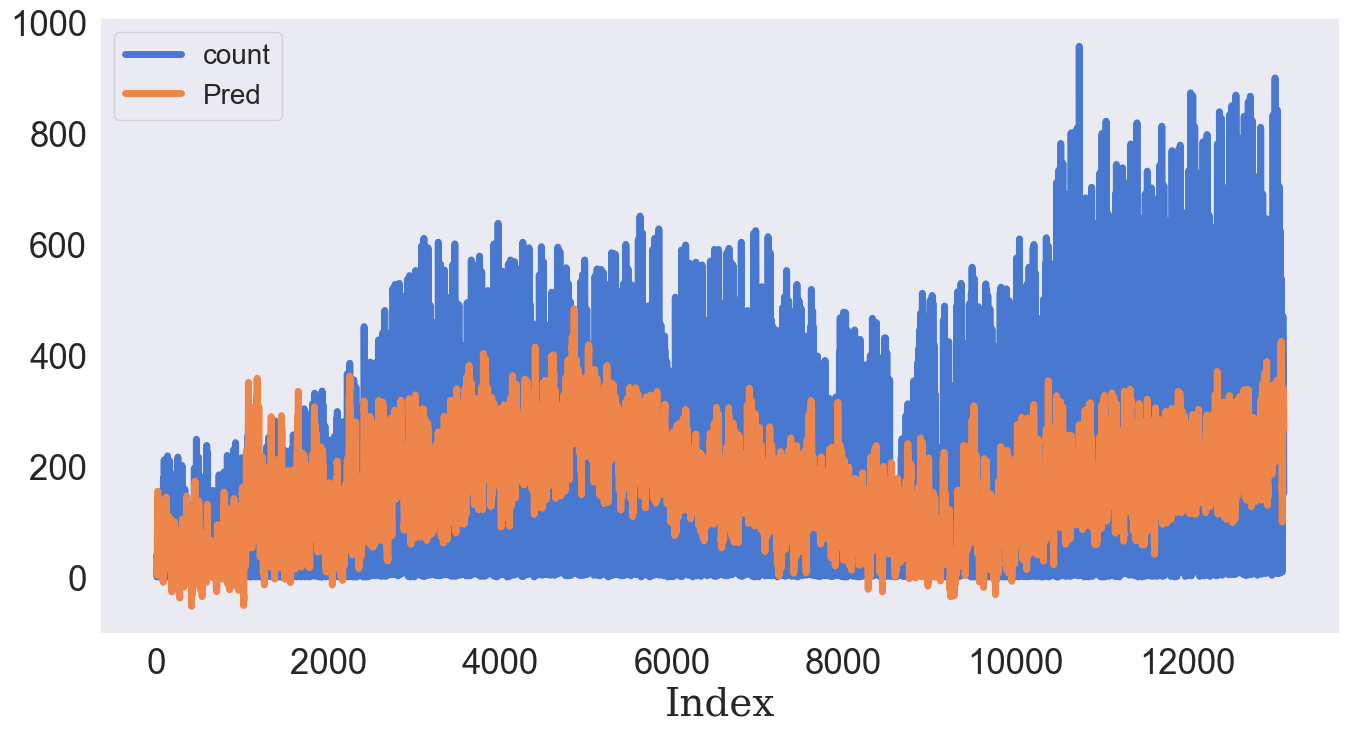

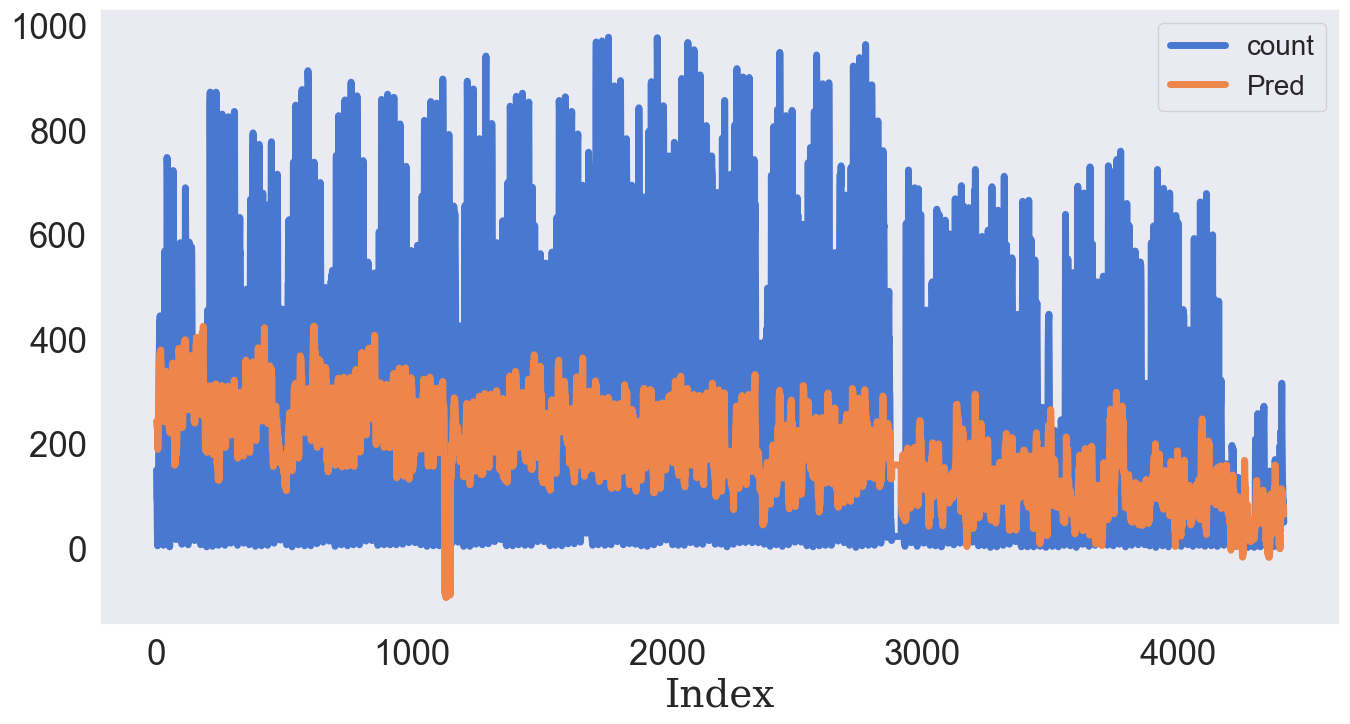

,MAE,MSE,MAPE
Train,103.09,"19,360.42",4.58
Test,150.03,"43,410.27",3.17


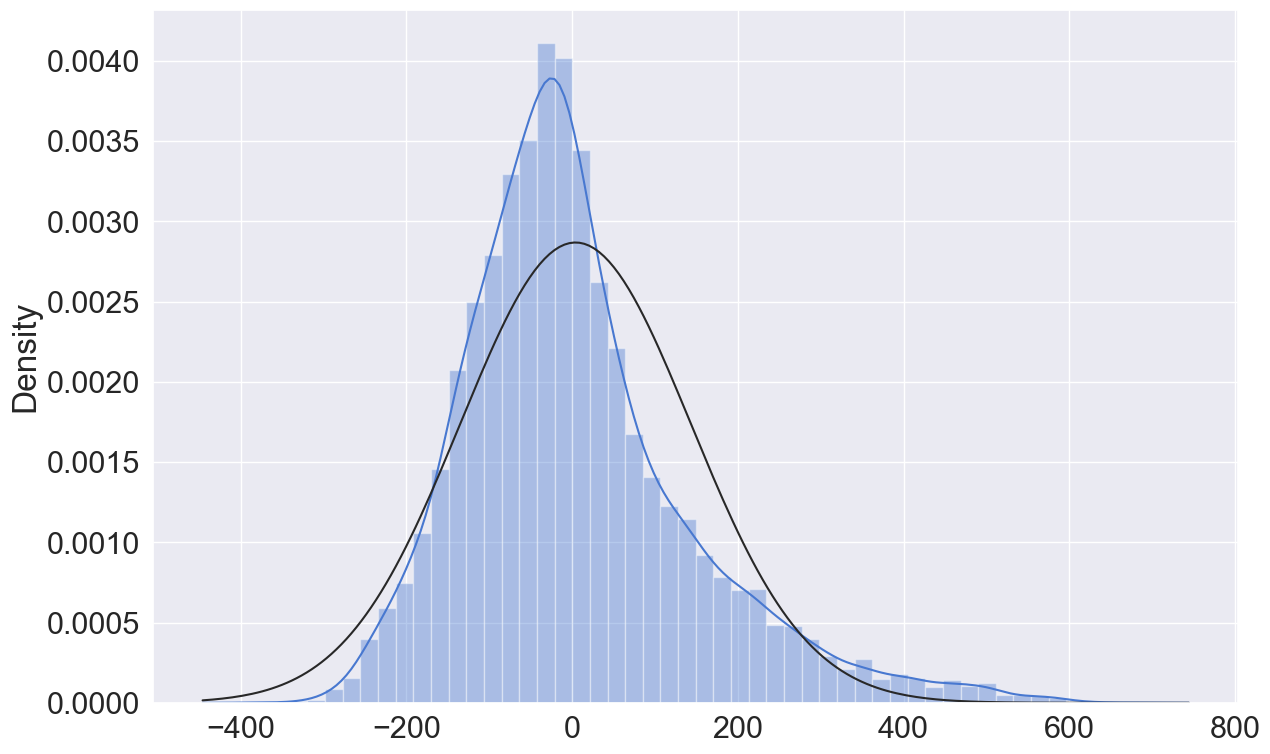

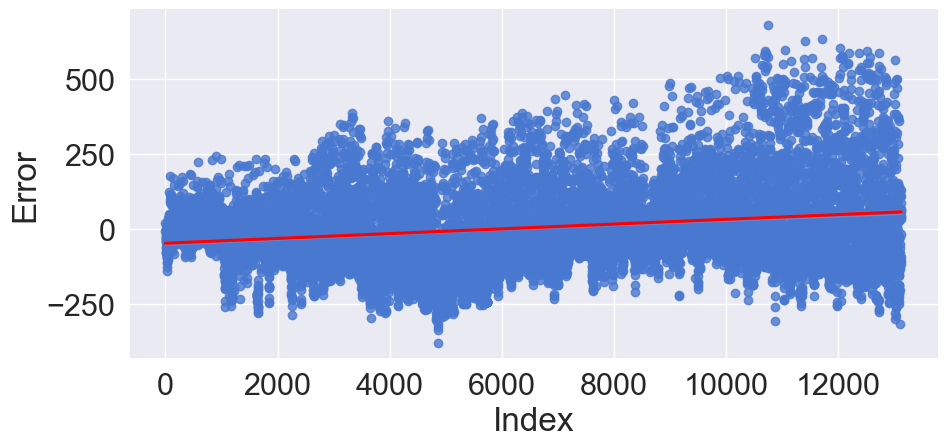

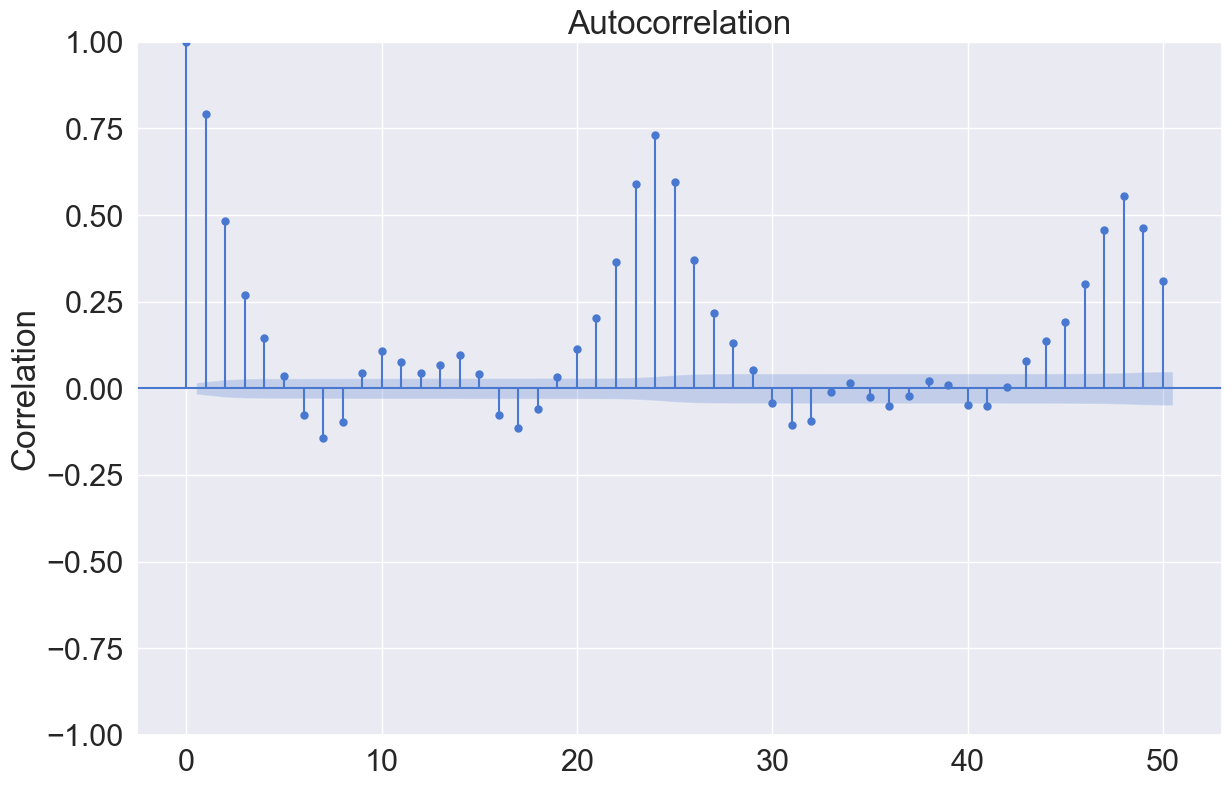

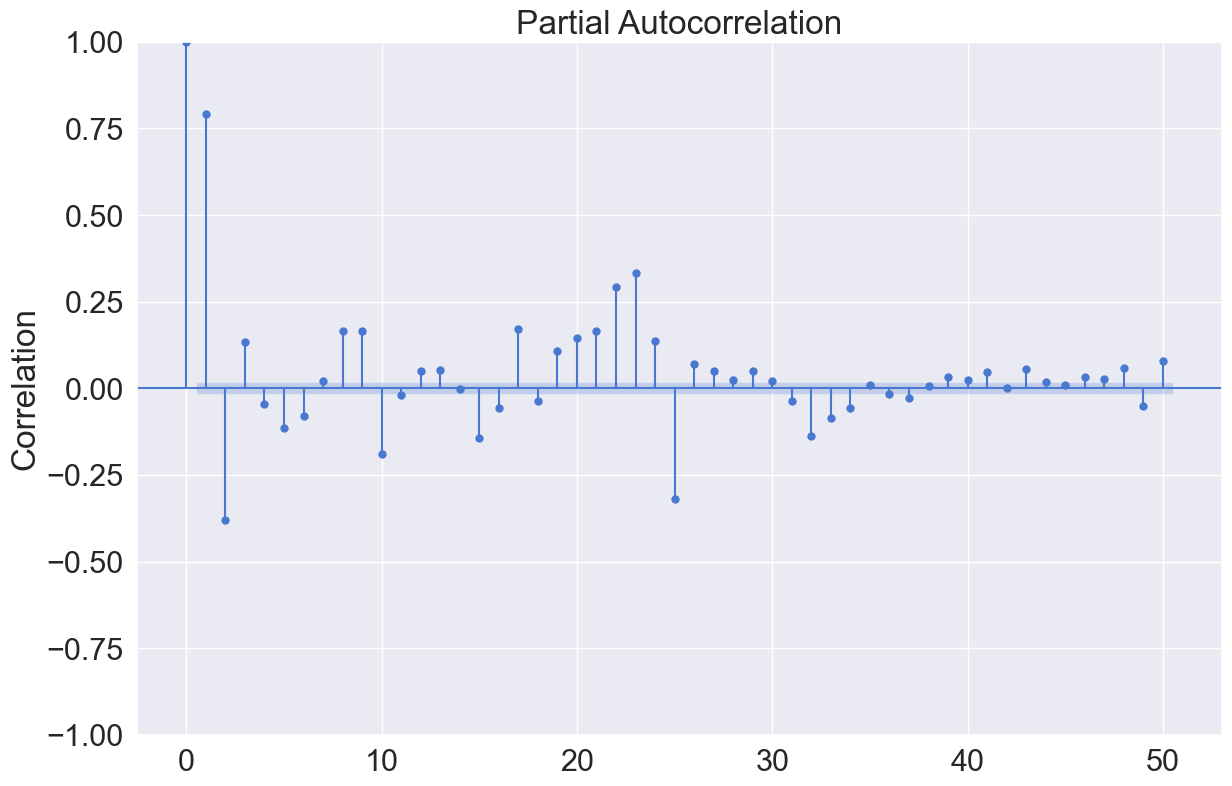

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\4002010902.py:200: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  Stationarity = pd.Series(sm.tsa.stattools.kpss(Resid.iloc[:,[0]])[0:3],
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\4002010902.py:202: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  for key, value in sm.tsa.stattools.kpss(Resid.Error)[3].items():


,Normality,Heteroscedasticity,Autocorr(lag10),Autocorr(lag50),Stationarity_ADF,Stationarity_KPSS
Test Statistics,0.94,1.76,"13,138.03","48,485.56",-9.25,19.30
p-value,0.00,0.00,0.00,0.00,0.00,0.01
Alternative,NaN,two-sided,NaN,NaN,NaN,NaN
Used Lag,NaN,NaN,NaN,NaN,40.00,18.00
Critical Value(1%),NaN,NaN,NaN,NaN,-3.43,0.74
Critical Value(5%),NaN,NaN,NaN,NaN,-2.86,0.46
Critical Value(10%),NaN,NaN,NaN,NaN,-2.57,0.35


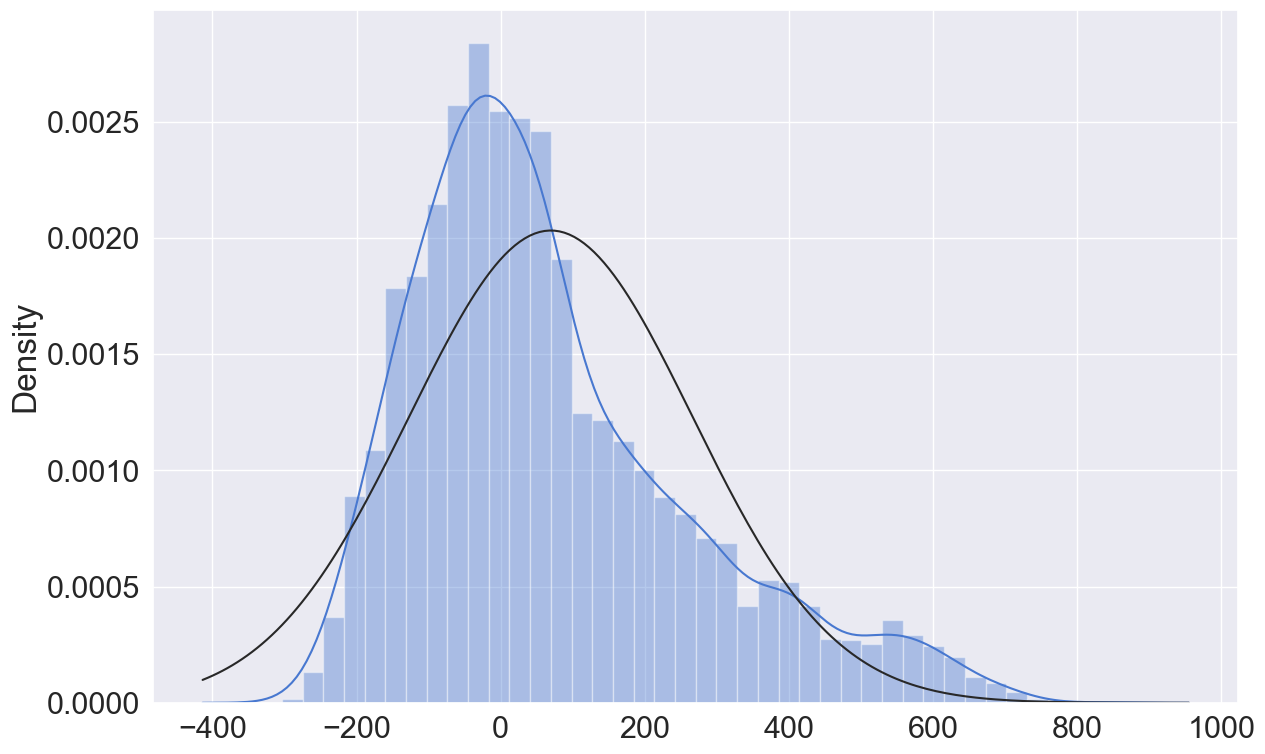

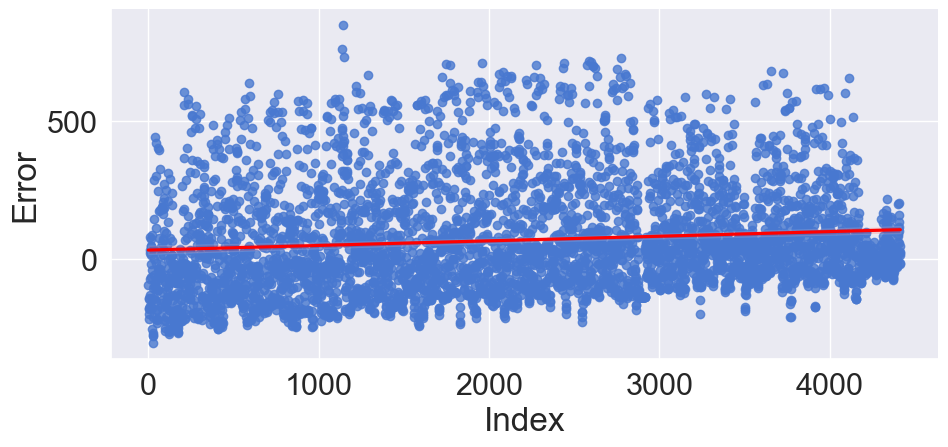

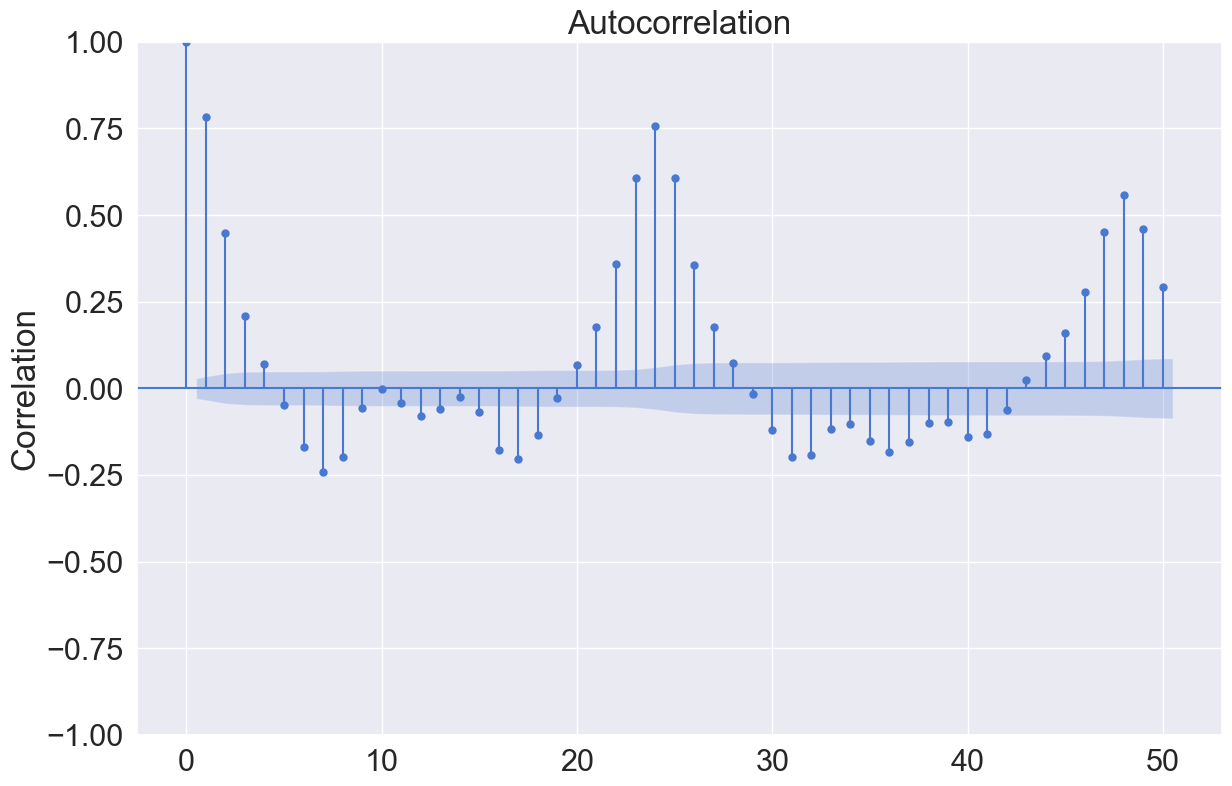

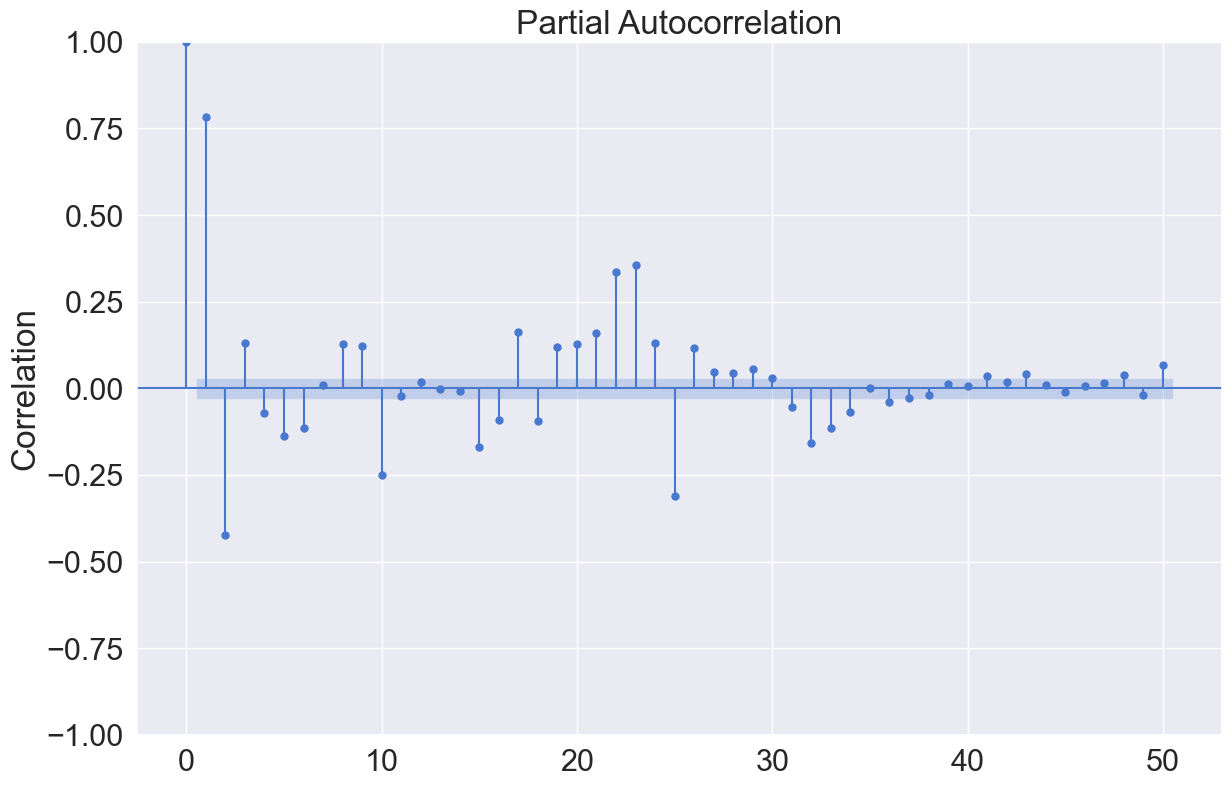

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\4002010902.py:200: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  Stationarity = pd.Series(sm.tsa.stattools.kpss(Resid.iloc[:,[0]])[0:3],
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\4002010902.py:202: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  for key, value in sm.tsa.stattools.kpss(Resid.Error)[3].items():


,Normality,Heteroscedasticity,Autocorr(lag10),Autocorr(lag50),Stationarity_ADF,Stationarity_KPSS
Test Statistics,0.93,0.73,"4,400.21","17,427.07",-6.11,2.62
p-value,0.00,0.00,0.00,0.00,0.00,0.01
Alternative,NaN,two-sided,NaN,NaN,NaN,NaN
Used Lag,NaN,NaN,NaN,NaN,31.00,15.00
Critical Value(1%),NaN,NaN,NaN,NaN,-3.43,0.74
Critical Value(5%),NaN,NaN,NaN,NaN,-2.86,0.46
Critical Value(10%),NaN,NaN,NaN,NaN,-2.57,0.35


In [148]:
# 데이터 로딩
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df_all = pd.read_csv(location)

# 데이터 전처리
df_fe = non_feature_engineering(df_all)

# 데이터 분리
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
X_colname = [x for x in df_fe.columns if x not in Y_colname+X_remove]
X_train, X_test, Y_train, Y_test = datasplit_ts(df_fe, Y_colname, X_colname, '2012-07-01')

# Linear Regression
model_lr = sm.OLS(Y_train, X_train).fit()
display(model_lr.summary())

Y_trpred = pd.DataFrame(model_lr.predict(X_train), columns=['Pred'])
Y_tepred = pd.DataFrame(model_lr.predict(X_test), columns=['Pred'])
plot_prediction(pd.concat([Y_train, Y_trpred], axis=1).reset_index().iloc[:,1:])
plot_prediction(pd.concat([Y_test, Y_tepred], axis=1).reset_index().iloc[:,1:])

# 분석 검증
Score = evaluation_reg_trte(Y_train, Y_trpred, Y_test, Y_tepred)
display(Score)

# 에러 분석
Resid_tr = Y_train - Y_trpred.values
Resid_tr.columns = ['Error']
Resid_te = Y_test - Y_tepred.values
Resid_te.columns = ['Error']

Error_tr = error_analysis_timeseries(X_train, Y_trpred, Resid_tr, graph_on=True)
display(Error_tr)
Error_te = error_analysis_timeseries(X_test, Y_tepred, Resid_te, graph_on=True)
display(Error_te)

## 전처리 모두 반영 분석결과

Train_size: (13128, 28) Test_size: (4416, 28)
X_train: (13128, 24) Y_train: (13128, 1)
X_test: (4416, 24) Y_test: (4416, 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.362e+08
Date:                Sun, 21 Sep 2025   Prob (F-statistic):               0.00
Time:                        23:54:56   Log-Likelihood:                 1906.2
No. Observations:               13128   AIC:                            -3764.
Df Residuals:                   13104   BIC:                            -3585.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
season            -0.0005      0.004     -0.129      0.897      -0.009       0.008
holiday            0.0083      0.014      0.612      0.540      -0.018       0.035
workingday         0.0079      0.007      1.184      0.236      -0.005       0.021
weather            0.0042      0.003      1.232      0.218      -0.003       0.011
temp               0.0022      0.002      1.075      0.282      -0.002       0.006
atemp             -0.0025      0.002     -1.347      0.178      -0.006       0.001
humidity          -0.0001      0.000     -0.845      0.398      -0.000       0.000
windspeed          0.0003      0.000      1.062      0.288      -0.000       0.001
count_trend     9.161e-05   8.57e-05      1.069      0.285   -7.64e-05       0.000
count_seasonal  1.984e-05   2.56e-05      0.775      0.438   -3.03e-05       7e-05
count_Day       4.177e-05   8.36e-05      0.500      0.617      -0.000       0.000
count_Week     -4.345e-05   9.61e-05     -0.452      0.651      -0.000       0.000
count_diff         1.0000    2.9e-05   3.45e+04      0.000       1.000       1.000
Year           -1.547e-05   7.97e-06     -1.939      0.052   -3.11e-05    1.66e-07
Quater_ver2        0.0004      0.002      0.180      0.857      -0.004       0.005
Month              0.0026      0.002      1.051      0.293      -0.002       0.007
Day                0.0004      0.000      1.728      0.084   -4.91e-05       0.001
Hour               0.0006      0.000      1.538      0.124      -0.000       0.001
DayofWeek          0.0003      0.002      0.224      0.823      -0.003       0.003
count_lag1         1.0000    2.7e-05    3.7e+04      0.000       1.000       1.000
count_lag2     -1.926e-05   2.59e-05     -0.744      0.457      -7e-05    3.15e-05
Quater_Dummy_2    -0.0010      0.009     -0.115      0.909      -0.019       0.017
Quater_Dummy_3    -0.0037      0.017     -0.220      0.826      -0.037       0.030
Quater_Dummy_4    -0.0132      0.026     -0.512      0.609      -0.064       0.037
==============================================================================
Omnibus:                    54426.083   Durbin-Watson:                   1.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      93552024983.816
Skew:                        -114.255   Prob(JB):                         0.00
Kurtosis:                   13078.751   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

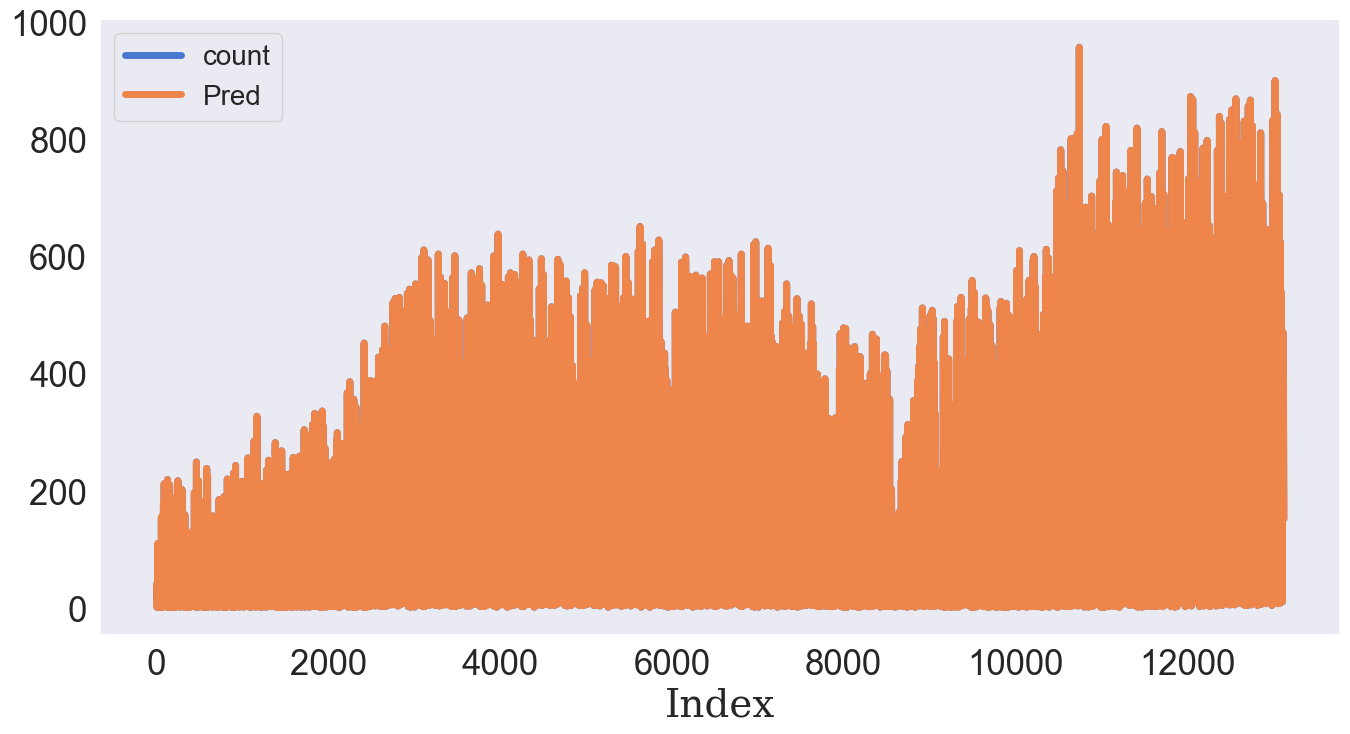

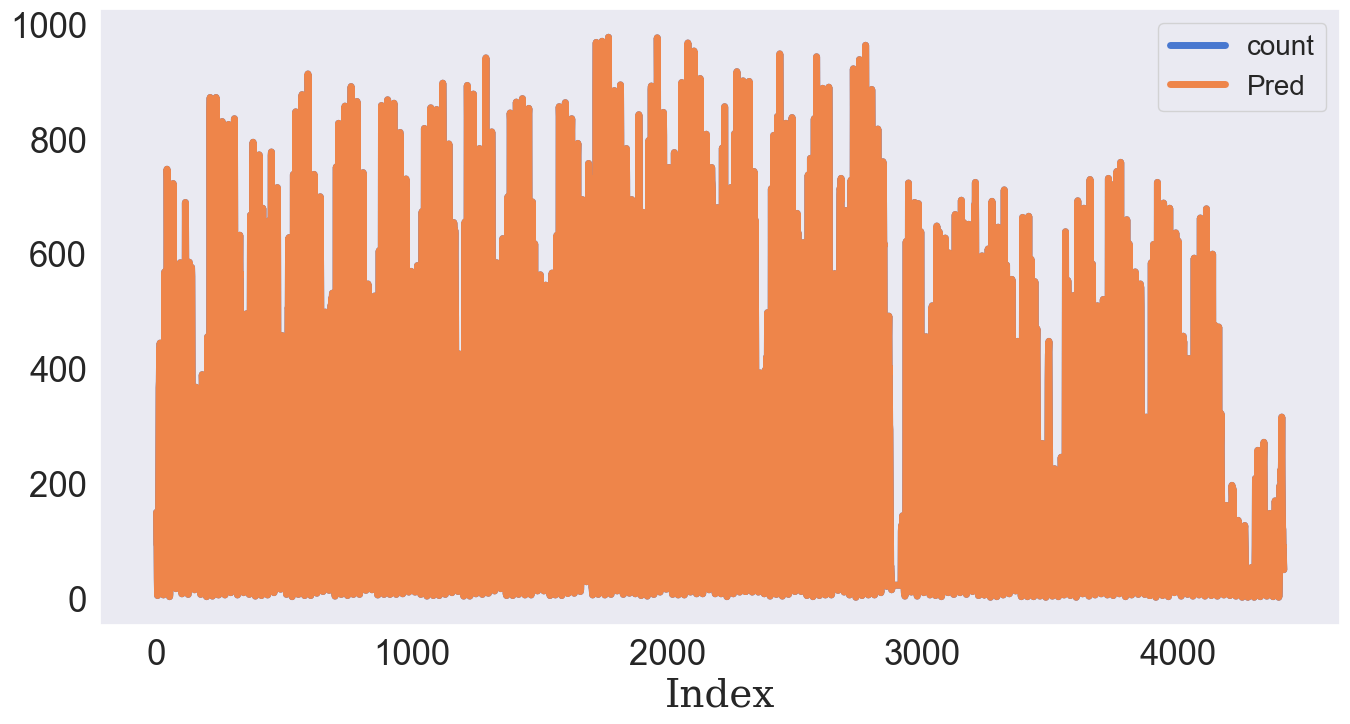

,MAE,MSE,MAPE
Train,0.01,0.04,0.00
Test,0.01,0.00,0.00


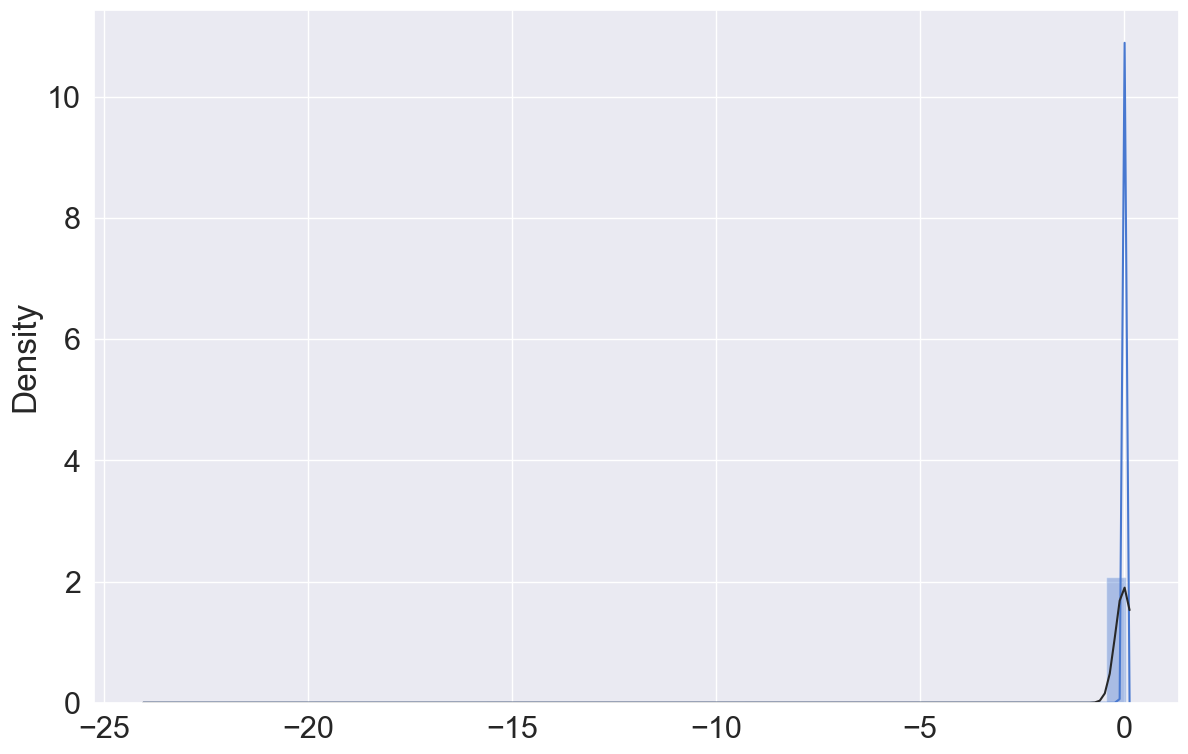

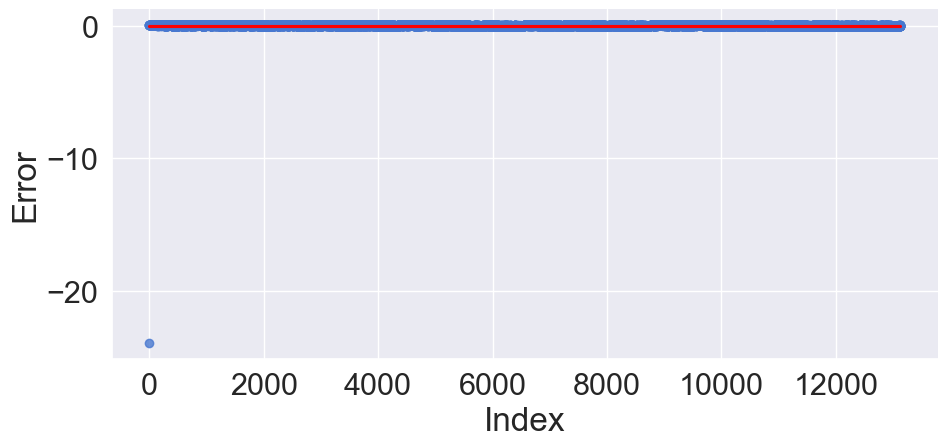

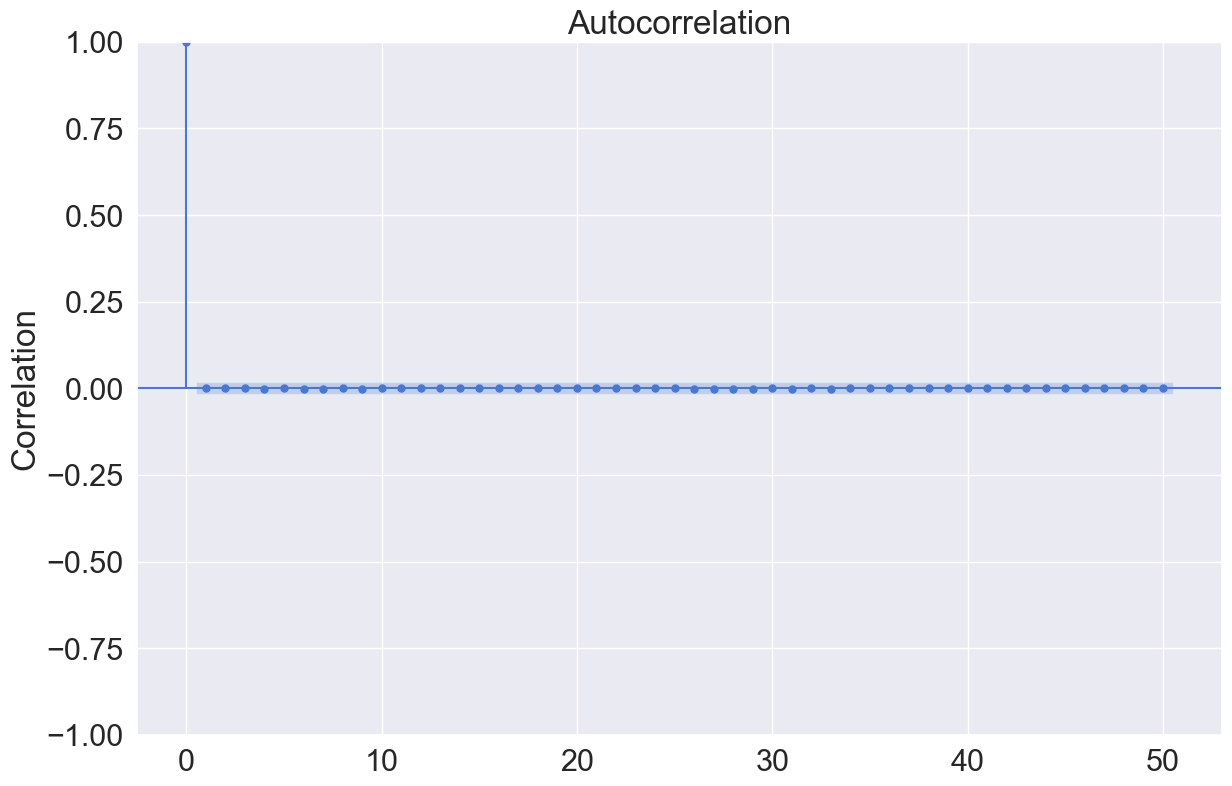

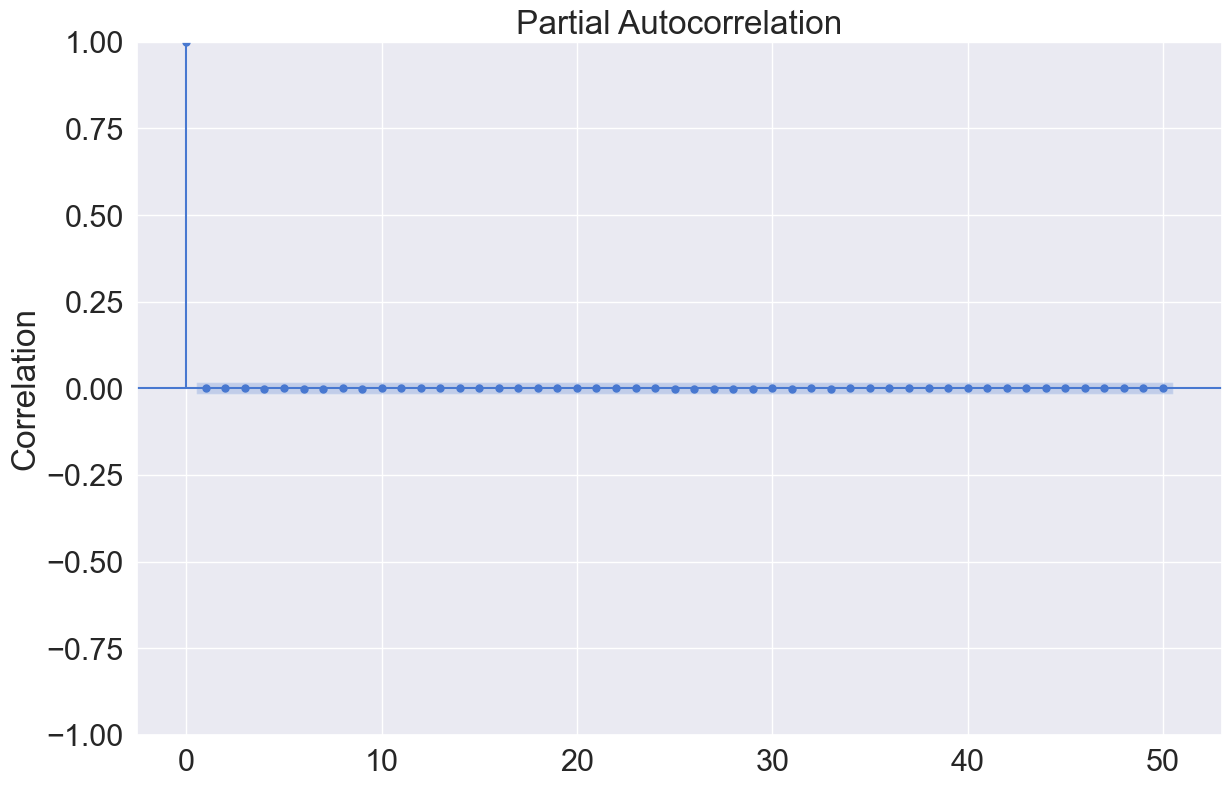

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\4002010902.py:200: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  Stationarity = pd.Series(sm.tsa.stattools.kpss(Resid.iloc[:,[0]])[0:3],
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37036\4002010902.py:202: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  for key, value in sm.tsa.stattools.kpss(Resid.Error)[3].items():


,Normality,Heteroscedasticity,Autocorr(lag10),Autocorr(lag50),Stationarity_ADF,Stationarity_KPSS
Test Statistics,0.01,0.00,0.03,0.10,-9.98,0.09
p-value,0.00,0.00,1.00,1.00,0.00,0.10
Alternative,NaN,two-sided,NaN,NaN,NaN,NaN
Used Lag,NaN,NaN,NaN,NaN,41.00,2.00
Critical Value(1%),NaN,NaN,NaN,NaN,-3.43,0.74
Critical Value(5%),NaN,NaN,NaN,NaN,-2.86,0.46
Critical Value(10%),NaN,NaN,NaN,NaN,-2.57,0.35


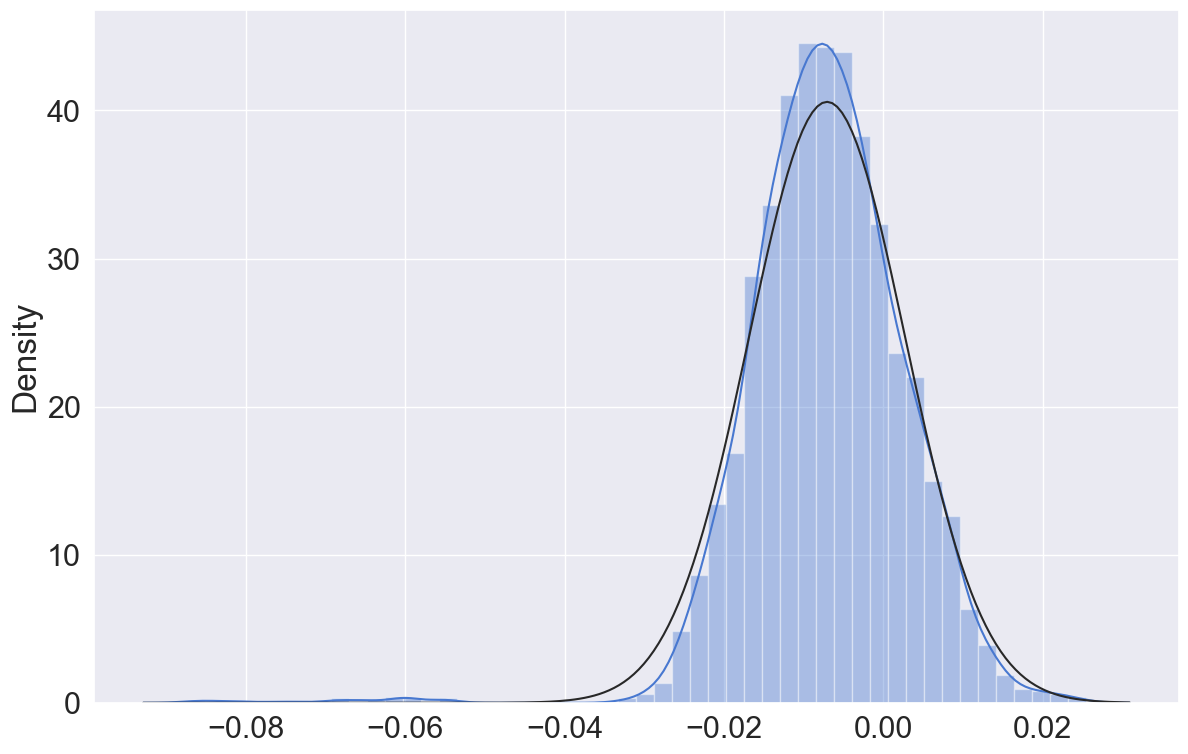

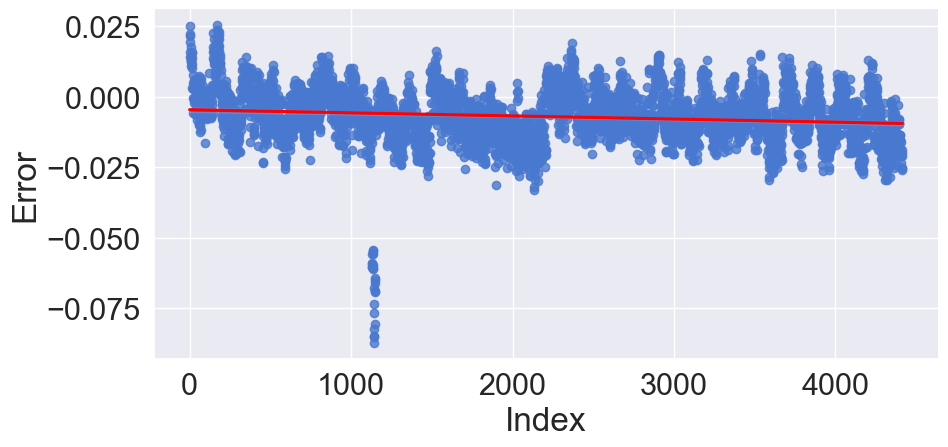

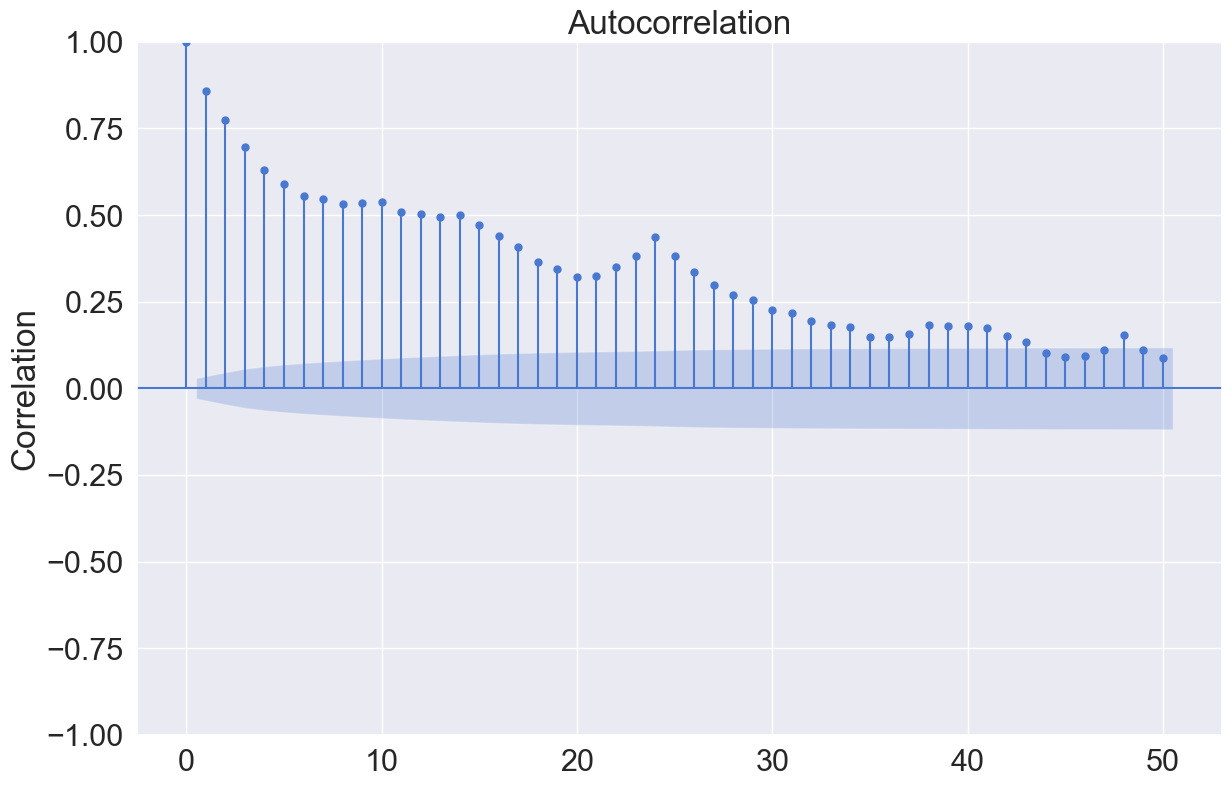

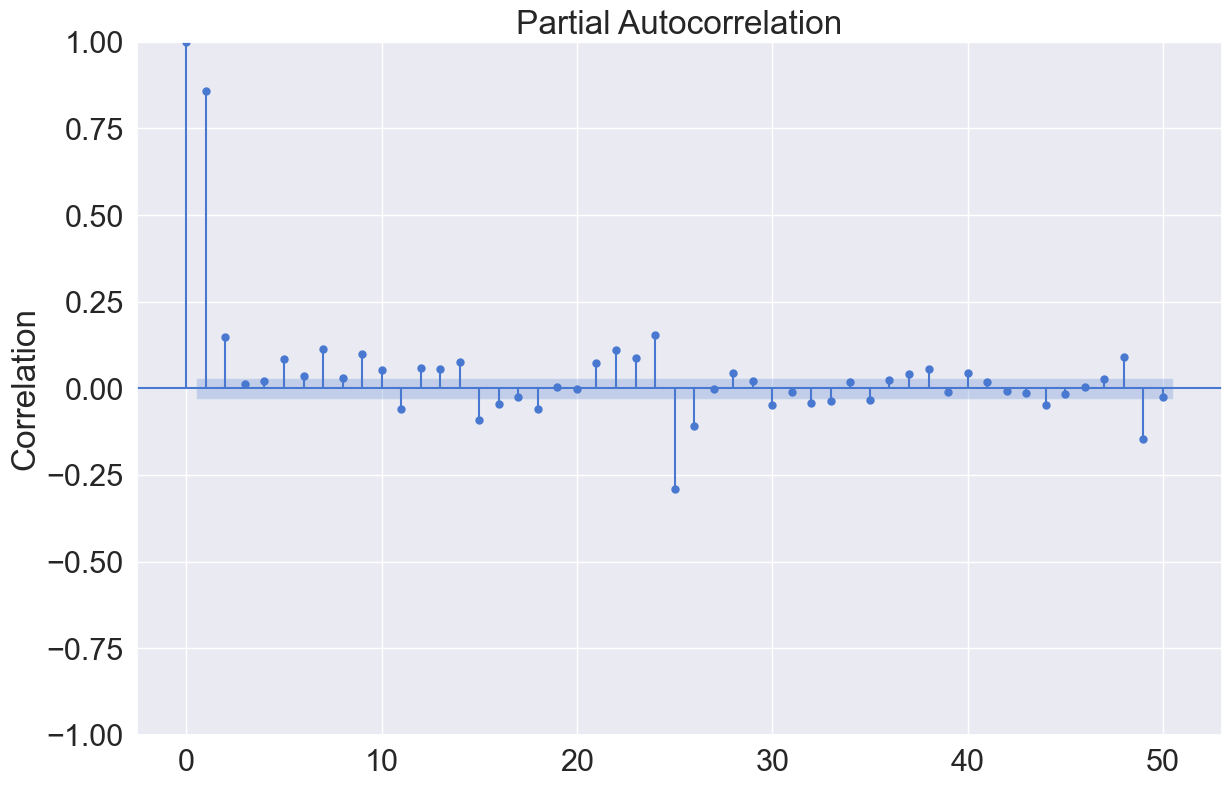

,Normality,Heteroscedasticity,Autocorr(lag10),Autocorr(lag50),Stationarity_ADF,Stationarity_KPSS
Test Statistics,0.93,0.63,"17,815.72","33,403.03",-8.08,0.51
p-value,0.00,0.00,0.00,0.00,0.00,0.04
Alternative,NaN,two-sided,NaN,NaN,NaN,NaN
Used Lag,NaN,NaN,NaN,NaN,31.00,38.00
Critical Value(1%),NaN,NaN,NaN,NaN,-3.43,0.74
Critical Value(5%),NaN,NaN,NaN,NaN,-2.86,0.46
Critical Value(10%),NaN,NaN,NaN,NaN,-2.57,0.35


In [149]:
# 데이터 로딩
location = os.path.join('.', 'Data', 'BikeSharingDemand', 'Bike_Sharing_Demand_Full.csv')
df_all = pd.read_csv(location)

# 데이터 전처리
df_fe = feature_engineering(df_all)

# 데이터 분리
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
X_colname = [x for x in df_fe.columns if x not in Y_colname+X_remove]
X_train, X_test, Y_train, Y_test = datasplit_ts(df_fe, Y_colname, X_colname, '2012-07-01')

# Linear Regression
model_lr = sm.OLS(Y_train, X_train).fit()
display(model_lr.summary())

Y_trpred = pd.DataFrame(model_lr.predict(X_train), columns=['Pred'])
Y_tepred = pd.DataFrame(model_lr.predict(X_test), columns=['Pred'])
plot_prediction(pd.concat([Y_train, Y_trpred], axis=1).reset_index().iloc[:,1:])
plot_prediction(pd.concat([Y_test, Y_tepred], axis=1).reset_index().iloc[:,1:])

# 분석 검증
Score = evaluation_reg_trte(Y_train, Y_trpred, Y_test, Y_tepred)
display(Score)

# 에러 분석
Resid_tr = Y_train - Y_trpred.values
Resid_tr.columns = ['Error']
Resid_te = Y_test - Y_tepred.values
Resid_te.columns = ['Error']

Error_tr = error_analysis_timeseries(X_train, Y_trpred, Resid_tr, graph_on=True)
display(Error_tr)
Error_te = error_analysis_timeseries(X_test, Y_tepred, Resid_te, graph_on=True)
display(Error_te)